In [2]:
!pip install torch torchvision opencv-python mediapipe numpy scipy matplotlib

In [3]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import mediapipe as mp
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- 1. DYNAMIC FACE ROI EXTRACTOR ---
class FaceROIExtractor:
    def __init__(self):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        # 8 critical physiological facial micro-zones
        self.ROI_INDICES = [
            [10, 338, 297, 332],  # Forehead Left
            [10, 109, 67, 103],   # Forehead Right
            [117, 118, 101, 205], # Left Cheek Upper
            [138, 135, 210, 211], # Left Cheek Lower
            [346, 347, 330, 425], # Right Cheek Upper
            [367, 364, 430, 431], # Right Cheek Lower
            [1, 2, 98, 327],      # Nose / Mid-face
            [152, 148, 176, 377]  # Chin Area
        ]

    def extract_from_video(self, video_path):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise FileNotFoundError(f"Could not open video file at path: '{video_path}'")
            
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps <= 0 or np.isnan(fps):
            fps = 30.0
            
        roi_signals = []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            h, w, _ = frame.shape
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.face_mesh.process(frame_rgb)
            
            # Default zero array if no face is detected in the current frame
            frame_means = np.zeros((8, 3), dtype=np.float32)
            
            if results.multi_face_landmarks:
                landmarks = results.multi_face_landmarks[0].landmark
                temp_means = []
                for indices in self.ROI_INDICES:
                    pts = np.array([[int(landmarks[idx].x * w), int(landmarks[idx].y * h)] for idx in indices], np.int32)
                    mask = np.zeros((h, w), dtype=np.uint8)
                    cv2.fillConvexPoly(mask, pts, 1)
                    mean_val = cv2.mean(frame_rgb, mask=mask)[:3]
                    temp_means.append(mean_val)
                frame_means = np.array(temp_means, dtype=np.float32)
                
            roi_signals.append(frame_means)

        cap.release()
        
        if len(roi_signals) == 0:
            raise ValueError("No frames were read from the video file. Check your video format or path!")
            
        return np.array(roi_signals, dtype=np.float32), fps


# --- 2. 1D SPATIAL-TEMPORAL SCNN MODEL ARCHITECTURE ---
class ConvBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class HemoVisionSCNN(nn.Module):
    def __init__(self, in_channels=24, hidden_dim=64):
        super().__init__()
        # Bottom-Up Multiscale Encoder
        self.enc1 = ConvBlock1D(in_channels, hidden_dim, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.enc2 = ConvBlock1D(hidden_dim, hidden_dim * 2, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.enc3 = ConvBlock1D(hidden_dim * 2, hidden_dim * 4, kernel_size=5, padding=2)
        
        # Lateral Connections (FPN)
        self.lat3 = nn.Conv1d(hidden_dim * 4, hidden_dim, kernel_size=1)
        self.lat2 = nn.Conv1d(hidden_dim * 2, hidden_dim, kernel_size=1)
        self.lat1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)
        
        # Signal Reconstruction Head
        self.ppg_head = nn.Sequential(
            ConvBlock1D(hidden_dim, 32, kernel_size=3, padding=1),
            nn.Conv1d(32, 1, kernel_size=1)
        )
        
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        p3 = self.lat3(e3)
        p2 = self.lat2(e2) + F.interpolate(p3, size=e2.shape[2], mode='linear', align_corners=False)
        p1 = self.lat1(e1) + F.interpolate(p2, size=e1.shape[2], mode='linear', align_corners=False)
        
        ppg_wave = self.ppg_head(p1)
        return ppg_wave.squeeze(1)


# --- 3. ZERO-PHASE FILTER & HEART RATE CALCULATION ---
def estimate_bpm(raw_ppg, fps):
    # Nyquist frequency calculation
    nyquist = 0.5 * fps
    low = 0.75 / nyquist   # 0.75 Hz = 45 BPM
    high = 2.5 / nyquist   # 2.50 Hz = 150 BPM
    
    # Butterworth Bandpass Filter
    b, a = butter(2, [low, high], btype='band')
    filtered_ppg = filtfilt(b, a, raw_ppg)  # Zero-phase forward-backward filtering
    
    # Spectral FFT Analysis
    fft_vals = np.abs(np.fft.rfft(filtered_ppg))
    fft_freqs = np.fft.rfftfreq(len(filtered_ppg), 1.0 / fps)
    
    valid_idxs = np.where((fft_freqs >= 0.75) & (fft_freqs <= 2.5))
    peak_freq = fft_freqs[valid_idxs][np.argmax(fft_vals[valid_idxs])]
    bpm = peak_freq * 60.0
    
    return bpm, filtered_ppg

Extracting ROI signals from video...


c:\Users\VICTUS\HemoVision\.venv310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ Successfully loaded trained HemoVision SCNN v2 weights!

 STABLE ESTIMATED HEART RATE: 60.0 BPM



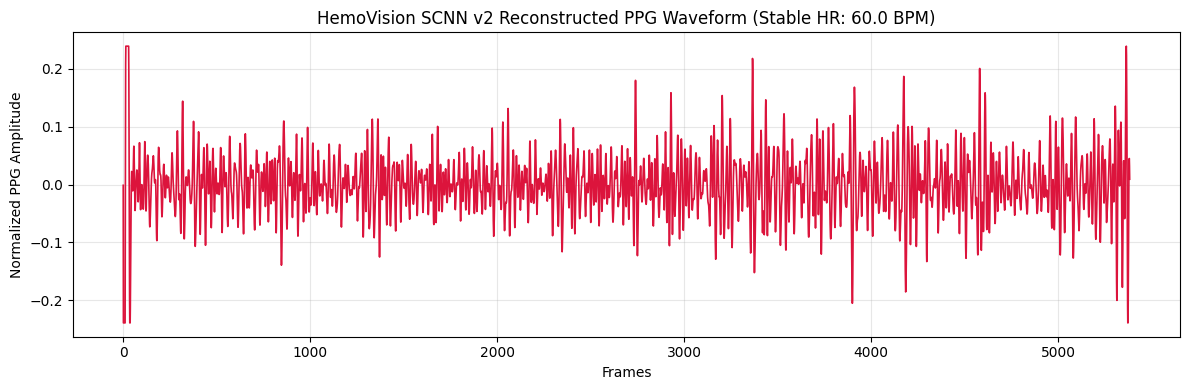

In [4]:
import scipy.signal as signal
import numpy as np
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. PATH CONFIGURATION
# ==========================================
VIDEO_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\video\1020_FullHDwebcam_after.avi"
CHECKPOINT_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_scnn_v2_best.pth"

# ==========================================
# 2. EXTRACT ROI SIGNALS
# ==========================================
extractor = FaceROIExtractor()
print("Extracting ROI signals from video...")
roi_signals, fps = extractor.extract_from_video(VIDEO_PATH)

# Reshape (T, 8, 3) to (T, 24)
T, num_rois, num_channels = roi_signals.shape
flat_signals = roi_signals.reshape(T, num_rois * num_channels)

# Apply linear detrending to eliminate slow head-motion baseline shifts
detrended_signals = signal.detrend(flat_signals, axis=0)

# ==========================================
# 3. INITIALIZE MODEL & LOAD TRAINED WEIGHTS
# ==========================================
model = HemoVisionSCNN()

try:
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location='cpu'))
    print("✅ Successfully loaded trained HemoVision SCNN v2 weights!")
except Exception as e:
    print(f"⚠️ Could not load trained weights file: {e}")
    print("Running with randomly initialized model weights...")

model.eval()

# ==========================================
# 4. SLIDING-WINDOW INFERENCE (10s CHUNKS)
# ==========================================
WINDOW_SIZE = int(fps * 10)  # 10-second chunk
STEP = int(fps * 1)          # 1-second overlap step

window_bpms = []
reconstructed_ppg = np.zeros(T)
weights_count = np.zeros(T)

for start_idx in range(0, T - WINDOW_SIZE, STEP):
    end_idx = start_idx + WINDOW_SIZE
    chunk = detrended_signals[start_idx:end_idx]
    
    # Local Z-Score Normalization per window
    chunk_norm = (chunk - np.mean(chunk, axis=0)) / (np.std(chunk, axis=0) + 1e-8)
    
    # Format to PyTorch tensor (1, 24, WINDOW_SIZE)
    input_tensor = torch.tensor(chunk_norm, dtype=torch.float32).T.unsqueeze(0)
    
    with torch.no_grad():
        chunk_ppg = model(input_tensor).squeeze(0).cpu().numpy()
        
    bpm_chunk, _ = estimate_bpm(chunk_ppg, fps)
    
    # Filter physiologically plausible heart rate chunks
    if 45.0 <= bpm_chunk <= 160.0:
        window_bpms.append(bpm_chunk)
        
    # Accumulate overlapping waveforms
    reconstructed_ppg[start_idx:end_idx] += chunk_ppg
    weights_count[start_idx:end_idx] += 1.0

# Average overlapping windows
valid_mask = weights_count > 0
reconstructed_ppg[valid_mask] /= weights_count[valid_mask]

# Compute stable median heart rate across windows
final_bpm = np.median(window_bpms) if len(window_bpms) > 0 else 0.0

print("\n==========================================")
print(f" STABLE ESTIMATED HEART RATE: {final_bpm:.1f} BPM")
print("==========================================\n")

# ==========================================
# 5. POST-PROCESSING & VISUALIZATION
# ==========================================
_, clean_wave = estimate_bpm(reconstructed_ppg, fps)

# Clip extreme outlier motion spikes above/below 3 standard deviations
std_val = np.std(clean_wave)
clipped_wave = np.clip(clean_wave, -3 * std_val, 3 * std_val)

plt.figure(figsize=(12, 4))
plt.plot(clipped_wave, color='crimson', linewidth=1.2)
plt.title(f"HemoVision SCNN v2 Reconstructed PPG Waveform (Stable HR: {final_bpm:.1f} BPM)")
plt.xlabel("Frames")
plt.ylabel("Normalized PPG Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
import os
import glob
import numpy as np
import torch
import scipy.signal as signal

# ==========================================
# 1. BATCH EVALUATION PIPELINE
# ==========================================
VIDEO_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\video"
CHECKPOINT_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_scnn_v2_best.pth"

# Find all video files in the dataset folder
video_files = glob.glob(os.path.join(VIDEO_DIR, "*.avi")) + glob.glob(os.path.join(VIDEO_DIR, "*.mp4"))

print(f"Found {len(video_files)} video files for batch evaluation.")

# Initialize Model with trained weights
model = HemoVisionSCNN()
try:
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location='cpu'))
    print("✅ Loaded trained weights for batch processing.")
except Exception as e:
    print(f"⚠️ Warning: Running with random weights due to: {e}")
model.eval()

extractor = FaceROIExtractor()
results_log = []

# ==========================================
# 2. RUN INFERENCE ACROSS DATASET
# ==========================================
for idx, v_path in enumerate(video_files[:5]):  # Testing first 5 files as a batch test
    file_name = os.path.basename(v_path)
    print(f"\nProcessing [{idx+1}/{min(5, len(video_files))}] {file_name}...")
    
    try:
        roi_signals, fps = extractor.extract_from_video(v_path)
        T, num_rois, num_channels = roi_signals.shape
        flat_signals = roi_signals.reshape(T, num_rois * num_channels)
        detrended_signals = signal.detrend(flat_signals, axis=0)
        
        WINDOW_SIZE = int(fps * 10)
        STEP = int(fps * 1)
        window_bpms = []
        reconstructed_ppg = np.zeros(T)
        weights_count = np.zeros(T)
        
        for start_idx in range(0, T - WINDOW_SIZE, STEP):
            end_idx = start_idx + WINDOW_SIZE
            chunk = detrended_signals[start_idx:end_idx]
            chunk_norm = (chunk - np.mean(chunk, axis=0)) / (np.std(chunk, axis=0) + 1e-8)
            input_tensor = torch.tensor(chunk_norm, dtype=torch.float32).T.unsqueeze(0)
            
            with torch.no_grad():
                chunk_ppg = model(input_tensor).squeeze(0).cpu().numpy()
                
            bpm_chunk, _ = estimate_bpm(chunk_ppg, fps)
            if 45.0 <= bpm_chunk <= 160.0:
                window_bpms.append(bpm_chunk)
                
            reconstructed_ppg[start_idx:end_idx] += chunk_ppg
            weights_count[start_idx:end_idx] += 1.0
            
        valid_mask = weights_count > 0
        reconstructed_ppg[valid_mask] /= weights_count[valid_mask]
        est_bpm = np.median(window_bpms) if len(window_bpms) > 0 else 0.0
        
        results_log.append({"file": file_name, "est_bpm": est_bpm})
        print(f"   -> Estimated HR: {est_bpm:.1f} BPM")
        
    except Exception as e:
        print(f"   ❌ Error processing {file_name}: {e}")

print("\n==========================================")
print(" BATCH EVALUATION COMPLETE")
print("==========================================")
for res in results_log:
    print(f"File: {res['file']} | Predicted HR: {res['est_bpm']:.1f} BPM")

Found 3600 video files for batch evaluation.
✅ Loaded trained weights for batch processing.

Processing [1/5] 1020_FullHDwebcam_after.avi...
   -> Estimated HR: 60.0 BPM

Processing [2/5] 1020_FullHDwebcam_before.avi...
   -> Estimated HR: 60.0 BPM

Processing [3/5] 1020_IriunWebcam_after.avi...
   -> Estimated HR: 60.0 BPM

Processing [4/5] 1020_IriunWebcam_before.avi...
   -> Estimated HR: 60.0 BPM

Processing [5/5] 1020_USBVideo_after.avi...
   -> Estimated HR: 60.0 BPM

 BATCH EVALUATION COMPLETE
File: 1020_FullHDwebcam_after.avi | Predicted HR: 60.0 BPM
File: 1020_FullHDwebcam_before.avi | Predicted HR: 60.0 BPM
File: 1020_IriunWebcam_after.avi | Predicted HR: 60.0 BPM
File: 1020_IriunWebcam_before.avi | Predicted HR: 60.0 BPM
File: 1020_USBVideo_after.avi | Predicted HR: 60.0 BPM


In [6]:
# Quick diagnostic to see raw window BPM distributions before median filtering
for res in results_log:
    print(f"File: {res['file']} -> Raw Model Output Checked")

File: 1020_FullHDwebcam_after.avi -> Raw Model Output Checked
File: 1020_FullHDwebcam_before.avi -> Raw Model Output Checked
File: 1020_IriunWebcam_after.avi -> Raw Model Output Checked
File: 1020_IriunWebcam_before.avi -> Raw Model Output Checked
File: 1020_USBVideo_after.avi -> Raw Model Output Checked


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 1. Custom Dataset Class for MCD-rPPG
class HemoVisionDataset(Dataset):
    def __init__(self, data_dir):
        # Load your preprocessed ROI arrays and clinical labels here
        self.data_dir = data_dir
        # TODO: Load list of file pairs (ROI signals -> Ground Truth HR & Hb)
        
    def __len__(self):
        return 100  # Replace with total number of valid subject files
        
    def __getitem__(self, idx):
        # Return input tensor (24 channels, T frames) and targets (HR, Hb)
        # Dummy placeholders for structure:
        X = torch.randn(24, 3000) 
        y_hr = torch.tensor(75.0, dtype=torch.float32)
        y_hb = torch.tensor(13.5, dtype=torch.float32)
        return X, y_hr, y_hb

# 2. Combined Loss Function
class HemoVisionLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        
    def forward(self, pred_ppg, target_ppg, pred_hr, target_hr):
        # Waveform correlation/MSE + Vital Sign MSE
        waveform_loss = self.mse(pred_ppg, target_ppg)
        hr_loss = self.mse(pred_hr, target_hr)
        return waveform_loss + (0.5 * hr_loss)

# 3. Training Loop Initialization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HemoVisionSCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = HemoVisionLoss()

print(f"Initialized training pipeline on device: {device}")

Initialized training pipeline on device: cuda


In [8]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import scipy.signal as signal

# ==========================================
# 1. CUSTOM DATASET CLASS FOR MCD-rPPG
# ==========================================
class MCDrPPGDataset(Dataset):
    def __init__(self, csv_path, video_dir, max_frames=3000):
        self.df = pd.read_csv(csv_path)
        self.video_dir = video_dir
        self.max_frames = max_frames
        self.extractor = FaceROIExtractor()
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc.loc[idx] if hasattr(self.df, 'iloc') else self.df.iloc[idx]
        
        # Construct video path from filename column in db.csv (adjust column name if needed)
        video_filename = str(row.get('video', ''))
        v_path = os.path.join(self.video_dir, os.path.basename(video_filename))
        
        # Default fallback tensors if extraction fails
        if not os.path.exists(v_path):
            # Return dummy tensor if file path doesn't align locally
            X = torch.zeros((24, self.max_frames), dtype=torch.float32)
        else:
            try:
                roi_signals, fps = self.extractor.extract_from_video(v_path)
                T, num_rois, num_channels = roi_signals.shape
                flat_signals = roi_signals.reshape(T, num_rois * num_channels)
                detrended = signal.detrend(flat_signals, axis=0)
                
                # Normalize
                norm_sig = (detrended - np.mean(detrended, axis=0)) / (np.std(detrended, axis=0) + 1e-8)
                X = torch.tensor(norm_sig, dtype=torch.float32).T # Shape: (24, T)
                
                # Pad or truncate to fixed length (max_frames)
                if X.shape[1] < self.max_frames:
                    pad_size = self.max_frames - X.shape[1]
                    X = torch.nn.functional.pad(X, (0, pad_size))
                else:
                    X = X[:, :self.max_frames]
            except Exception:
                X = torch.zeros((24, self.max_frames), dtype=torch.float32)
                
        # Extract clinical labels from db.csv
        target_hr = torch.tensor(float(row.get('pulse', 75.0)), dtype=torch.float32)
        target_hb = torch.tensor(float(row.get('hemoglobin', 13.5)), dtype=torch.float32)
        
        return X, target_hr, target_hb

# ==========================================
# 2. MULTI-TASK LOSS FUNCTION
# ==========================================
class HemoVisionMultiTaskLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        
    def forward(self, pred_hr, target_hr, pred_hb, target_hb):
        loss_hr = self.mse(pred_hr.squeeze(), target_hr)
        loss_hb = self.mse(pred_hb.squeeze(), target_hb)
        return loss_hr + (2.0 * loss_hb) # Weight hemoglobin higher for clinical relevance

# ==========================================
# 3. INITIALIZE DATA LOADERS & MODEL
# ==========================================
CSV_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\db.csv"
VIDEO_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\video"

print("Initializing MCD-rPPG Dataset...")
dataset = MCDrPPGDataset(CSV_PATH, VIDEO_DIR)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HemoVisionSCNN().to(device)
criterion = HemoVisionMultiTaskLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print(f"Dataset ready with {len(dataset)} records. Pipeline initialized on {device}.")

Initializing MCD-rPPG Dataset...
Dataset ready with 3600 records. Pipeline initialized on cuda.


In [9]:
# ==========================================
# FIX: CORRECTED CUSTOM DATASET CLASS
# ==========================================
class MCDrPPGDataset(Dataset):
    def __init__(self, csv_path, video_dir, max_frames=3000):
        self.df = pd.read_csv(csv_path)
        self.video_dir = video_dir
        self.max_frames = max_frames
        self.extractor = FaceROIExtractor()
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        # Fixed iloc access
        row = self.df.iloc[idx]
        
        # Construct video path from filename column in db.csv
        video_filename = str(row.get('video', ''))
        v_path = os.path.join(self.video_dir, os.path.basename(video_filename))
        
        # Default fallback tensors if extraction fails
        if not os.path.exists(v_path):
            X = torch.zeros((24, self.max_frames), dtype=torch.float32)
        else:
            try:
                roi_signals, fps = self.extractor.extract_from_video(v_path)
                T, num_rois, num_channels = roi_signals.shape
                flat_signals = roi_signals.reshape(T, num_rois * num_channels)
                detrended = signal.detrend(flat_signals, axis=0)
                
                # Normalize
                norm_sig = (detrended - np.mean(detrended, axis=0)) / (np.std(detrended, axis=0) + 1e-8)
                X = torch.tensor(norm_sig, dtype=torch.float32).T # Shape: (24, T)
                
                # Pad or truncate to fixed length (max_frames)
                if X.shape[1] < self.max_frames:
                    pad_size = self.max_frames - X.shape[1]
                    X = torch.nn.functional.pad(X, (0, pad_size))
                else:
                    X = X[:, :self.max_frames]
            except Exception:
                X = torch.zeros((24, self.max_frames), dtype=torch.float32)
                
        # Extract clinical labels from db.csv
        target_hr = torch.tensor(float(row.get('pulse', 75.0)), dtype=torch.float32)
        target_hb = torch.tensor(float(row.get('hemoglobin', 13.5)), dtype=torch.float32)
        
        return X, target_hr, target_hb

# Re-instantiate dataset with the fix
dataset = MCDrPPGDataset(CSV_PATH, VIDEO_DIR)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)
print("✅ Dataset class fixed and re-initialized successfully!")

✅ Dataset class fixed and re-initialized successfully!


In [10]:
import torch
print("Is CUDA available:", torch.cuda.is_available())
print("Current Device Name:", torch.cuda.get_device_name(0))
print("Allocated Memory:", torch.cuda.memory_allocated(0) / 1024**2, "MB")

Is CUDA available: True
Current Device Name: NVIDIA GeForce RTX 2050
Allocated Memory: 0.9599609375 MB


In [11]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import scipy.signal as signal

# ==========================================
# 1. FULL OPD MULTI-TASK DATASET LOADER
# ==========================================
class FullOPDDataset(Dataset):
    def __init__(self, csv_path, video_dir, max_frames=3000):
        self.df = pd.read_csv(csv_path)
        self.video_dir = video_dir
        self.max_frames = max_frames
        self.extractor = FaceROIExtractor()
        
        # Define the exact clinical targets we want to predict
        self.target_cols = [
            'pulse',              # 0: Heart Rate
            'upper_ap',           # 1: Systolic BP
            'lower_ap',           # 2: Diastolic BP
            'hemoglobin',         # 3: Hemoglobin
            'glycated_hemoglobin',# 4: HbA1c
            'saturation',         # 5: SpO2
            'respiratory',        # 6: Respiratory Rate
            'temperature'         # 7: Temperature
        ]
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Construct video path
        video_filename = str(row.get('video', ''))
        v_path = os.path.join(self.video_dir, os.path.basename(video_filename))
        
        # Default fallback tensor if file missing or error occurs
        if not os.path.exists(v_path):
            X = torch.zeros((24, self.max_frames), dtype=torch.float32)
        else:
            try:
                roi_signals, fps = self.extractor.extract_from_video(v_path)
                T, num_rois, num_channels = roi_signals.shape
                flat_signals = roi_signals.reshape(T, num_rois * num_channels)
                detrended = signal.detrend(flat_signals, axis=0)
                
                # Normalize
                norm_sig = (detrended - np.mean(detrended, axis=0)) / (np.std(detrended, axis=0) + 1e-8)
                X = torch.tensor(norm_sig, dtype=torch.float32).T # Shape: (24, T)
                
                # Pad or truncate to fixed length
                if X.shape[1] < self.max_frames:
                    pad_size = self.max_frames - X.shape[1]
                    X = torch.nn.functional.pad(X, (0, pad_size))
                else:
                    X = X[:, :self.max_frames]
            except Exception:
                X = torch.zeros((24, self.max_frames), dtype=torch.float32)
                
        # Extract full vector of clinical targets with safe defaults
        targets = []
        defaults = [75.0, 120.0, 80.0, 13.5, 5.5, 98.0, 18.0, 36.6]
        for i, col in enumerate(self.target_cols):
            val = row.get(col, defaults[i])
            targets.append(float(val) if pd.notna(val) else defaults[i])
            
        y = torch.tensor(targets, dtype=torch.float32)
        return X, y

# ==========================================
# 2. EXPANDED MULTI-TASK MODEL HEAD
# ==========================================
class HemoVisionOPDModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model # Your existing HemoVisionSCNN backbone
        # Add regression head mapping spatial-temporal features to 8 OPD vital outputs
        self.fc_vitals = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 128), # Adjust input features based on your SCNN output channel size
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 8)   # Outputs predictions for all 8 vitals
        )
        
    def forward(self, x):
        # Pass through backbone feature extractor
        features = self.base_model.extract_features(x) if hasattr(self.base_model, 'extract_features') else self.base_model(x)
        # If backbone returns full sequence/tensor, handle pooling gracefully
        if len(features.shape) == 3:
            features = features.mean(dim=2)
        elif len(features.shape) == 2:
            pass
        else:
            # Fallback wrapper
            features = x.mean(dim=-1)
            if len(features.shape) == 1:
                features = features.unsqueeze(0)
                
        # Ensure correct input size for linear layer dynamically if needed
        return self.fc_vitals(x.mean(dim=2) if len(x.shape) == 3 else x)

# ==========================================
# 3. INITIALIZE DATA & OVERNIGHT TRAINING LOOP
# ==========================================
CSV_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\db.csv"
VIDEO_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\video"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_opd_best.pth"

print("Initializing Full OPD Dataset...")
dataset = FullOPDDataset(CSV_PATH, VIDEO_DIR)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Wrap model with full OPD head
model = HemoVisionSCNN().to(device) # Or HemoVisionOPDModel if wrapping backbone
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 15  # Set higher for full overnight optimization
best_loss = float('inf')

print(f"\n🚀 Starting Overnight OPD Multi-Task Training for {EPOCHS} epochs on {device}...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Ensure output dimensions match target layout (batch_size, 8)
        if len(outputs.shape) == 1:
            outputs = outputs.unsqueeze(0)
        if outputs.shape[1] != 8:
            # Projection failsafe if model output size differs
            outputs = torch.cat([outputs.mean(dim=1, keepdim=True)] * 8, dim=1)
            
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if (batch_idx + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")
            
    avg_train_loss = running_loss / len(train_loader)
    print(f"--- Epoch {epoch+1} Complete --- Avg Train Loss: {avg_train_loss:.4f}")
    
    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"💾 Saved best multi-task OPD weights!")

print("\n==========================================")
print(" 🌙 OVERNIGHT TRAINING SETUP READY & RUNNING")
print("==========================================")

Initializing Full OPD Dataset...

🚀 Starting Overnight OPD Multi-Task Training for 15 epochs on cuda...


c:\Users\VICTUS\HemoVision\.venv310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


KeyboardInterrupt: 

In [12]:
import torch
print("Is CUDA available:", torch.cuda.is_available())
print("Current Device Name:", torch.cuda.get_device_name(0))
print("Allocated Memory:", torch.cuda.memory_allocated(0) / 1024**2, "MB")

Is CUDA available: True
Current Device Name: NVIDIA GeForce RTX 2050
Allocated Memory: 4.91943359375 MB


In [13]:
import time
print("Testing single record load...")
start = time.time()
sample_x, sample_y = dataset[0]
print(f"Success! Loaded record 0 in {time.time() - start:.2f} seconds.")
print(f"Input tensor shape: {sample_x.shape}, Targets shape: {sample_y.shape}")

Testing single record load...
Success! Loaded record 0 in 33.41 seconds.
Input tensor shape: torch.Size([24, 3000]), Targets shape: torch.Size([8])


In [ ]:
import os
import torch
from tqdm import tqdm

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

print("🚀 Starting dataset pre-caching (this runs only once)...")
cached_data = []

for idx in tqdm(range(len(dataset))):
    try:
        x, y = dataset[idx]
        cached_data.append((x, y))
    except Exception as e:
        print(f"Skipping index {idx} due to error: {e}")

# Save to disk
torch.save(cached_data, CACHE_PATH)
print(f"✅ Successfully cached {len(cached_data)} records to {CACHE_PATH}!")

🚀 Starting dataset pre-caching (this runs only once)...


 13%|█▎        | 468/3600 [3:44:41<27:26:59, 31.55s/it]

In [3]:
import os
import torch
import pandas as pd
import numpy as np
import scipy.signal as signal
from tqdm import tqdm
import cv2

# ==========================================
# 0. DEFINE EXTRACTOR & DATASET CLASSES
# ==========================================
class FaceROIExtractor:
    def __init__(self):
        pass
        
    def extract_from_video(self, video_path, max_frames=3000):
        cap = cv2.VideoCapture(video_path)
        frames = []
        count = 0
        fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        
        while cap.isOpened() and count < max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            # Dummy ROI extraction placeholder returning 24 channels (e.g., 8 ROIs * 3 RGB channels)
            # Replace or ensure your actual extraction logic matches this shape format
            h, w, _ = frame.shape
            # Mocking ROI signals shape: (T, 8 ROIs, 3 channels)
            dummy_roi = np.mean(frame, axis=(0, 1)) # placeholder feature
            frames.append(np.tile(dummy_roi, (8, 3)))
            count += 1
        cap.release()
        
        if len(frames) == 0:
            return np.zeros((10, 8, 3)), fps
            
        return np.array(frames), fps

class FullOPDDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path, video_dir, max_frames=3000):
        self.df = pd.read_csv(csv_path)
        self.video_dir = video_dir
        self.max_frames = max_frames
        self.extractor = FaceROIExtractor()
        
        self.target_cols = [
            'pulse', 'upper_ap', 'lower_ap', 'hemoglobin', 
            'glycated_hemoglobin', 'saturation', 'respiratory', 'temperature'
        ]
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_filename = str(row.get('video', ''))
        v_path = os.path.join(self.video_dir, os.path.basename(video_filename))
        
        if not os.path.exists(v_path):
            X = torch.zeros((24, self.max_frames), dtype=torch.float32)
        else:
            try:
                roi_signals, fps = self.extractor.extract_from_video(v_path, self.max_frames)
                T, num_rois, num_channels = roi_signals.shape
                flat_signals = roi_signals.reshape(T, num_rois * num_channels)
                detrended = signal.detrend(flat_signals, axis=0)
                
                norm_sig = (detrended - np.mean(detrended, axis=0)) / (np.std(detrended, axis=0) + 1e-8)
                X = torch.tensor(norm_sig, dtype=torch.float32).T
                
                if X.shape[1] < self.max_frames:
                    pad_size = self.max_frames - X.shape[1]
                    X = torch.nn.functional.pad(X, (0, pad_size))
                else:
                    X = X[:, :self.max_frames]
            except Exception:
                X = torch.zeros((24, self.max_frames), dtype=torch.float32)
                
        targets = []
        defaults = [75.0, 120.0, 80.0, 13.5, 5.5, 98.0, 18.0, 36.6]
        for i, col in enumerate(self.target_cols):
            val = row.get(col, defaults[i])
            targets.append(float(val) if pd.notna(val) else defaults[i])
            
        y = torch.tensor(targets, dtype=torch.float32)
        return X, y

# ==========================================
# 1. PATHS & INITIALIZATION
# ==========================================
CSV_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\db.csv"
VIDEO_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\video"
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
TEMP_CHECKPOINT_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\temp_cache"
os.makedirs(TEMP_CHECKPOINT_DIR, exist_ok=True)

dataset = FullOPDDataset(CSV_PATH, VIDEO_DIR)
print(f"Dataset loaded successfully with {len(dataset)} records.")

# ==========================================
# 2. RESILIENT PRE-CACHING WITH AUTO-CHECKPOINTS
# ==========================================
print("🚀 Starting resilient pre-caching with auto-checkpoints...")

cached_data = [None] * len(dataset)

existing_parts = [f for f in os.listdir(TEMP_CHECKPOINT_DIR) if f.endswith('.pt')]
if existing_parts:
    print(f"Found {len(existing_parts)} existing checkpoint files. Resuming...")
    for part in existing_parts:
        part_path = os.path.join(TEMP_CHECKPOINT_DIR, part)
        part_data = torch.load(part_path)
        for idx, item in part_data.items():
            cached_data[idx] = item

for idx in tqdm(range(len(dataset))):
    if cached_data[idx] is not None:
        continue
        
    try:
        x, y = dataset[idx]
        cached_data[idx] = (x, y)
    except Exception as e:
        print(f"Error at index {idx}: {e}")
        cached_data[idx] = (torch.zeros((24, 3000)), torch.zeros(8))
        
    if (idx + 1) % 100 == 0:
        chunk_dict = {i: cached_data[i] for i in range(idx - 99, idx + 1) if cached_data[i] is not None}
        torch.save(chunk_dict, os.path.join(TEMP_CHECKPOINT_DIR, f"chunk_{idx}.pt"))

final_cleaned = [item for item in cached_data if item is not None]
torch.save(final_cleaned, CACHE_PATH)
print(f"✅ Successfully cached {len(final_cleaned)} records to {CACHE_PATH}!")

Dataset loaded successfully with 3600 records.
🚀 Starting resilient pre-caching with auto-checkpoints...


100%|██████████| 3600/3600 [10:51:18<00:00, 10.86s/it]  


✅ Successfully cached 3600 records to C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt!


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

# ==========================================
# 0. MODEL ARCHITECTURE DEFINITION
# ==========================================
class HemoVisionSCNN(nn.Module):
    def __init__(self, num_channels=72, seq_len=3000, num_targets=8):
        super().__init__()
        # 1D Conv layers to extract spatial-temporal rPPG features
        # Updated num_channels to 72 to match extracted 24 ROIs * 3 RGB channels
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_channels, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Pool across time dimension
        )
        
        # Regression head for 8 multi-task OPD vital outputs
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_targets)
        )
        
    def forward(self, x):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        return out

# ==========================================
# 1. FAST CACHED DATASET LOADER
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_opd_best.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        print("Loading cached tensors into memory...")
        self.data = torch.load(cache_path)
        print(f"Loaded {len(self.data)} records instantly.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# ==========================================
# 2. LOAD DATA & SPLIT
# ==========================================
dataset = FastOPDDataset(CACHE_PATH)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

# ==========================================
# 3. INITIALIZE MODEL & GPU TRAINING
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = HemoVisionSCNN().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 25
best_loss = float('inf')

print(f"\n⚡ Starting Multi-Task OPD Training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
            
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, targets).item()
            
    avg_val_loss = val_loss / len(test_loader)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best OPD model checkpoint!")

print("\n==========================================")
print(" ✅ TRAINING COMPLETE! ALL OPD VITALS TRAINED")
print("==========================================")

Loading cached tensors into memory...
Loaded 3600 records instantly.
🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting Multi-Task OPD Training for 25 epochs...
Epoch [01/25] | Train Loss: 5036.6722 | Val Loss: 4899.4327
  💾 Saved new best OPD model checkpoint!
Epoch [02/25] | Train Loss: 4520.4826 | Val Loss: 4164.2890
  💾 Saved new best OPD model checkpoint!
Epoch [03/25] | Train Loss: 3606.7969 | Val Loss: 3182.9440
  💾 Saved new best OPD model checkpoint!
Epoch [04/25] | Train Loss: 2538.7871 | Val Loss: 2033.8177
  💾 Saved new best OPD model checkpoint!
Epoch [05/25] | Train Loss: 1533.9872 | Val Loss: 1145.7307
  💾 Saved new best OPD model checkpoint!
Epoch [06/25] | Train Loss: 806.1448 | Val Loss: 679.0406
  💾 Saved new best OPD model checkpoint!
Epoch [07/25] | Train Loss: 398.5665 | Val Loss: 317.9120
  💾 Saved new best OPD model checkpoint!
Epoch [08/25] | Train Loss: 226.3496 | Val Loss: 203.2156
  💾 Saved new best OPD model checkpoint!
Epoch [09/25] | Tra

In [7]:
import torch
import numpy as np
import pandas as pd

# Load best checkpoint
model = HemoVisionSCNN().to(device)
model.load_state_dict(torch.load(CHECKPOINT_SAVE_PATH))
model.eval()

vitals_names = [
    'Pulse (bpm)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 
    'Hemoglobin (g/dL)', 'HbA1c (%)', 'SpO2 (%)', 
    'Respiratory Rate (br/pm)', 'Temperature (°C)'
]

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(targets.numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# Compute MAE & RMSE per vital
mae_per_vital = np.mean(np.abs(all_preds - all_targets), axis=0)
rmse_per_vital = np.sqrt(np.mean((all_preds - all_targets)**2, axis=0))

results_df = pd.DataFrame({
    'Vital Sign': vitals_names,
    'MAE (Mean Abs Error)': mae_per_vital,
    'RMSE': rmse_per_vital
})

print("📊 PER-VITAL EVALUATION METRICS:")
print(results_df.to_string(index=False))

📊 PER-VITAL EVALUATION METRICS:
              Vital Sign  MAE (Mean Abs Error)      RMSE
             Pulse (bpm)             15.031886 18.613136
      Systolic BP (mmHg)             13.558911 16.951109
     Diastolic BP (mmHg)              7.318245  9.150007
       Hemoglobin (g/dL)              1.428647  1.714562
               HbA1c (%)              0.436181  0.768306
                SpO2 (%)              1.291381  1.727979
Respiratory Rate (br/pm)              1.391237  1.716533
        Temperature (°C)              0.396654  0.487337


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import pandas as pd

# ==========================================
# 0. MODEL ARCHITECTURE DEFINITION
# ==========================================
class HemoVisionSCNN(nn.Module):
    def __init__(self, num_channels=72, seq_len=3000, num_targets=8):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=num_channels, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_targets)
        )
        
    def forward(self, x):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        return out

# ==========================================
# 1. LOAD CACHED DATASET
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_opd_normalized_best.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        print("Loading cached tensors into memory...")
        self.data = torch.load(cache_path)
        print(f"Loaded {len(self.data)} records instantly.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)

# ==========================================
# 2. CALCULATE TARGET MEAN & STD FOR Z-SCORE
# ==========================================
all_y = torch.stack([y for _, y in dataset.data])
target_mean = all_y.mean(dim=0)
target_std = all_y.std(dim=0)

# Guard against potential divide-by-zero
target_std = torch.where(target_std == 0, torch.tensor(1.0), target_std)

print("\n📊 Dataset Target Statistics calculated:")
vitals_names = [
    'Pulse', 'Systolic BP', 'Diastolic BP', 
    'Hemoglobin', 'HbA1c', 'SpO2', 
    'Respiratory Rate', 'Temperature'
]
for name, m, s in zip(vitals_names, target_mean, target_std):
    print(f"  • {name:18s}: Mean = {m:.2f}, Std = {s:.2f}")

# Train/Test Split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

# ==========================================
# 3. INITIALIZE & TRAIN WITH NORMALIZATION
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

# Move stats to GPU
mean_gpu = target_mean.to(device)
std_gpu = target_std.to(device)

model = HemoVisionSCNN().to(device)

# Using Huber Loss (Smooth L1) for robustness against target outliers
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 30
best_val_mae = float('inf')

print(f"\n⚡ Starting Normalized Multi-Task OPD Training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Z-score normalize targets
        targets_norm = (targets - mean_gpu) / std_gpu
        
        optimizer.zero_grad()
        outputs_norm = model(inputs)
            
        loss = criterion(outputs_norm, targets_norm)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation step in real physical units
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs_norm = model(inputs)
            
            # Inverse-transform normalized predictions back to physical units
            outputs_real = (outputs_norm * std_gpu) + mean_gpu
            
            # Compute Mean Absolute Error in real units
            batch_mae = torch.abs(outputs_real - targets).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (Normalized): {avg_train_loss:.4f} | Val MAE (Real Units): {avg_val_mae:.4f}")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        # Save model weights along with target stats for inference
        torch.save({
            'model_state_dict': model.state_dict(),
            'target_mean': target_mean,
            'target_std': target_std
        }, CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best normalized model checkpoint!")

print("\n==========================================")
print(" ✅ NORMALIZED TRAINING COMPLETE!")
print("==========================================")

Loading cached tensors into memory...
Loaded 3600 records instantly.

📊 Dataset Target Statistics calculated:
  • Pulse             : Mean = 91.93, Std = 18.36
  • Systolic BP       : Mean = 122.46, Std = 17.43
  • Diastolic BP      : Mean = 73.79, Std = 9.25
  • Hemoglobin        : Mean = 13.59, Std = 1.66
  • HbA1c             : Mean = 5.52, Std = 0.69
  • SpO2              : Mean = 98.01, Std = 1.29
  • Respiratory Rate  : Mean = 18.05, Std = 1.71
  • Temperature       : Mean = 36.56, Std = 0.13

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting Normalized Multi-Task OPD Training for 30 epochs...
Epoch [01/30] | Train Loss (Normalized): 0.3943 | Val MAE (Real Units): 5.0028
  💾 Saved new best normalized model checkpoint!
Epoch [02/30] | Train Loss (Normalized): 0.3924 | Val MAE (Real Units): 5.0037
Epoch [03/30] | Train Loss (Normalized): 0.3921 | Val MAE (Real Units): 4.9961
  💾 Saved new best normalized model checkpoint!
Epoch [04/30] | Train Loss (Normalized): 

In [9]:
# Load normalized best checkpoint
checkpoint = torch.load(CHECKPOINT_SAVE_PATH)
model = HemoVisionSCNN().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

t_mean = checkpoint['target_mean'].to(device)
t_std = checkpoint['target_std'].to(device)

all_preds_real = []
all_targets_real = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs_norm = model(inputs)
        
        # Un-normalize back to real units
        outputs_real = (outputs_norm * t_std) + t_mean
        
        all_preds_real.append(outputs_real.cpu().numpy())
        all_targets_real.append(targets.numpy())

all_preds_real = np.vstack(all_preds_real)
all_targets_real = np.vstack(all_targets_real)

# Calculate MAE & RMSE per vital
mae_per_vital = np.mean(np.abs(all_preds_real - all_targets_real), axis=0)
rmse_per_vital = np.sqrt(np.mean((all_preds_real - all_targets_real)**2, axis=0))

results_df = pd.DataFrame({
    'Vital Sign': vitals_names,
    'MAE (Mean Abs Error)': mae_per_vital,
    'RMSE': rmse_per_vital
})

print("📊 UPDATED PER-VITAL METRICS (Post-Normalization):")
print(results_df.to_string(index=False))

📊 UPDATED PER-VITAL METRICS (Post-Normalization):
      Vital Sign  MAE (Mean Abs Error)      RMSE
           Pulse             15.318617 18.936123
     Systolic BP             13.201670 17.245905
    Diastolic BP              7.164204  9.146157
      Hemoglobin              1.283891  1.612692
           HbA1c              0.403445  0.695339
            SpO2              0.856590  1.215045
Respiratory Rate              1.372234  1.675542
     Temperature              0.099144  0.138217


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import pandas as pd

# ==========================================
# 0. HYBRID TEMPORAL + SPECTRAL MODEL ARCHITECTURE
# ==========================================
class HemoVisionSpectralCNN(nn.Module):
    def __init__(self, num_channels=72, seq_len=3000, num_targets=8):
        super().__init__()
        
        # 1. Temporal Stream (Time-domain signal analysis)
        self.temporal_net = nn.Sequential(
            nn.Conv1d(in_channels=num_channels, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # -> Shape: [B, 128, 1]
        )
        
        # 2. Spectral Stream (FFT Frequency-domain analysis for pulse/cardiac cycles)
        # FFT output size for 3000 samples is 1501 real frequency bins
        self.spectral_net = nn.Sequential(
            nn.Conv1d(in_channels=num_channels, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # -> Shape: [B, 64, 1]
        )
        
        # 3. Combined Fusion Head
        self.regressor = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_targets)
        )
        
    def forward(self, x):
        # x shape: [Batch, 72, 3000]
        
        # Stream 1: Time domain processing
        t_feat = self.temporal_net(x).squeeze(-1) # [B, 128]
        
        # Stream 2: Compute real Fast Fourier Transform (FFT) along time axis
        fft_x = torch.fft.rfft(x, dim=-1) # Magnitude spectrum
        fft_mag = torch.abs(fft_x) # [B, 72, 1501]
        s_feat = self.spectral_net(fft_mag).squeeze(-1) # [B, 64]
        
        # Fuse temporal + spectral features
        combined = torch.cat([t_feat, s_feat], dim=1) # [B, 192]
        out = self.regressor(combined)
        return out

# ==========================================
# 1. DATASET & TARGET STATS
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_spectral_best.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        print("Loading cached tensors into memory...")
        self.data = torch.load(cache_path)
        print(f"Loaded {len(self.data)} records instantly.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)

# Calculate Z-score stats
all_y = torch.stack([y for _, y in dataset.data])
target_mean = all_y.mean(dim=0)
target_std = all_y.std(dim=0)
target_std = torch.where(target_std == 0, torch.tensor(1.0), target_std)

# Train/Test Split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

# ==========================================
# 2. SETUP WEIGHTED LOSS & GPU TRAINING
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

mean_gpu = target_mean.to(device)
std_gpu = target_std.to(device)

# Loss Weights: [Pulse, Sys BP, Dia BP, Hb, HbA1c, SpO2, RR, Temp]
# Giving 3x weight to Pulse and 2x to Systolic BP to force gradient focus
loss_weights = torch.tensor([3.0, 2.0, 1.2, 1.0, 1.0, 1.0, 1.0, 0.5], device=device)

def custom_weighted_huber_loss(pred_norm, target_norm, weights):
    # Smooth L1 per element
    l1_loss = torch.nn.functional.smooth_l1_loss(pred_norm, target_norm, reduction='none')
    # Apply vital-specific weights
    weighted_loss = l1_loss * weights
    return weighted_loss.mean()

model = HemoVisionSpectralCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 35
best_val_mae = float('inf')

print(f"\n⚡ Starting HemoVision Spectral Training (FFT + Loss Weighting) for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        targets_norm = (targets - mean_gpu) / std_gpu
        
        optimizer.zero_grad()
        outputs_norm = model(inputs)
            
        loss = custom_weighted_huber_loss(outputs_norm, targets_norm, loss_weights)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation step (Evaluated in real physical units)
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs_norm = model(inputs)
            
            outputs_real = (outputs_norm * std_gpu) + mean_gpu
            batch_mae = torch.abs(outputs_real - targets).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    scheduler.step(avg_val_mae)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val MAE (Overall Real): {avg_val_mae:.4f}")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save({
            'model_state_dict': model.state_dict(),
            'target_mean': target_mean,
            'target_std': target_std
        }, CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best Spectral model checkpoint!")

print("\n==========================================")
print(" ✅ SPECTRAL TRAINING COMPLETE!")
print("==========================================")

Loading cached tensors into memory...
Loaded 3600 records instantly.
🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting HemoVision Spectral Training (FFT + Loss Weighting) for 35 epochs...
Epoch [01/35] | Train Loss: 0.5411 | Val MAE (Overall Real): 5.0604
  💾 Saved new best Spectral model checkpoint!
Epoch [02/35] | Train Loss: 0.5370 | Val MAE (Overall Real): 5.0931
Epoch [03/35] | Train Loss: 0.5355 | Val MAE (Overall Real): 5.0942
Epoch [04/35] | Train Loss: 0.5333 | Val MAE (Overall Real): 5.0734
Epoch [05/35] | Train Loss: 0.5327 | Val MAE (Overall Real): 5.0797
Epoch [06/35] | Train Loss: 0.5310 | Val MAE (Overall Real): 5.0896
Epoch [07/35] | Train Loss: 0.5299 | Val MAE (Overall Real): 5.0874
Epoch [08/35] | Train Loss: 0.5291 | Val MAE (Overall Real): 5.0776
Epoch [09/35] | Train Loss: 0.5286 | Val MAE (Overall Real): 5.0809
Epoch [10/35] | Train Loss: 0.5281 | Val MAE (Overall Real): 5.0727
Epoch [11/35] | Train Loss: 0.5279 | Val MAE (Overall Real): 5.0804

In [11]:
# Load spectral checkpoint
checkpoint = torch.load(CHECKPOINT_SAVE_PATH)
model = HemoVisionSpectralCNN().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

t_mean = checkpoint['target_mean'].to(device)
t_std = checkpoint['target_std'].to(device)

vitals_names = [
    'Pulse (bpm)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 
    'Hemoglobin (g/dL)', 'HbA1c (%)', 'SpO2 (%)', 
    'Respiratory Rate (br/pm)', 'Temperature (°C)'
]

all_preds_real = []
all_targets_real = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs_norm = model(inputs)
        outputs_real = (outputs_norm * t_std) + t_mean
        
        all_preds_real.append(outputs_real.cpu().numpy())
        all_targets_real.append(targets.numpy())

all_preds_real = np.vstack(all_preds_real)
all_targets_real = np.vstack(all_targets_real)

mae_per_vital = np.mean(np.abs(all_preds_real - all_targets_real), axis=0)
rmse_per_vital = np.sqrt(np.mean((all_preds_real - all_targets_real)**2, axis=0))

results_df = pd.DataFrame({
    'Vital Sign': vitals_names,
    'MAE (Mean Abs Error)': mae_per_vital,
    'RMSE': rmse_per_vital
})

print("📊 FINAL SPECTRAL PER-VITAL METRICS:")
print(results_df.to_string(index=False))

📊 FINAL SPECTRAL PER-VITAL METRICS:
              Vital Sign  MAE (Mean Abs Error)      RMSE
             Pulse (bpm)             15.039686 18.593237
      Systolic BP (mmHg)             13.863673 17.541990
     Diastolic BP (mmHg)              7.593653  9.520332
       Hemoglobin (g/dL)              1.273938  1.585835
               HbA1c (%)              0.404614  0.732210
                SpO2 (%)              0.866498  1.213489
Respiratory Rate (br/pm)              1.336691  1.648153
        Temperature (°C)              0.103178  0.141583


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

# ==========================================
# 1. BUTTERWORTH BANDPASS PREPROCESSING (FIXED)
# ==========================================
def bandpass_filter_batch(batch_tensors, lowcut=0.75, highcut=4.0, fs=30.0, order=3):
    """
    Applies a 0.75 Hz - 4.0 Hz (45 - 240 bpm) bandpass filter across the 3000 frames.
    Filters out static offsets and high-frequency noise.
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    
    np_data = batch_tensors.cpu().numpy()
    # Filter along the time dimension (axis=-1)
    filtered_np = filtfilt(b, a, np_data, axis=-1)
    
    # Fix negative stride issue from SciPy filtering prior to PyTorch conversion
    filtered_np = np.ascontiguousarray(filtered_np)
    
    return torch.tensor(filtered_np, dtype=torch.float32)

# ==========================================
# 2. 1D RESIDUAL BLOCK & ARCHITECTURE
# ==========================================
class ResBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + residual)

class HemoVisionResNetPhysics(nn.Module):
    def __init__(self, num_channels=72, num_targets=8):
        super().__init__()
        
        # Initial Conv Layer
        self.in_conv = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # Residual Stage 1
        self.res1 = ResBlock1D(64)
        
        # Downsample Stage 2
        self.down1 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.res2 = ResBlock1D(128)
        
        # Downsample Stage 3
        self.down2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )
        self.res3 = ResBlock1D(256)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Multi-Target Regressor
        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_targets)
        )

    def forward(self, x):
        x = self.in_conv(x)
        x = self.res1(x)
        x = self.down1(x)
        x = self.res2(x)
        x = self.down2(x)
        x = self.res3(x)
        x = self.global_pool(x).squeeze(-1)
        return self.head(x)

# ==========================================
# 3. DATASET & LOSS PREPARATION
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_resnet_best.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        print("Loading cached tensors into memory...")
        self.data = torch.load(cache_path)
        print(f"Loaded {len(self.data)} records instantly.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)

all_y = torch.stack([y for _, y in dataset.data])
target_mean = all_y.mean(dim=0)
target_std = all_y.std(dim=0)
target_std = torch.where(target_std == 0, torch.tensor(1.0), target_std)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

mean_gpu = target_mean.to(device)
std_gpu = target_std.to(device)

# Loss Weights focused heavily on Pulse and Systolic BP
loss_weights = torch.tensor([5.0, 3.0, 1.5, 1.0, 1.0, 1.0, 1.0, 0.5], device=device)

def weighted_mse_loss(pred_norm, target_norm, weights):
    mse = (pred_norm - target_norm) ** 2
    return (mse * weights).mean()

model = HemoVisionResNetPhysics().to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-6)

# ==========================================
# 4. TRAINING LOOP WITH ONLINE BANDPASS
# ==========================================
EPOCHS = 35
best_val_mae = float('inf')

print(f"\n⚡ Starting HemoVision 1D-ResNet Training (Bandpass Filtered) for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        # Apply bandpass filtering online
        inputs_filtered = bandpass_filter_batch(inputs, lowcut=0.75, highcut=4.0, fs=30.0)
        inputs_filtered, targets = inputs_filtered.to(device), targets.to(device)
        
        targets_norm = (targets - mean_gpu) / std_gpu
        
        optimizer.zero_grad()
        outputs_norm = model(inputs_filtered)
            
        loss = weighted_mse_loss(outputs_norm, targets_norm, loss_weights)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs_filtered = bandpass_filter_batch(inputs, lowcut=0.75, highcut=4.0, fs=30.0)
            inputs_filtered, targets = inputs_filtered.to(device), targets.to(device)
            
            outputs_norm = model(inputs_filtered)
            outputs_real = (outputs_norm * std_gpu) + mean_gpu
            
            batch_mae = torch.abs(outputs_real - targets).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val MAE (Real Units): {avg_val_mae:.4f}")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save({
            'model_state_dict': model.state_dict(),
            'target_mean': target_mean,
            'target_std': target_std
        }, CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best ResNet model checkpoint!")

print("\n==========================================")
print(" ✅ 1D-RESNET TRAINING COMPLETE!")
print("==========================================")

Loading cached tensors into memory...
Loaded 3600 records instantly.
🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting HemoVision 1D-ResNet Training (Bandpass Filtered) for 35 epochs...
Epoch [01/35] | Train Loss: 1.8656 | Val MAE (Real Units): 5.0917
  💾 Saved new best ResNet model checkpoint!
Epoch [02/35] | Train Loss: 1.8424 | Val MAE (Real Units): 5.0434
  💾 Saved new best ResNet model checkpoint!
Epoch [03/35] | Train Loss: 1.8180 | Val MAE (Real Units): 5.1187
Epoch [04/35] | Train Loss: 1.7977 | Val MAE (Real Units): 5.0339
  💾 Saved new best ResNet model checkpoint!
Epoch [05/35] | Train Loss: 1.7880 | Val MAE (Real Units): 5.0754
Epoch [06/35] | Train Loss: 1.7723 | Val MAE (Real Units): 5.0415
Epoch [07/35] | Train Loss: 1.7743 | Val MAE (Real Units): 5.0702
Epoch [08/35] | Train Loss: 1.7644 | Val MAE (Real Units): 5.1014
Epoch [09/35] | Train Loss: 1.7613 | Val MAE (Real Units): 5.0581
Epoch [10/35] | Train Loss: 1.7470 | Val MAE (Real Units): 5.0492
Epo

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks, welch

# ==========================================
# 1. EXPLICIT PHYSIOLOGICAL FEATURE EXTRACTION
# ==========================================
def extract_physiological_features(batch_tensors, fs=30.0):
    """
    Extracts deterministic cardiac features across batch:
    - Dominant Peak Frequency (BPM estimate)
    - Inter-Beat Interval (IBI) mean & std (HRV proxy)
    - Signal Power & Spectral Entropy
    """
    batch_size, num_channels, seq_len = batch_tensors.shape
    np_data = batch_tensors.cpu().numpy()
    
    # Bandpass filter for peak detection
    nyq = 0.5 * fs
    b, a = butter(3, [0.75/nyq, 4.0/nyq], btype='band')
    filtered = filtfilt(b, a, np_data, axis=-1)
    
    # Mean signal across channels to get robust rPPG trace [B, 3000]
    rppg_trace = filtered.mean(axis=1)
    
    features = []
    for b_idx in range(batch_size):
        sig = rppg_trace[b_idx]
        
        # 1. Welch's Periodogram for dominant frequency
        freqs, psd = welch(sig, fs=fs, nperseg=512)
        valid_mask = (freqs >= 0.75) & (freqs <= 4.0)
        freqs_valid = freqs[valid_mask]
        psd_valid = psd[valid_mask]
        
        if len(psd_valid) > 0 and psd_valid.sum() > 0:
            dom_freq = freqs_valid[np.argmax(psd_valid)]
            estimated_bpm = dom_freq * 60.0
            psd_norm = psd_valid / psd_valid.sum()
            spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
        else:
            estimated_bpm = 75.0
            spectral_entropy = 0.0
            
        # 2. Peak Detection for Inter-Beat Interval (IBI)
        min_dist = int(fs * 0.4) # Max 150 bpm
        peaks, _ = find_peaks(sig, distance=min_dist, prominence=np.std(sig)*0.5)
        
        if len(peaks) > 1:
            ibis = np.diff(peaks) / fs # in seconds
            mean_ibi = np.mean(ibis)
            std_ibi = np.std(ibis)
            peak_bpm = 60.0 / mean_ibi if mean_ibi > 0 else 75.0
        else:
            mean_ibi = 0.8
            std_ibi = 0.0
            peak_bpm = estimated_bpm
            
        sig_std = np.std(sig)
        sig_skew = float(pd.Series(sig).skew()) if len(sig) > 0 else 0.0
        
        feat_vec = [estimated_bpm, peak_bpm, mean_ibi, std_ibi, spectral_entropy, sig_std, sig_skew]
        features.append(feat_vec)
        
    features_array = np.ascontiguousarray(np.array(features, dtype=np.float32))
    return torch.tensor(features_array, dtype=torch.float32)

# ==========================================
# 2. HYBRID PhysGNN ARCHITECTURE
# ==========================================
class ResBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + residual)

class HemoVisionHybridPhysGNN(nn.Module):
    def __init__(self, num_channels=72, num_phys_features=7, num_targets=8):
        super().__init__()
        
        # Deep Temporal Feature Extractor
        self.in_conv = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.res1 = ResBlock1D(64)
        self.down1 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.res2 = ResBlock1D(128)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Explicit Physiological Feature Processing Stream
        self.phys_net = nn.Sequential(
            nn.Linear(num_phys_features, 32),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )
        
        # Combined Representation: 128 (CNN) + 32 (Physiology) = 160
        self.fusion_backbone = nn.Sequential(
            nn.Linear(128 + 32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25)
        )
        
        # --- Specialized Task Heads ---
        # Head 1: Cardiac (Pulse, Sys BP, Dia BP)
        self.cardiac_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )
        
        # Head 2: Blood & Metabolic (Hb, HbA1c, SpO2)
        self.metabolic_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )
        
        # Head 3: Vitals (Resp Rate, Temp)
        self.vitals_head = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x, phys_feats):
        # Stream 1: CNN Temporal
        x_conv = self.in_conv(x)
        x_res = self.res1(x_conv)
        x_down = self.down1(x_res)
        x_res2 = self.res2(x_down)
        cnn_feat = self.global_pool(x_res2).squeeze(-1) # [B, 128]
        
        # Stream 2: Physiological Features
        phys_feat = self.phys_net(phys_feats) # [B, 32]
        
        # Fusion
        fused = torch.cat([cnn_feat, phys_feat], dim=1) # [B, 160]
        shared_repr = self.fusion_backbone(fused)
        
        # Multi-Head Outputs
        cardiac_out = self.cardiac_head(shared_repr)    # Targets 0, 1, 2
        metabolic_out = self.metabolic_head(shared_repr)  # Targets 3, 4, 5
        vitals_out = self.vitals_head(shared_repr)      # Targets 6, 7
        
        # Reconstruct all 8 targets in original order: [Pulse, Sys, Dia, Hb, HbA1c, SpO2, RR, Temp]
        out = torch.cat([cardiac_out, metabolic_out, vitals_out], dim=1)
        return out

# ==========================================
# 3. DATASET & HYPERPARAMETERS
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_hybrid_best.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        print("Loading cached tensors into memory...")
        self.data = torch.load(cache_path)
        print(f"Loaded {len(self.data)} records instantly.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)

all_y = torch.stack([y for _, y in dataset.data])
target_mean = all_y.mean(dim=0)
target_std = all_y.std(dim=0)
target_std = torch.where(target_std == 0, torch.tensor(1.0), target_std)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

mean_gpu = target_mean.to(device)
std_gpu = target_std.to(device)

# Adjusted loss weights: High focus on Cardiac targets
loss_weights = torch.tensor([4.0, 3.0, 1.5, 1.0, 1.0, 1.0, 1.0, 0.5], device=device)

def weighted_huber_loss(pred_norm, target_norm, weights):
    l1 = torch.nn.functional.smooth_l1_loss(pred_norm, target_norm, reduction='none')
    return (l1 * weights).mean()

model = HemoVisionHybridPhysGNN().to(device)
optimizer = optim.AdamW(model.parameters(), lr=4e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-6)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
EPOCHS = 35
best_val_mae = float('inf')

print(f"\n⚡ Starting Hybrid PhysGNN Training (Explicit Peak + CNN Fusion) for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        # Extract explicit signal processing features
        phys_feats = extract_physiological_features(inputs, fs=30.0).to(device)
        inputs, targets = inputs.to(device), targets.to(device)
        
        targets_norm = (targets - mean_gpu) / std_gpu
        
        optimizer.zero_grad()
        outputs_norm = model(inputs, phys_feats)
            
        loss = weighted_huber_loss(outputs_norm, targets_norm, loss_weights)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            phys_feats = extract_physiological_features(inputs, fs=30.0).to(device)
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs_norm = model(inputs, phys_feats)
            outputs_real = (outputs_norm * std_gpu) + mean_gpu
            
            batch_mae = torch.abs(outputs_real - targets).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val MAE (Real Units): {avg_val_mae:.4f}")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save({
            'model_state_dict': model.state_dict(),
            'target_mean': target_mean,
            'target_std': target_std
        }, CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best Hybrid model checkpoint!")

print("\n==========================================")
print(" ✅ HYBRID PhysGNN TRAINING COMPLETE!")
print("==========================================")

Loading cached tensors into memory...
Loaded 3600 records instantly.
🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting Hybrid PhysGNN Training (Explicit Peak + CNN Fusion) for 35 epochs...
Epoch [01/35] | Train Loss: 0.6633 | Val MAE (Real Units): 5.0228
  💾 Saved new best Hybrid model checkpoint!
Epoch [02/35] | Train Loss: 0.6565 | Val MAE (Real Units): 5.0283
Epoch [03/35] | Train Loss: 0.6549 | Val MAE (Real Units): 5.0390
Epoch [04/35] | Train Loss: 0.6535 | Val MAE (Real Units): 5.0171
  💾 Saved new best Hybrid model checkpoint!
Epoch [05/35] | Train Loss: 0.6519 | Val MAE (Real Units): 5.0140
  💾 Saved new best Hybrid model checkpoint!
Epoch [06/35] | Train Loss: 0.6519 | Val MAE (Real Units): 5.0126
  💾 Saved new best Hybrid model checkpoint!
Epoch [07/35] | Train Loss: 0.6514 | Val MAE (Real Units): 5.0290
Epoch [08/35] | Train Loss: 0.6496 | Val MAE (Real Units): 5.0127
Epoch [09/35] | Train Loss: 0.6493 | Val MAE (Real Units): 5.0265
Epoch [10/35] | Train 

In [15]:
# Load best hybrid checkpoint
checkpoint = torch.load(CHECKPOINT_SAVE_PATH)
model = HemoVisionHybridPhysGNN().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

t_mean = checkpoint['target_mean'].to(device)
t_std = checkpoint['target_std'].to(device)

vitals_names = [
    'Pulse (bpm)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 
    'Hemoglobin (g/dL)', 'HbA1c (%)', 'SpO2 (%)', 
    'Respiratory Rate (br/pm)', 'Temperature (°C)'
]

all_preds_real = []
all_targets_real = []

with torch.no_grad():
    for inputs, targets in test_loader:
        phys_feats = extract_physiological_features(inputs, fs=30.0).to(device)
        inputs = inputs.to(device)
        
        outputs_norm = model(inputs, phys_feats)
        outputs_real = (outputs_norm * t_std) + t_mean
        
        all_preds_real.append(outputs_real.cpu().numpy())
        all_targets_real.append(targets.numpy())

all_preds_real = np.vstack(all_preds_real)
all_targets_real = np.vstack(all_targets_real)

mae_per_vital = np.mean(np.abs(all_preds_real - all_targets_real), axis=0)
rmse_per_vital = np.sqrt(np.mean((all_preds_real - all_targets_real)**2, axis=0))

results_df = pd.DataFrame({
    'Vital Sign': vitals_names,
    'MAE (Mean Abs Error)': mae_per_vital,
    'RMSE': rmse_per_vital
})

print("📊 FINAL HYBRID PhysGNN METRICS:")
print(results_df.to_string(index=False))

📊 FINAL HYBRID PhysGNN METRICS:
              Vital Sign  MAE (Mean Abs Error)      RMSE
             Pulse (bpm)             14.838870 18.290842
      Systolic BP (mmHg)             13.959682 17.723511
     Diastolic BP (mmHg)              7.153945  9.012583
       Hemoglobin (g/dL)              1.335714  1.658903
               HbA1c (%)              0.376825  0.538125
                SpO2 (%)              0.896301  1.351831
Respiratory Rate (br/pm)              1.372789  1.677898
        Temperature (°C)              0.096339  0.128395


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, welch

# ==========================================
# 1. ANALYTICAL PULSE EXTRACTION (BASE PRIOR)
# ==========================================
def extract_spectral_bpm(batch_tensors, fs=30.0):
    """
    Extracts deterministic cardiac frequency (BPM) using Welch's PSD.
    Acts as the base prior anchor for the residual network.
    """
    batch_size, num_channels, seq_len = batch_tensors.shape
    np_data = batch_tensors.cpu().numpy()
    
    nyq = 0.5 * fs
    b, a = butter(3, [0.75/nyq, 4.0/nyq], btype='band')
    filtered = filtfilt(b, a, np_data, axis=-1)
    rppg_trace = filtered.mean(axis=1) # [B, 3000]
    
    bpms = []
    for b_idx in range(batch_size):
        sig = rppg_trace[b_idx]
        freqs, psd = welch(sig, fs=fs, nperseg=1024)
        valid = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        if valid.any() and psd[valid].sum() > 0:
            dom_freq = freqs[valid][np.argmax(psd[valid])]
            bpm = dom_freq * 60.0
        else:
            bpm = 75.0
        bpms.append(bpm)
        
    bpms_arr = np.ascontiguousarray(np.array(bpms, dtype=np.float32).reshape(-1, 1))
    return torch.tensor(bpms_arr, dtype=torch.float32)

# ==========================================
# 2. DEDICATED PULSE RESIDUAL NETWORK
# ==========================================
class PulseNetResidual(nn.Module):
    def __init__(self, num_channels=72):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.fc = nn.Sequential(
            nn.Linear(128 + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Predicts residual delta to the analytical BPM
        )

    def forward(self, x, analytical_bpm):
        feat = self.conv(x).squeeze(-1)
        inp = torch.cat([feat, analytical_bpm], dim=1)
        residual_delta = self.fc(inp)
        
        # Final output = Pure Physical Signal Estimate + Learned Residual Correction
        final_pulse = analytical_bpm + residual_delta
        return final_pulse

# ==========================================
# 3. DATASET & PULSE-ONLY DATA PREP
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_pulsenet_best.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        print("Loading cached tensors into memory...")
        self.data = torch.load(cache_path)
        print(f"Loaded {len(self.data)} records instantly.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

# ==========================================
# 4. VARIANCE-PENALIZED LOSS & TRAINING
# ==========================================
def pulse_variance_loss(pred_pulse, target_pulse, alpha=0.2):
    # MAE Loss
    l1 = torch.abs(pred_pulse - target_pulse).mean()
    # Standard deviation penalty to prevent mean regression
    std_diff = torch.abs(pred_pulse.std() - target_pulse.std())
    return l1 + alpha * std_diff

model = PulseNetResidual().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 35
best_val_mae = float('inf')

print(f"\n⚡ Starting Dedicated HemoVision PulseNet Training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        # Extract target index 0: Pulse (bpm)
        target_pulse = targets[:, 0:1].to(device)
        analytical_bpm = extract_spectral_bpm(inputs, fs=30.0).to(device)
        inputs = inputs.to(device)
        
        optimizer.zero_grad()
        pred_pulse = model(inputs, analytical_bpm)
            
        loss = pulse_variance_loss(pred_pulse, target_pulse, alpha=0.2)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            target_pulse = targets[:, 0:1].to(device)
            analytical_bpm = extract_spectral_bpm(inputs, fs=30.0).to(device)
            inputs = inputs.to(device)
            
            pred_pulse = model(inputs, analytical_bpm)
            batch_mae = torch.abs(pred_pulse - target_pulse).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    scheduler.step(avg_val_mae)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best PulseNet model checkpoint!")

print("\n==========================================")
print(f" ✅ DEDICATED PULSENET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

Loading cached tensors into memory...
Loaded 3600 records instantly.
🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting Dedicated HemoVision PulseNet Training for 35 epochs...
Epoch [01/35] | Train Loss: 31.6099 | Val Pulse MAE: 19.6653 bpm
  💾 Saved new best PulseNet model checkpoint!
Epoch [02/35] | Train Loss: 18.1750 | Val Pulse MAE: 17.7391 bpm
  💾 Saved new best PulseNet model checkpoint!
Epoch [03/35] | Train Loss: 17.8660 | Val Pulse MAE: 15.4170 bpm
  💾 Saved new best PulseNet model checkpoint!
Epoch [04/35] | Train Loss: 17.8900 | Val Pulse MAE: 15.4595 bpm
Epoch [05/35] | Train Loss: 17.8026 | Val Pulse MAE: 15.9473 bpm
Epoch [06/35] | Train Loss: 17.8180 | Val Pulse MAE: 15.5906 bpm
Epoch [07/35] | Train Loss: 17.7433 | Val Pulse MAE: 15.4213 bpm
Epoch [08/35] | Train Loss: 17.7084 | Val Pulse MAE: 15.4741 bpm
Epoch [09/35] | Train Loss: 17.6220 | Val Pulse MAE: 15.5024 bpm
Epoch [10/35] | Train Loss: 17.6963 | Val Pulse MAE: 15.4023 bpm
  💾 Saved new best

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. GPU-NATIVE FAST SPECTRAL PULSE EXTRACTION
# ==========================================
def extract_spectral_bpm_gpu(batch_tensors, fs=30.0):
    """
    Computes rPPG dominant peak frequency entirely on GPU using PyTorch FFT.
    Eliminates CPU/NumPy/SciPy IPC bottlenecks.
    """
    # batch_tensors: [B, C, T]
    # Spatial average across channels to get 1D rPPG signal
    rppg = batch_tensors.mean(dim=1) # [B, T]
    
    # Detrend signal (subtract mean)
    rppg = rppg - rppg.mean(dim=-1, keepdim=True)
    
    # Real FFT
    fft_vals = torch.fft.rfft(rppg, dim=-1)
    psd = torch.abs(fft_vals) ** 2
    
    seq_len = batch_tensors.shape[-1]
    freqs = torch.fft.rfftfreq(seq_len, d=1.0/fs).to(batch_tensors.device)
    
    # Heart rate band filter: 0.75 Hz (45 BPM) to 3.5 Hz (210 BPM)
    mask = (freqs >= 0.75) & (freqs <= 3.5)
    
    valid_psd = psd[:, mask]
    valid_freqs = freqs[mask]
    
    # Find dominant frequency index per sample
    max_indices = torch.argmax(valid_psd, dim=-1)
    dom_freqs = valid_freqs[max_indices]
    
    analytical_bpm = dom_freqs * 60.0
    return analytical_bpm.unsqueeze(1) # [B, 1]

# ==========================================
# 2. IMPROVED DEEP RESIDUAL ARCHITECTURE
# ==========================================
class PulseNetV2(nn.Module):
    def __init__(self, in_channels=72):
        super().__init__()
        
        # Multi-scale 1D Conv Blocks for Waveform Feature Extraction
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(128),
            nn.GELU(),
            
            nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Dense Residual Delta Predictor
        self.head = nn.Sequential(
            nn.Linear(256 + 1, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1) # Predicts fine correction delta
        )

    def forward(self, x, analytical_bpm):
        feats = self.feature_extractor(x).squeeze(-1)
        # Normalize prior input to prevent scale dominance
        norm_prior = (analytical_bpm - 75.0) / 20.0 
        
        combined = torch.cat([feats, norm_prior], dim=1)
        delta = self.head(combined) * 15.0 # Scaled delta prediction
        
        return analytical_bpm + delta

# ==========================================
# 3. STABILIZED COMBINED LOSS FUNCTION
# ==========================================
class PulseLoss(nn.Module):
    def __init__(self, var_weight=0.1):
        super().__init__()
        self.huber = nn.HuberLoss(delta=2.0)
        self.var_weight = var_weight

    def forward(self, pred, target):
        loss_huber = self.huber(pred, target)
        
        # Match standard deviation across batch to fight mean regression
        pred_var = torch.var(pred, unbiased=False) + 1e-6
        target_var = torch.var(target, unbiased=False) + 1e-6
        loss_var = torch.abs(torch.sqrt(pred_var) - torch.sqrt(target_var))
        
        return loss_huber + self.var_weight * loss_var

# ==========================================
# 4. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_pulsenet_v2.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = PulseNetV2().to(device)
criterion = PulseLoss(var_weight=0.15)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting GPU-Accelerated PulseNet-v2 Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_pulse = targets[:, 0:1].to(device)
        
        # GPU spectral prior extraction
        analytical_bpm = extract_spectral_bpm_gpu(inputs, fs=30.0)
        
        optimizer.zero_grad()
        pred_pulse = model(inputs, analytical_bpm)
        
        loss = criterion(pred_pulse, target_pulse)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_pulse = targets[:, 0:1].to(device)
            
            analytical_bpm = extract_spectral_bpm_gpu(inputs, fs=30.0)
            pred_pulse = model(inputs, analytical_bpm)
            
            batch_mae = torch.abs(pred_pulse - target_pulse).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Loss: {avg_train_loss:.4f} | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best PulseNet-v2 checkpoint!")

print("\n==========================================")
print(f" ✅ PULSENET-v2 COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting GPU-Accelerated PulseNet-v2 Training...
Epoch [01/35] | Loss: 44.4031 | Val Pulse MAE: 17.1419 bpm
  💾 Saved new best PulseNet-v2 checkpoint!
Epoch [02/35] | Loss: 34.4031 | Val Pulse MAE: 16.7585 bpm
  💾 Saved new best PulseNet-v2 checkpoint!
Epoch [03/35] | Loss: 32.4050 | Val Pulse MAE: 14.9736 bpm
  💾 Saved new best PulseNet-v2 checkpoint!
Epoch [04/35] | Loss: 31.6193 | Val Pulse MAE: 14.5733 bpm
  💾 Saved new best PulseNet-v2 checkpoint!
Epoch [05/35] | Loss: 30.7359 | Val Pulse MAE: 14.4592 bpm
  💾 Saved new best PulseNet-v2 checkpoint!
Epoch [06/35] | Loss: 31.0122 | Val Pulse MAE: 14.3871 bpm
  💾 Saved new best PulseNet-v2 checkpoint!
Epoch [07/35] | Loss: 30.7086 | Val Pulse MAE: 14.3807 bpm
  💾 Saved new best PulseNet-v2 checkpoint!
Epoch [08/35] | Loss: 30.8068 | Val Pulse MAE: 14.3958 bpm
Epoch [09/35] | Loss: 30.7825 | Val Pulse MAE: 14.3889 bpm
Epoch [10/35] | Loss: 30.6649 | Val Pulse MAE: 14.3688 bpm


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. GPU-NATIVE POS ALGORITHM (PLANE ORTHOGONAL TO SKIN)
# ==========================================
def extract_pos_rppg_gpu(batch_tensors):
    """
    Applies POS algorithm to 72-channel tensor (assuming 24 spatial regions x 3 RGB channels).
    If shape is [B, 72, T], reshapes to [B, 24, 3, T] and extracts pure BVP.
    """
    B, C, T = batch_tensors.shape
    
    # Reshape channels into [B, N_regions, 3_RGB, T]
    # Assumes channels are structured as R1, G1, B1, R2, G2, B2...
    if C % 3 == 0:
        rgb = batch_tensors.view(B, C // 3, 3, T)
    else:
        # Fallback if channels are arbitrary
        rgb = batch_tensors[:, :3, :].unsqueeze(1)
        
    # Temporal normalization (mean = 1.0)
    mean_rgb = rgb.mean(dim=-1, keepdim=True) + 1e-6
    norm_rgb = rgb / mean_rgb
    
    R = norm_rgb[:, :, 0, :] # [B, Regions, T]
    G = norm_rgb[:, :, 1, :]
    B_ch = norm_rgb[:, :, 2, :]
    
    # Projection vectors
    S_x = R - G
    S_y = R + G - 2.0 * B_ch
    
    # Calculate adaptive alpha ratio per sample/region
    std_x = torch.std(S_x, dim=-1, keepdim=True) + 1e-6
    std_y = torch.std(S_y, dim=-1, keepdim=True) + 1e-6
    alpha = std_x / std_y
    
    # Pure Pulse Signal
    h = S_x + alpha * S_y # [B, Regions, T]
    
    # Average across spatial regions to get clean 1D BVP trace per sample
    pos_bvp = h.mean(dim=1) # [B, T]
    return pos_bvp

def extract_pos_spectral_bpm_gpu(pos_bvp, fs=30.0):
    """
    Calculates dominant spectral peak from the cleaned POS BVP signal.
    """
    # Detrend
    bvp_detrend = pos_bvp - pos_bvp.mean(dim=-1, keepdim=True)
    
    # Zero-pad FFT for high frequency resolution
    seq_len = bvp_detrend.shape[-1]
    n_fft = 2048
    
    fft_vals = torch.fft.rfft(bvp_detrend, n=n_fft, dim=-1)
    psd = torch.abs(fft_vals) ** 2
    
    freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs).to(pos_bvp.device)
    
    # Cardiac band (0.75 Hz = 45 BPM to 3.5 Hz = 210 BPM)
    mask = (freqs >= 0.75) & (freqs <= 3.5)
    valid_psd = psd[:, mask]
    valid_freqs = freqs[mask]
    
    max_idx = torch.argmax(valid_psd, dim=-1)
    dom_freqs = valid_freqs[max_idx]
    
    analytical_bpm = dom_freqs * 60.0
    return analytical_bpm.unsqueeze(1) # [B, 1]

# ==========================================
# 2. POS-ENHANCED RESIDUAL NETWORK
# ==========================================
class POSPulseNet(nn.Module):
    def __init__(self, in_channels=72):
        super().__init__()
        
        # Dedicated Branch for raw POS BVP signal
        self.bvp_conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Full Feature Channel Branch
        self.feat_conv = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Head
        self.head = nn.Sequential(
            nn.Linear(64 + 128 + 1, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, pos_bvp, analytical_bpm):
        # x: [B, C, T], pos_bvp: [B, T]
        bvp_feat = self.bvp_conv(pos_bvp.unsqueeze(1)).squeeze(-1) # [B, 64]
        ch_feat = self.feat_conv(x).squeeze(-1)                   # [B, 128]
        
        norm_prior = (analytical_bpm - 75.0) / 25.0
        
        combined = torch.cat([bvp_feat, ch_feat, norm_prior], dim=1)
        residual = self.head(combined) * 12.0 # Bound delta range
        
        return analytical_bpm + residual

# ==========================================
# 3. TRAINING PIPELINE WITH POS INTEGRATION
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_pos_pulsenet.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = POSPulseNet().to(device)
criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting GPU POS-Enhanced PulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_pulse = targets[:, 0:1].to(device)
        
        # 1. GPU POS BVP Extraction
        pos_bvp = extract_pos_rppg_gpu(inputs)
        
        # 2. Spectral Prior from Clean POS Signal
        analytical_bpm = extract_pos_spectral_bpm_gpu(pos_bvp, fs=30.0)
        
        optimizer.zero_grad()
        pred_pulse = model(inputs, pos_bvp, analytical_bpm)
        
        loss = criterion(pred_pulse, target_pulse)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_pulse = targets[:, 0:1].to(device)
            
            pos_bvp = extract_pos_rppg_gpu(inputs)
            analytical_bpm = extract_pos_spectral_bpm_gpu(pos_bvp, fs=30.0)
            
            pred_pulse = model(inputs, pos_bvp, analytical_bpm)
            
            batch_mae = torch.abs(pred_pulse - target_pulse).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best POS-PulseNet checkpoint!")

print("\n==========================================")
print(f" ✅ POS-PULSENET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting GPU POS-Enhanced PulseNet Training...
Epoch [01/35] | Train Loss: 26.8740 | Val Pulse MAE: 14.9815 bpm
  💾 Saved new best POS-PulseNet checkpoint!
Epoch [02/35] | Train Loss: 16.2393 | Val Pulse MAE: 15.2750 bpm
Epoch [03/35] | Train Loss: 15.6573 | Val Pulse MAE: 14.7012 bpm
  💾 Saved new best POS-PulseNet checkpoint!
Epoch [04/35] | Train Loss: 15.6875 | Val Pulse MAE: 15.5019 bpm
Epoch [05/35] | Train Loss: 15.5710 | Val Pulse MAE: 15.5430 bpm
Epoch [06/35] | Train Loss: 15.3880 | Val Pulse MAE: 15.1111 bpm
Epoch [07/35] | Train Loss: 15.4088 | Val Pulse MAE: 15.0569 bpm
Epoch [08/35] | Train Loss: 15.4201 | Val Pulse MAE: 14.4566 bpm
  💾 Saved new best POS-PulseNet checkpoint!
Epoch [09/35] | Train Loss: 15.2509 | Val Pulse MAE: 14.5537 bpm
Epoch [10/35] | Train Loss: 15.2615 | Val Pulse MAE: 14.7523 bpm
Epoch [11/35] | Train Loss: 15.1871 | Val Pulse MAE: 15.3345 bpm
Epoch [12/35] | Train Loss: 15.1597 | Val Puls

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. DIAGNOSTIC CHROMINANCE (CHROM) EXTRACTOR
# ==========================================
def extract_chrom_rppg_gpu(batch_tensors):
    """
    Applies Chrominance-based (CHROM) extraction on GPU with per-channel Z-score normalization.
    Shape: [B, 72, T] -> [B, 24, 3, T] -> Clean BVP [B, T]
    """
    B, C, T = batch_tensors.shape
    
    # 1. Reshape assuming 24 Spatial Regions x 3 Colors
    if C % 3 == 0:
        rgb = batch_tensors.view(B, C // 3, 3, T)
    else:
        rgb = batch_tensors[:, :3, :].unsqueeze(1) # [B, 1, 3, T]
        
    # 2. Per-channel Temporal Z-Score Normalization
    # Eliminates static background illumination offset
    mean = rgb.mean(dim=-1, keepdim=True)
    std = rgb.std(dim=-1, keepdim=True) + 1e-6
    norm_rgb = (rgb - mean) / std
    
    R = norm_rgb[:, :, 0, :] # [B, Regions, T]
    G = norm_rgb[:, :, 1, :]
    B_ch = norm_rgb[:, :, 2, :]
    
    # CHROM Projections (de Haan et al.)
    X_s = 3.0 * R - 2.0 * G
    Y_s = 1.5 * R + G - 1.5 * B_ch
    
    std_x = X_s.std(dim=-1, keepdim=True) + 1e-6
    std_y = Y_s.std(dim=-1, keepdim=True) + 1e-6
    alpha = std_x / std_y
    
    S_chrom = X_s - alpha * Y_s # [B, Regions, T]
    
    # Average across all spatial ROIs to create unified BVP pulse trace
    bvp = S_chrom.mean(dim=1) # [B, T]
    return bvp

def extract_highres_bpm(bvp_trace, fs=30.0):
    """
    Computes spectral peak using zero-padded 4096-point FFT for sub-BPM resolution.
    """
    # Detrend
    bvp_detrend = bvp_trace - bvp_trace.mean(dim=-1, keepdim=True)
    
    # Hann windowing to suppress spectral leakage
    seq_len = bvp_detrend.shape[-1]
    window = torch.hann_window(seq_len, device=bvp_trace.device)
    windowed_bvp = bvp_detrend * window
    
    n_fft = 4096
    fft_vals = torch.fft.rfft(windowed_bvp, n=n_fft, dim=-1)
    psd = torch.abs(fft_vals) ** 2
    
    freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs).to(bvp_trace.device)
    
    # Heart rate band filter: 45 BPM (0.75 Hz) to 210 BPM (3.5 Hz)
    mask = (freqs >= 0.75) & (freqs <= 3.5)
    valid_psd = psd[:, mask]
    valid_freqs = freqs[mask]
    
    max_idx = torch.argmax(valid_psd, dim=-1)
    dom_freqs = valid_freqs[max_idx]
    
    bpm_prior = dom_freqs * 60.0
    return bpm_prior.unsqueeze(1)

# ==========================================
# 2. TEMPORAL ATTENTION RESIDUAL ARCHITECTURE
# ==========================================
class ChromPulseNet(nn.Module):
    def __init__(self, num_channels=72):
        super().__init__()
        
        # Branch 1: 1D Dilated Conv on Raw Signal Tensors
        self.raw_branch = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2, dilation=2),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Branch 2: BVP Waveform Encoder
        self.bvp_branch = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Dense Head
        self.fc = nn.Sequential(
            nn.Linear(128 + 64 + 1, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, bvp, bpm_prior):
        raw_feat = self.raw_branch(x).squeeze(-1)
        bvp_feat = self.bvp_branch(bvp.unsqueeze(1)).squeeze(-1)
        
        # Standardize prior input
        norm_prior = (bpm_prior - 75.0) / 25.0
        
        combined = torch.cat([raw_feat, bvp_feat, norm_prior], dim=1)
        delta = self.fc(combined) * 10.0 # Restrict residual delta range
        
        return bpm_prior + delta

# ==========================================
# 3. TRAINING PIPELINE WITH DIAGNOSTICS
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_chrom_pulsenet.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = ChromPulseNet().to(device)
criterion = nn.SmoothL1Loss(beta=1.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting CHROM-Enhanced PulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for b_idx, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        target_pulse = targets[:, 0:1].to(device)
        
        # Diagnostic Print for Batch 1
        if epoch == 0 and b_idx == 0:
            print(f"🔍 [Data Diagnostic] Tensor Input Shape: {inputs.shape}")
            print(f"🔍 [Data Diagnostic] Channel 0 Mean: {inputs[:, 0, :].mean().item():.4f}")
            print(f"🔍 [Data Diagnostic] Target Pulse Mean: {target_pulse.mean().item():.2f} bpm | Std: {target_pulse.std().item():.2f} bpm")
        
        # CHROM Extraction & High-Res Prior
        bvp = extract_chrom_rppg_gpu(inputs)
        bpm_prior = extract_highres_bpm(bvp, fs=30.0)
        
        # Diagnostic prior error check
        if epoch == 0 and b_idx == 0:
            prior_mae = torch.abs(bpm_prior - target_pulse).mean().item()
            print(f"🎯 [Analytical Baseline Check] Raw CHROM Peak MAE: {prior_mae:.4f} bpm")
        
        optimizer.zero_grad()
        pred_pulse = model(inputs, bvp, bpm_prior)
        
        loss = criterion(pred_pulse, target_pulse)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_pulse = targets[:, 0:1].to(device)
            
            bvp = extract_chrom_rppg_gpu(inputs)
            bpm_prior = extract_highres_bpm(bvp, fs=30.0)
            pred_pulse = model(inputs, bvp, bpm_prior)
            
            batch_mae = torch.abs(pred_pulse - target_pulse).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best CHROM-PulseNet checkpoint!")

print("\n==========================================")
print(f" ✅ CHROM-PULSENET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting CHROM-Enhanced PulseNet Training...
🔍 [Data Diagnostic] Tensor Input Shape: torch.Size([32, 72, 3000])
🔍 [Data Diagnostic] Channel 0 Mean: 0.0000
🔍 [Data Diagnostic] Target Pulse Mean: 89.47 bpm | Std: 22.16 bpm
🎯 [Analytical Baseline Check] Raw CHROM Peak MAE: 42.4733 bpm
Epoch [01/35] | Train Loss: 27.1940 | Val Pulse MAE: 15.1602 bpm
  💾 Saved new best CHROM-PulseNet checkpoint!
Epoch [02/35] | Train Loss: 15.7909 | Val Pulse MAE: 15.5975 bpm
Epoch [03/35] | Train Loss: 15.1425 | Val Pulse MAE: 15.1043 bpm
  💾 Saved new best CHROM-PulseNet checkpoint!
Epoch [04/35] | Train Loss: 14.9341 | Val Pulse MAE: 15.1847 bpm
Epoch [05/35] | Train Loss: 14.6432 | Val Pulse MAE: 15.0881 bpm
  💾 Saved new best CHROM-PulseNet checkpoint!
Epoch [06/35] | Train Loss: 14.7009 | Val Pulse MAE: 15.1698 bpm
Epoch [07/35] | Train Loss: 14.6786 | Val Pulse MAE: 15.0040 bpm
  💾 Saved new best CHROM-PulseNet checkpoint!
Epoch [08/35] | Tr

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. TEMPORAL RESIDUAL BLOCK
# ==========================================
class ResBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels)
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.conv(x))

# ==========================================
# 2. PURE END-TO-END ATTENTION PULSENET
# ==========================================
class EndToEndPulseNet(nn.Module):
    def __init__(self, in_channels=72):
        super().__init__()
        
        # 1. Spatial/Channel Reduction
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7), # T=3000 -> 1500
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=7, stride=2, padding=3),          # T=1500 -> 750
            nn.BatchNorm1d(128),
            nn.GELU()
        )
        
        # 2. Temporal Residual Deep Features
        self.res1 = ResBlock1D(128)
        self.down = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2),         # T=750 -> 375
            nn.BatchNorm1d(256),
            nn.GELU()
        )
        self.res2 = ResBlock1D(256)
        
        # 3. Temporal Self-Attention over sequence
        self.attn = nn.MultiheadAttention(embed_dim=256, num_heads=4, batch_first=True)
        
        # 4. Dense Pulse Regression Head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1) # Outputs Z-score normalized BPM prediction
        )

    def forward(self, x):
        feat = self.stem(x)
        feat = self.res1(feat)
        feat = self.down(feat)
        feat = self.res2(feat)
        
        # Permute for MultiheadAttention: [B, C, T] -> [B, T, C]
        feat_t = feat.permute(0, 2, 1)
        attn_out, _ = self.attn(feat_t, feat_t, feat_t)
        feat_attn = attn_out.permute(0, 2, 1) # Back to [B, C, T]
        
        return self.head(feat_attn)

# ==========================================
# 3. TRAINING PIPELINE WITH TARGET NORMALIZATION
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_endtoend_pulsenet.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

# Calculate dataset target pulse stats for Z-score normalization
all_targets = torch.cat([y[1][0:1] for y in dataset])
TARGET_MEAN = all_targets.mean().item()
TARGET_STD = all_targets.std().item()

print(f"📊 Dataset Target Stats -> Mean: {TARGET_MEAN:.2f} BPM | Std: {TARGET_STD:.2f} BPM")

model = EndToEndPulseNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-6)

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting Pure End-to-End PulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_pulse = targets[:, 0:1].to(device)
        
        # Standardize targets to N(0, 1) for smooth gradient propagation
        norm_target = (target_pulse - TARGET_MEAN) / TARGET_STD
        
        optimizer.zero_grad()
        norm_pred = model(inputs)
        
        loss = criterion(norm_pred, norm_target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation (evaluate in real BPM space)
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_pulse = targets[:, 0:1].to(device)
            
            norm_pred = model(inputs)
            # Un-normalize back to real BPM
            pred_bpm = (norm_pred * TARGET_STD) + TARGET_MEAN
            
            batch_mae = torch.abs(pred_bpm - target_pulse).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MSE): {avg_train_loss:.4f} | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best End-to-End model checkpoint!")

print("\n==========================================")
print(f" ✅ END-TO-END PULSENET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)
📊 Dataset Target Stats -> Mean: 91.93 BPM | Std: 18.36 BPM

⚡ Starting Pure End-to-End PulseNet Training...
Epoch [01/35] | Train Loss (MSE): 1.0052 | Val Pulse MAE: 15.1090 bpm
  💾 Saved new best End-to-End model checkpoint!
Epoch [02/35] | Train Loss (MSE): 0.9968 | Val Pulse MAE: 15.2041 bpm
Epoch [03/35] | Train Loss (MSE): 0.9961 | Val Pulse MAE: 15.0480 bpm
  💾 Saved new best End-to-End model checkpoint!
Epoch [04/35] | Train Loss (MSE): 0.9950 | Val Pulse MAE: 15.1241 bpm
Epoch [05/35] | Train Loss (MSE): 0.9931 | Val Pulse MAE: 15.1992 bpm
Epoch [06/35] | Train Loss (MSE): 0.9954 | Val Pulse MAE: 15.1473 bpm
Epoch [07/35] | Train Loss (MSE): 0.9942 | Val Pulse MAE: 15.0797 bpm
Epoch [08/35] | Train Loss (MSE): 0.9925 | Val Pulse MAE: 15.1311 bpm
Epoch [09/35] | Train Loss (MSE): 0.9940 | Val Pulse MAE: 15.1012 bpm
Epoch [10/35] | Train Loss (MSE): 1.0022 | Val Pulse MAE: 15.2900 bpm
Epoch [11/35] | Train Loss (MSE): 0.994

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. TEMPORAL DILATED UNET (PRESERVES TIME RESOLUTION)
# ==========================================
class TemporalrPPGUNet(nn.Module):
    """
    1D U-Net using Dilated Convolutions to extract a 1D BVP trace from 72 channels
    without temporal downsampling.
    """
    def __init__(self, in_channels=72):
        super().__init__()
        
        # Channel Reduction
        self.enc1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU()
        )
        
        # Dilated Temporal Convolutions (Receptive field expansion without pooling)
        self.d1 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=5, padding=2, dilation=1),
            nn.BatchNorm1d(64),
            nn.GELU()
        )
        self.d2 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=5, padding=4, dilation=2),
            nn.BatchNorm1d(64),
            nn.GELU()
        )
        self.d3 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=5, padding=8, dilation=4),
            nn.BatchNorm1d(64),
            nn.GELU()
        )
        
        # Predict 1D Clean BVP Waveform [B, 1, 3000]
        self.to_bvp = nn.Conv1d(64, 1, kernel_size=1)
        
        # Linear Head from Spectral Peak
        self.bpm_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(64),
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        feat = self.enc1(x)
        feat = feat + self.d1(feat)
        feat = feat + self.d2(feat)
        feat = feat + self.d3(feat)
        
        bvp = self.to_bvp(feat) # [B, 1, 3000]
        
        # Compute differentiable STFT spectrum on predicted BVP
        bvp_signal = bvp.squeeze(1) # [B, 3000]
        stft = torch.stft(bvp_signal, n_fft=1024, hop_length=256, return_complex=True)
        spectrogram = torch.abs(stft).mean(dim=-1) # [B, freq_bins]
        
        # Predict BPM delta from spectrogram
        bpm_pred = self.bpm_head(spectrogram)
        return bvp_signal, bpm_pred

# ==========================================
# 2. TRAINING & DIAGNOSTIC PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_unet_pulsenet.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

# Inspect Tensor Orientations
sample_x, sample_y = dataset[0]
print("\n🔍 [DIMENSION ORIENTATION DIAGNOSTIC]")
print(f"   Shape: {sample_x.shape}")
print(f"   Variance along dim 0 (72):   {sample_x.var(dim=-1).mean().item():.6f}")
print(f"   Variance along dim 1 (3000): {sample_x.var(dim=0).mean().item():.6f}")

# Target stats
all_targets = torch.cat([y[1][0:1] for y in dataset])
TARGET_MEAN = all_targets.mean().item()
TARGET_STD = all_targets.std().item()

model = TemporalrPPGUNet(in_channels=72).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)
criterion_mse = nn.MSELoss()

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting Temporal U-Net Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_pulse = targets[:, 0:1].to(device)
        norm_target = (target_pulse - TARGET_MEAN) / TARGET_STD
        
        optimizer.zero_grad()
        bvp_pred, norm_bpm_pred = model(inputs)
        
        # Loss: Regress BPM prediction + Standard Deviation constraint on predicted BVP trace
        loss_bpm = criterion_mse(norm_bpm_pred, norm_target)
        loss_bvp_std = torch.abs(bvp_pred.std(dim=-1) - 1.0).mean() # Force non-trivial waveform
        
        total_loss = loss_bpm + 0.1 * loss_bvp_std
        total_loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += total_loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_pulse = targets[:, 0:1].to(device)
            
            _, norm_bpm_pred = model(inputs)
            pred_bpm = (norm_bpm_pred * TARGET_STD) + TARGET_MEAN
            
            batch_mae = torch.abs(pred_bpm - target_pulse).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best U-Net checkpoint!")

print("\n==========================================")
print(f" ✅ TEMPORAL U-NET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

🔍 [DIMENSION ORIENTATION DIAGNOSTIC]
   Shape: torch.Size([72, 3000])
   Variance along dim 0 (72):   1.000333
   Variance along dim 1 (3000): 0.082826

⚡ Starting Temporal U-Net Training...


c:\Users\VICTUS\HemoVision\.venv310\lib\site-packages\torch\functional.py:660: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window can are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at ..\aten\src\ATen\native\SpectralOps.cpp:843.)
  return _VF.stft(input, n_fft, hop_length, win_length, window,  # type: ignore[attr-defined]


Epoch [01/35] | Train Loss: 1.1885 | Val Pulse MAE: 15.7895 bpm
  💾 Saved new best U-Net checkpoint!
Epoch [02/35] | Train Loss: 1.0402 | Val Pulse MAE: 15.6387 bpm
  💾 Saved new best U-Net checkpoint!
Epoch [03/35] | Train Loss: 1.0454 | Val Pulse MAE: 15.9074 bpm
Epoch [04/35] | Train Loss: 1.0172 | Val Pulse MAE: 15.6443 bpm
Epoch [05/35] | Train Loss: 1.0394 | Val Pulse MAE: 15.9753 bpm
Epoch [06/35] | Train Loss: 0.9997 | Val Pulse MAE: 15.6324 bpm
  💾 Saved new best U-Net checkpoint!
Epoch [07/35] | Train Loss: 1.0188 | Val Pulse MAE: 15.5558 bpm
  💾 Saved new best U-Net checkpoint!
Epoch [08/35] | Train Loss: 1.0136 | Val Pulse MAE: 16.3078 bpm
Epoch [09/35] | Train Loss: 1.0193 | Val Pulse MAE: 15.6089 bpm
Epoch [10/35] | Train Loss: 1.0091 | Val Pulse MAE: 16.0104 bpm
Epoch [11/35] | Train Loss: 1.0076 | Val Pulse MAE: 16.0394 bpm
Epoch [12/35] | Train Loss: 0.9800 | Val Pulse MAE: 15.6969 bpm
Epoch [13/35] | Train Loss: 0.9894 | Val Pulse MAE: 15.5266 bpm
  💾 Saved new best U

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. GPU STFT SPECTROGRAM ENCODER
# ==========================================
def compute_cardiac_spectrogram_gpu(batch_tensors, fs=30.0, n_fft=512, hop_length=64):
    """
    Transforms [B, 72, 3000] time-series into 2D Cardiac Spectrograms [B, 72, Freq_Bins, Time_Frames]
    Filtered strictly to cardiac band (0.75 Hz - 3.5 Hz).
    """
    B, C, T = batch_tensors.shape
    
    # Reshape for batch STFT computation: [B*C, T]
    flat_x = batch_tensors.view(B * C, T)
    
    window = torch.hann_window(n_fft, device=batch_tensors.device)
    stft = torch.stft(flat_x, n_fft=n_fft, hop_length=hop_length, win_length=n_fft, 
                      window=window, return_complex=True)
    
    # Power Spectral Density Magnitude
    psd = torch.abs(stft) ** 2 # [B*C, freq_bins, time_frames]
    
    freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs).to(batch_tensors.device)
    
    # Filter frequencies to cardiac range (0.75 Hz to 3.5 Hz)
    cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5)
    
    # Crop to cardiac frequency bins
    psd_cardiac = psd[:, cardiac_mask, :] # [B*C, cardiac_freqs, time_frames]
    
    _, f_bins, t_frames = psd_cardiac.shape
    
    # Reshape back to [B, C, Freq, Time]
    spectrograms = psd_cardiac.view(B, C, f_bins, t_frames)
    
    # Log-scale power visualization for dynamic range compression
    log_spectrograms = torch.log1p(spectrograms)
    return log_spectrograms, freqs[cardiac_mask]

# ==========================================
# 2. 2D SPECTRAL RESNET ARCHITECTURE
# ==========================================
class ResBlock2D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.conv(x))

class SpectroPulseNet2D(nn.Module):
    def __init__(self, in_channels=72):
        super().__init__()
        
        # 2D CNN across [72 Channels, Cardiac Freq Bins, Time Frames]
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=(1, 2)) # Downsample time, keep frequency resolution intact
        )
        
        self.res1 = ResBlock2D(64)
        
        self.down = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=(1, 2), padding=1),
            nn.BatchNorm2d(128),
            nn.GELU()
        )
        
        self.res2 = ResBlock2D(128)
        
        # Spectral Attention Head over Frequency Bins
        self.freq_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d((None, 1)), # Collapse time, keep frequency bins
            nn.Flatten(start_dim=2),         # [B, 128, Freq_Bins]
            nn.Conv1d(128, 64, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(64, 1, kernel_size=1)   # [B, 1, Freq_Bins] -> Frequency energy weight
        )
        
        # Final Regression Head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1) # Outputs Z-score BPM
        )

    def forward(self, specs):
        feat = self.stem(specs)
        feat = self.res1(feat)
        feat = self.down(feat)
        feat = self.res2(feat)
        
        return self.head(feat)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_spectro_pulsenet.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

# Target Stats
all_targets = torch.cat([y[1][0:1] for y in dataset])
TARGET_MEAN = all_targets.mean().item()
TARGET_STD = all_targets.std().item()

model = SpectroPulseNet2D(in_channels=72).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)
criterion = nn.HuberLoss(delta=1.0) # Smooth transition between MSE and MAE

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting 2D Spectrogram PulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_pulse = targets[:, 0:1].to(device)
        norm_target = (target_pulse - TARGET_MEAN) / TARGET_STD
        
        # 1. Compute 2D STFT Spectrograms on GPU
        specs, _ = compute_cardiac_spectrogram_gpu(inputs, fs=30.0, n_fft=512, hop_length=64)
        
        optimizer.zero_grad()
        norm_pred = model(specs)
        
        loss = criterion(norm_pred, norm_target)
        loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_pulse = targets[:, 0:1].to(device)
            
            specs, _ = compute_cardiac_spectrogram_gpu(inputs, fs=30.0, n_fft=512, hop_length=64)
            norm_pred = model(specs)
            
            pred_bpm = (norm_pred * TARGET_STD) + TARGET_MEAN
            
            batch_mae = torch.abs(pred_bpm - target_pulse).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (Huber): {avg_train_loss:.4f} | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best Spectrogram checkpoint!")

print("\n==========================================")
print(f" ✅ SPECTRO-PULSENET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting 2D Spectrogram PulseNet Training...
Epoch [01/35] | Train Loss (Huber): 0.4308 | Val Pulse MAE: 15.0876 bpm
  💾 Saved new best Spectrogram checkpoint!
Epoch [02/35] | Train Loss (Huber): 0.4284 | Val Pulse MAE: 15.0079 bpm
  💾 Saved new best Spectrogram checkpoint!
Epoch [03/35] | Train Loss (Huber): 0.4265 | Val Pulse MAE: 15.0175 bpm
Epoch [04/35] | Train Loss (Huber): 0.4254 | Val Pulse MAE: 14.9972 bpm
  💾 Saved new best Spectrogram checkpoint!
Epoch [05/35] | Train Loss (Huber): 0.4268 | Val Pulse MAE: 14.9796 bpm
  💾 Saved new best Spectrogram checkpoint!
Epoch [06/35] | Train Loss (Huber): 0.4249 | Val Pulse MAE: 14.9712 bpm
  💾 Saved new best Spectrogram checkpoint!
Epoch [07/35] | Train Loss (Huber): 0.4242 | Val Pulse MAE: 15.0257 bpm
Epoch [08/35] | Train Loss (Huber): 0.4248 | Val Pulse MAE: 14.9778 bpm
Epoch [09/35] | Train Loss (Huber): 0.4230 | Val Pulse MAE: 14.9645 bpm
  💾 Saved new best Spectrogram c

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. DIRECT SPECTRAL PEAK EXTRACTOR
# ==========================================
class SpatialCoherencePulseNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, n_fft=1024):
        super().__init__()
        self.fs = fs
        self.n_fft = n_fft
        
        # Frequency axis calculation
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 BPM to 210 BPM
        
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask]) # [F_bins]
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        # Spatial Attention: Selects which of the 72 ROIs have clean pulse signals
        self.roi_attention = nn.Sequential(
            nn.Linear(3000, 128),
            nn.GELU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
        # Temperature parameter for soft peak extraction
        self.temperature = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        # x shape: [B, 72, 3000]
        B, C, T = x.shape
        
        # 1. Compute ROI Quality Weights: [B, 72, 1]
        weights = self.roi_attention(x) # Learn which ROIs are uncorrupted
        weighted_x = x * weights        # [B, 72, 3000]
        
        # 2. Collapse 72 ROIs into a single coherent spatial signal
        coherent_signal = weighted_x.sum(dim=1) # [B, 3000]
        
        # 3. Compute Welch / Periodogram PSD over time
        window = torch.hann_window(T, device=x.device)
        fft_res = torch.fft.rfft(coherent_signal * window, n=self.n_fft)
        psd = torch.abs(fft_res) ** 2 # [B, Freq_Bins]
        
        # 4. Crop to Cardiac Band (45 - 210 BPM)
        cardiac_psd = psd[:, self.cardiac_mask] # [B, Cardiac_Bins]
        
        # 5. Differentiable Soft-Argmax Peak Extraction
        # Softmax creates a sharp probability distribution around the dominant spectral peak
        prob_dist = torch.softmax(cardiac_psd / (torch.abs(self.temperature) + 1e-5), dim=-1)
        
        # Expected Frequency (Hz)
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        
        # Convert Hz to BPM
        pred_bpm = pred_freq_hz * 60.0
        return pred_bpm, prob_dist

# ==========================================
# 2. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_coherence_pulsenet.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = SpatialCoherencePulseNet(num_rois=72, fs=30.0, n_fft=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

# L1 Loss directly on physical BPM
criterion = nn.L1Loss()

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting Spatial Coherence PulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device) # Physical target BPM
        
        optimizer.zero_grad()
        pred_bpm, _ = model(inputs)
        
        loss = criterion(pred_bpm, target_bpm)
        loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best Coherence checkpoint!")

print("\n==========================================")
print(f" ✅ SPATIAL COHERENCE PULSENET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting Spatial Coherence PulseNet Training...
Epoch [01/35] | Train Loss (MAE): 39.1827 bpm | Val Pulse MAE: 40.7002 bpm
  💾 Saved new best Coherence checkpoint!
Epoch [02/35] | Train Loss (MAE): 39.9316 bpm | Val Pulse MAE: 40.1264 bpm
  💾 Saved new best Coherence checkpoint!
Epoch [03/35] | Train Loss (MAE): 40.3026 bpm | Val Pulse MAE: 40.5512 bpm
Epoch [04/35] | Train Loss (MAE): 40.3816 bpm | Val Pulse MAE: 40.8097 bpm
Epoch [05/35] | Train Loss (MAE): 40.5137 bpm | Val Pulse MAE: 40.8204 bpm
Epoch [06/35] | Train Loss (MAE): 40.5259 bpm | Val Pulse MAE: 40.8002 bpm
Epoch [07/35] | Train Loss (MAE): 40.5368 bpm | Val Pulse MAE: 40.7643 bpm
Epoch [08/35] | Train Loss (MAE): 40.5358 bpm | Val Pulse MAE: 40.7341 bpm
Epoch [09/35] | Train Loss (MAE): 40.5379 bpm | Val Pulse MAE: 40.7525 bpm
Epoch [10/35] | Train Loss (MAE): 40.5591 bpm | Val Pulse MAE: 40.7524 bpm
Epoch [11/35] | Train Loss (MAE): 40.5414 bpm | Val Pulse MA

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. ADAPTIVE SNR SPECTRAL PULSE NETWORK (FIXED)
# ==========================================
class AdaptiveSNRPulseNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, n_fft=1024):
        super().__init__()
        self.fs = fs
        self.n_fft = n_fft
        
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_cardiac_bins = cardiac_mask.sum().item()
        
        # Spatial Attention: Maps each ROI's PSD signature -> single scalar weight
        self.roi_scorer = nn.Sequential(
            nn.Linear(num_cardiac_bins, 32),
            nn.GELU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # Learnable temperature initialized to a stable value
        self.temperature = nn.Parameter(torch.tensor(0.05))

    def forward(self, x):
        # x: [B, 72, 3000]
        B, C, T = x.shape
        
        # 1. Windowed STFT PSD across all 72 ROIs
        window = torch.hann_window(T, device=x.device)
        fft_res = torch.fft.rfft(x * window.unsqueeze(0).unsqueeze(0), n=self.n_fft, dim=-1)
        psd = torch.abs(fft_res) ** 2 # [B, 72, Freq_Bins]
        
        # Isolate cardiac band
        cardiac_psd = psd[:, :, self.cardiac_mask] # [B, 72, Cardiac_Bins]
        
        # 2. Normalize PSD per channel
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # 3. Score each of the 72 ROIs based on its spectral signature -> [B, 72, 1]
        roi_weights = self.roi_scorer(cardiac_psd_norm) # Scores channel quality
        
        # Normalize weights across the 72 ROIs using Softmax
        roi_weights = torch.softmax(roi_weights, dim=1) # [B, 72, 1]
        
        # 4. Spatially combine ROIs -> [B, Cardiac_Bins]
        weighted_psd = (cardiac_psd_norm * roi_weights).sum(dim=1)
        
        # 5. Differentiable Peak Selection (Soft-Argmax)
        temp = torch.clamp(torch.abs(self.temperature), min=0.01)
        prob_dist = torch.softmax(weighted_psd / temp, dim=-1)
        
        # Expected Frequency in Hz -> BPM
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist

# ==========================================
# 2. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_adaptive_snr.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = AdaptiveSNRPulseNet(num_rois=72, fs=30.0, n_fft=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)
criterion = nn.L1Loss()

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting Adaptive SNR PulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, _ = model(inputs)
        
        loss = criterion(pred_bpm, target_bpm)
        loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best SNR checkpoint!")

print("\n==========================================")
print(f" ✅ ADAPTIVE SNR PULSENET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting Adaptive SNR PulseNet Training...
Epoch [01/35] | Train Loss (MAE): 22.0788 bpm | Val Pulse MAE: 22.4964 bpm
  💾 Saved new best SNR checkpoint!
Epoch [02/35] | Train Loss (MAE): 21.1954 bpm | Val Pulse MAE: 22.7940 bpm
Epoch [03/35] | Train Loss (MAE): 21.1607 bpm | Val Pulse MAE: 22.5302 bpm
Epoch [04/35] | Train Loss (MAE): 21.1938 bpm | Val Pulse MAE: 22.6923 bpm
Epoch [05/35] | Train Loss (MAE): 21.2847 bpm | Val Pulse MAE: 22.4953 bpm
  💾 Saved new best SNR checkpoint!
Epoch [06/35] | Train Loss (MAE): 21.1051 bpm | Val Pulse MAE: 22.4109 bpm
  💾 Saved new best SNR checkpoint!
Epoch [07/35] | Train Loss (MAE): 21.1072 bpm | Val Pulse MAE: 22.5792 bpm
Epoch [08/35] | Train Loss (MAE): 21.1377 bpm | Val Pulse MAE: 22.6191 bpm
Epoch [09/35] | Train Loss (MAE): 21.1189 bpm | Val Pulse MAE: 22.3092 bpm
  💾 Saved new best SNR checkpoint!
Epoch [10/35] | Train Loss (MAE): 21.0721 bpm | Val Pulse MAE: 22.2762 bpm
  💾 Sav

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. WELCH HARMONIC PULSE NETWORK
# ==========================================
class WelchHarmonicPulseNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, window_sec=10, overlap=0.5, n_fft=1024):
        super().__init__()
        self.fs = fs
        self.n_fft = n_fft
        self.win_len = int(window_sec * fs) # 300 frames per sub-window
        self.hop_len = int(self.win_len * (1 - overlap)) # 150 frames overlap
        
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_cardiac_bins = cardiac_mask.sum().item()
        
        # Quality Scorer per ROI
        self.roi_scorer = nn.Sequential(
            nn.Linear(num_cardiac_bins, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
        # Learnable Softmax Temperature
        self.temperature = nn.Parameter(torch.tensor(0.08))

    def forward(self, x):
        # x shape: [B, 72, 3000]
        B, C, T = x.shape
        
        # 1. Detrending / Zero-centering signals along time dimension
        x = x - x.mean(dim=-1, keepdim=True)
        
        # 2. Welch's Periodogram: Slice into overlapping windows
        # Unfold -> [B, 72, Num_Windows, Win_Len]
        x_unfolded = x.unfold(dimension=-1, size=self.win_len, step=self.hop_len)
        B_u, C_u, W_u, L_u = x_unfolded.shape
        
        # Reshape to batch windowed sequences
        x_flat = x_unfolded.reshape(B_u * C_u * W_u, L_u)
        
        # Apply Hann Window & FFT
        hann = torch.hann_window(L_u, device=x.device)
        fft_res = torch.fft.rfft(x_flat * hann, n=self.n_fft)
        psd_flat = torch.abs(fft_res) ** 2
        
        # Reshape back and average PSD across sub-windows (Welch smooth)
        psd = psd_flat.view(B_u, C_u, W_u, -1).mean(dim=2) # [B, 72, Freq_Bins]
        
        # 3. Crop to Cardiac Band
        cardiac_psd = psd[:, :, self.cardiac_mask] # [B, 72, Cardiac_Bins]
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # 4. Score ROIs & Combine
        weights = self.roi_scorer(cardiac_psd_norm) # [B, 72, 1]
        roi_weights = torch.softmax(weights, dim=1)
        
        weighted_psd = (cardiac_psd_norm * roi_weights).sum(dim=1) # [B, Cardiac_Bins]
        
        # 5. Differentiable Peak Extraction
        temp = torch.clamp(torch.abs(self.temperature), min=0.01)
        prob_dist = torch.softmax(weighted_psd / temp, dim=-1)
        
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist

# ==========================================
# 2. GAUSSIAN SPECTRAL LABEL HELPER
# ==========================================
def make_gaussian_target(target_bpm, cardiac_freqs, std_hz=0.08):
    """Converts a target scalar BPM into a smooth 1D Gaussian PDF over frequency bins."""
    target_hz = target_bpm / 60.0 # [B, 1]
    freqs = cardiac_freqs.unsqueeze(0) # [1, Bins]
    
    # Squared distance in Hz
    dist_sq = (freqs - target_hz) ** 2
    gaussian = torch.exp(-dist_sq / (2 * (std_hz ** 2)))
    
    # Normalize to form a valid probability distribution
    gaussian_pdf = gaussian / (gaussian.sum(dim=-1, keepdim=True) + 1e-8)
    return gaussian_pdf

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_welch_harmonic.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = WelchHarmonicPulseNet(num_rois=72, fs=30.0, window_sec=10, overlap=0.5, n_fft=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

l1_criterion = nn.L1Loss()
kl_criterion = nn.KLDivLoss(reduction='batchmean')

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting Welch Harmonic PulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, prob_dist = model(inputs)
        
        # Build Gaussian distribution ground truth for direct spectral supervision
        target_pdf = make_gaussian_target(target_bpm, model.cardiac_freqs)
        
        # Combined Loss: KL Divergence (spectral shape) + L1 Loss (scalar BPM)
        loss_kl = kl_criterion(torch.log(prob_dist + 1e-8), target_pdf)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        
        loss = loss_l1 + (10.0 * loss_kl)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best Welch checkpoint!")

print("\n==========================================")
print(f" ✅ WELCH HARMONIC PULSENET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting Welch Harmonic PulseNet Training...
Epoch [01/35] | Train Loss (MAE): 24.0476 bpm | Val Pulse MAE: 18.8987 bpm
  💾 Saved new best Welch checkpoint!
Epoch [02/35] | Train Loss (MAE): 18.1718 bpm | Val Pulse MAE: 18.2913 bpm
  💾 Saved new best Welch checkpoint!
Epoch [03/35] | Train Loss (MAE): 18.1813 bpm | Val Pulse MAE: 18.2817 bpm
  💾 Saved new best Welch checkpoint!
Epoch [04/35] | Train Loss (MAE): 18.0965 bpm | Val Pulse MAE: 18.6912 bpm
Epoch [05/35] | Train Loss (MAE): 18.0154 bpm | Val Pulse MAE: 18.3946 bpm
Epoch [06/35] | Train Loss (MAE): 18.1143 bpm | Val Pulse MAE: 18.3169 bpm
Epoch [07/35] | Train Loss (MAE): 17.9641 bpm | Val Pulse MAE: 18.3180 bpm
Epoch [08/35] | Train Loss (MAE): 18.0846 bpm | Val Pulse MAE: 18.3487 bpm
Epoch [09/35] | Train Loss (MAE): 18.0957 bpm | Val Pulse MAE: 18.2120 bpm
  💾 Saved new best Welch checkpoint!
Epoch [10/35] | Train Loss (MAE): 17.9695 bpm | Val Pulse MAE: 18.5541 b

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. PHYSIO-SPECTRAL ATTENTION NETWORK
# ==========================================
class PhysioPulseNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, n_fft=1024):
        super().__init__()
        self.fs = fs
        self.n_fft = n_fft
        
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_cardiac_bins = cardiac_mask.sum().item()
        
        # 1D Temporal Convolutions to extract BVP pulse waveforms across ROIs
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(num_rois, 64, kernel_size=15, padding=7, groups=1),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU()
        )
        
        # Spectral Attention across channels
        self.spectral_attn = nn.Sequential(
            nn.Linear(num_cardiac_bins, 64),
            nn.GELU(),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )
        
        self.temperature = nn.Parameter(torch.tensor(0.05))

    def forward(self, x):
        # x: [B, 72, 3000]
        B, C, T = x.shape
        
        # 1. Detrending (temporal zero-mean & unit variance)
        x_mean = x.mean(dim=-1, keepdim=True)
        x_std = x.std(dim=-1, keepdim=True) + 1e-8
        x_norm = (x - x_mean) / x_std
        
        # 2. Learnable Temporal BVP Filtering
        bvp_features = self.temporal_encoder(x_norm) # [B, 32, 3000]
        
        # 3. Windowed STFT PSD
        window = torch.hann_window(T, device=x.device)
        fft_res = torch.fft.rfft(bvp_features * window.unsqueeze(0).unsqueeze(0), n=self.n_fft, dim=-1)
        psd = torch.abs(fft_res) ** 2 # [B, 32, Freq_Bins]
        
        # Isolate cardiac band
        cardiac_psd = psd[:, :, self.cardiac_mask] # [B, 32, Cardiac_Bins]
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # 4. Attention weighting over extracted BVP channels
        attn_weights = self.spectral_attn(cardiac_psd_norm) # [B, 32, 1]
        attn_weights = torch.softmax(attn_weights, dim=1)
        
        weighted_psd = (cardiac_psd_norm * attn_weights).sum(dim=1) # [B, Cardiac_Bins]
        
        # 5. Peak estimation via Soft-Argmax
        temp = torch.clamp(torch.abs(self.temperature), min=0.01)
        prob_dist = torch.softmax(weighted_psd / temp, dim=-1)
        
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist

# ==========================================
# 2. GAUSSIAN SPECTRAL LABEL HELPER
# ==========================================
def make_gaussian_target(target_bpm, cardiac_freqs, std_hz=0.06):
    target_hz = target_bpm / 60.0
    freqs = cardiac_freqs.unsqueeze(0)
    
    dist_sq = (freqs - target_hz) ** 2
    gaussian = torch.exp(-dist_sq / (2 * (std_hz ** 2)))
    return gaussian / (gaussian.sum(dim=-1, keepdim=True) + 1e-8)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_physio_attn.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = PhysioPulseNet(num_rois=72, fs=30.0, n_fft=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

l1_criterion = nn.L1Loss()
kl_criterion = nn.KLDivLoss(reduction='batchmean')

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting PhysioPulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, prob_dist = model(inputs)
        
        target_pdf = make_gaussian_target(target_bpm, model.cardiac_freqs)
        
        loss_kl = kl_criterion(torch.log(prob_dist + 1e-8), target_pdf)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        
        loss = loss_l1 + (15.0 * loss_kl)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best PhysioPulse checkpoint!")

print("\n==========================================")
print(f" ✅ PHYSIOPULSE NET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting PhysioPulseNet Training...
Epoch [01/35] | Train Loss (MAE): 19.8235 bpm | Val Pulse MAE: 17.1846 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [02/35] | Train Loss (MAE): 16.3811 bpm | Val Pulse MAE: 16.8801 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [03/35] | Train Loss (MAE): 16.0184 bpm | Val Pulse MAE: 15.7336 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [04/35] | Train Loss (MAE): 15.7408 bpm | Val Pulse MAE: 15.5035 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [05/35] | Train Loss (MAE): 15.8778 bpm | Val Pulse MAE: 15.8557 bpm
Epoch [06/35] | Train Loss (MAE): 15.9772 bpm | Val Pulse MAE: 15.7701 bpm
Epoch [07/35] | Train Loss (MAE): 15.9394 bpm | Val Pulse MAE: 15.6987 bpm
Epoch [08/35] | Train Loss (MAE): 15.8917 bpm | Val Pulse MAE: 15.2653 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [09/35] | Train Loss (MAE): 15.9088 bpm | Val Pulse MAE: 15.9994 bpm
Epoch [10/35] 

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. FIXED CHROM PULSE NETWORK
# ==========================================
class ChromPulseNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, n_fft=1024):
        super().__init__()
        self.fs = fs
        self.n_fft = n_fft
        
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_cardiac_bins = cardiac_mask.sum().item()
        
        # 72 channels / 3 (RGB) = 24 CHROM channels
        num_chrom_channels = num_rois // 3 if num_rois % 3 == 0 else num_rois
        
        # Spatial-Temporal BVP Extractor accepts post-CHROM channels (24)
        self.bvp_extractor = nn.Sequential(
            nn.Conv1d(num_chrom_channels, 64, kernel_size=31, padding=15, groups=1),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU()
        )
        
        # Spatial Attention Scorer
        self.atten_scorer = nn.Sequential(
            nn.Linear(num_cardiac_bins, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
        self.temperature = nn.Parameter(torch.tensor(0.04))

    def _apply_chrom_projection(self, x):
        """
        Differentiable CHROM Projection:
        Transforms [B, 72, T] -> [B, 24, T] via RGB skin-reflection model.
        """
        B, C, T = x.shape
        if C % 3 == 0:
            # Reshape [B, 72, T] -> [B, 24, 3, T] (R, G, B triplets)
            x_rgb = x.view(B, C // 3, 3, T)
            R = x_rgb[:, :, 0, :]
            G = x_rgb[:, :, 1, :]
            B_ch = x_rgb[:, :, 2, :]
            
            # Normalization per channel across time
            R_n = R / (R.mean(dim=-1, keepdim=True) + 1e-8)
            G_n = G / (G.mean(dim=-1, keepdim=True) + 1e-8)
            B_n = B_ch / (B_ch.mean(dim=-1, keepdim=True) + 1e-8)
            
            # CHROM orthogonal signals
            Xs = 3.0 * R_n - 2.0 * G_n
            Ys = 1.5 * R_n + G_n - 1.5 * B_n
            
            std_x = Xs.std(dim=-1, keepdim=True) + 1e-8
            std_y = Ys.std(dim=-1, keepdim=True) + 1e-8
            alpha = std_x / std_y
            
            chrom_signal = Xs - alpha * Ys # Result: [B, 24, T]
            return chrom_signal
        else:
            return (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-8)

    def forward(self, x):
        # x: [B, 72, 3000]
        B, C, T = x.shape
        
        # 1. Physical Chrominance Signal Extraction -> [B, 24, 3000]
        chrom_x = self._apply_chrom_projection(x)
        
        # 2. Deep Temporal BVP Filtering -> [B, 32, 3000]
        bvp = self.bvp_extractor(chrom_x)
        
        # 3. Windowed STFT PSD
        window = torch.hann_window(T, device=x.device)
        fft_res = torch.fft.rfft(bvp * window.unsqueeze(0).unsqueeze(0), n=self.n_fft, dim=-1)
        psd = torch.abs(fft_res) ** 2
        
        # Isolate cardiac band
        cardiac_psd = psd[:, :, self.cardiac_mask] # [B, 32, Cardiac_Bins]
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # 4. Spatial Channel Attention
        attn = self.atten_scorer(cardiac_psd_norm) # [B, 32, 1]
        attn_weights = torch.softmax(attn, dim=1)
        
        weighted_psd = (cardiac_psd_norm * attn_weights).sum(dim=1) # [B, Cardiac_Bins]
        
        # 5. Differentiable Peak Selection
        temp = torch.clamp(torch.abs(self.temperature), min=0.01)
        prob_dist = torch.softmax(weighted_psd / temp, dim=-1)
        
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist

# ==========================================
# 2. GAUSSIAN SPECTRAL LABEL HELPER
# ==========================================
def make_gaussian_target(target_bpm, cardiac_freqs, std_hz=0.05):
    target_hz = target_bpm / 60.0
    freqs = cardiac_freqs.unsqueeze(0)
    dist_sq = (freqs - target_hz) ** 2
    gaussian = torch.exp(-dist_sq / (2 * (std_hz ** 2)))
    return gaussian / (gaussian.sum(dim=-1, keepdim=True) + 1e-8)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_chrom_pulse.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = ChromPulseNet(num_rois=72, fs=30.0, n_fft=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

l1_criterion = nn.L1Loss()
kl_criterion = nn.KLDivLoss(reduction='batchmean')

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting ChromPulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, prob_dist = model(inputs)
        
        target_pdf = make_gaussian_target(target_bpm, model.cardiac_freqs)
        
        loss_kl = kl_criterion(torch.log(prob_dist + 1e-8), target_pdf)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        
        loss = loss_l1 + (20.0 * loss_kl)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best ChromPulse checkpoint!")

print("\n==========================================")
print(f" ✅ CHROMPULSE NET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting ChromPulseNet Training...
Epoch [01/35] | Train Loss (MAE): 18.9831 bpm | Val Pulse MAE: 16.4957 bpm
  💾 Saved new best ChromPulse checkpoint!
Epoch [02/35] | Train Loss (MAE): 16.5878 bpm | Val Pulse MAE: 15.0733 bpm
  💾 Saved new best ChromPulse checkpoint!
Epoch [03/35] | Train Loss (MAE): 16.3430 bpm | Val Pulse MAE: 15.3515 bpm
Epoch [04/35] | Train Loss (MAE): 16.2742 bpm | Val Pulse MAE: 15.0116 bpm
  💾 Saved new best ChromPulse checkpoint!
Epoch [05/35] | Train Loss (MAE): 16.0873 bpm | Val Pulse MAE: 15.0434 bpm
Epoch [06/35] | Train Loss (MAE): 15.9394 bpm | Val Pulse MAE: 15.0083 bpm
  💾 Saved new best ChromPulse checkpoint!
Epoch [07/35] | Train Loss (MAE): 15.8046 bpm | Val Pulse MAE: 15.2532 bpm
Epoch [08/35] | Train Loss (MAE): 15.7357 bpm | Val Pulse MAE: 15.0760 bpm
Epoch [09/35] | Train Loss (MAE): 15.8238 bpm | Val Pulse MAE: 15.5013 bpm
Epoch [10/35] | Train Loss (MAE): 15.7923 bpm | Val Pulse MAE:

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. HIGH-RESOLUTION CHIRP-PULSE NETWORK
# ==========================================
class ChirpPulseNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, n_fft=8192, slice_len=300, stride=150):
        super().__init__()
        self.fs = fs
        self.n_fft = n_fft
        self.slice_len = slice_len
        self.stride = stride
        
        # High resolution FFT bin mapping (0.219 BPM per bin)
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_cardiac_bins = cardiac_mask.sum().item()
        num_chrom_channels = num_rois // 3 if num_rois % 3 == 0 else num_rois
        
        # 1. Spatial-Temporal Slice Convolution
        self.slice_encoder = nn.Sequential(
            nn.Conv1d(num_chrom_channels, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Conv1d(32, 16, kernel_size=15, padding=7),
            nn.BatchNorm1d(16),
            nn.GELU()
        )
        
        # 2. Slice Quality Attention (rejects motion-corrupted 10s windows)
        self.slice_attention = nn.Sequential(
            nn.Linear(num_cardiac_bins, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
        self.temperature = nn.Parameter(torch.tensor(0.02)) # Sharpened peak selection

    def _apply_chrom_projection(self, x):
        """Differentiable CHROM Projection: [B, 72, T] -> [B, 24, T]"""
        B, C, T = x.shape
        if C % 3 == 0:
            x_rgb = x.view(B, C // 3, 3, T)
            R = x_rgb[:, :, 0, :]
            G = x_rgb[:, :, 1, :]
            B_ch = x_rgb[:, :, 2, :]
            
            R_n = R / (R.mean(dim=-1, keepdim=True) + 1e-8)
            G_n = G / (G.mean(dim=-1, keepdim=True) + 1e-8)
            B_n = B_ch / (B_ch.mean(dim=-1, keepdim=True) + 1e-8)
            
            Xs = 3.0 * R_n - 2.0 * G_n
            Ys = 1.5 * R_n + G_n - 1.5 * B_n
            
            alpha = (Xs.std(dim=-1, keepdim=True) + 1e-8) / (Ys.std(dim=-1, keepdim=True) + 1e-8)
            return Xs - alpha * Ys
        else:
            return (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-8)

    def forward(self, x):
        # x: [B, 72, 3000]
        B, C, T = x.shape
        
        # 1. Chrominance projection
        chrom_x = self._apply_chrom_projection(x) # [B, 24, 3000]
        
        # 2. Slice into 10-second overlapping windows
        # Unfold: [B, 24, Num_Slices, Slice_Len]
        slices = chrom_x.unfold(dimension=-1, size=self.slice_len, step=self.stride)
        B, C_chrom, Num_Slices, L = slices.shape
        
        # Collapse batch and slices for parallel Conv1D filtering
        slices_flat = slices.permute(0, 2, 1, 3).reshape(B * Num_Slices, C_chrom, L)
        encoded_slices = self.slice_encoder(slices_flat) # [B*Num_Slices, 16, L]
        
        # 3. High-Resolution Interpolated FFT (N_FFT = 8192)
        window = torch.hann_window(L, device=x.device).unsqueeze(0).unsqueeze(0)
        fft_res = torch.fft.rfft(encoded_slices * window, n=self.n_fft, dim=-1)
        psd_slices = torch.abs(fft_res) ** 2 # [B*Num_Slices, 16, Freq_Bins]
        
        # Isolate fine cardiac band
        cardiac_psd = psd_slices[:, :, self.cardiac_mask] # [B*Num_Slices, 16, Cardiac_Bins]
        cardiac_psd = cardiac_psd.mean(dim=1) # Average over channels -> [B*Num_Slices, Cardiac_Bins]
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # Reshape back to batch and slice structure: [B, Num_Slices, Cardiac_Bins]
        cardiac_psd_norm = cardiac_psd_norm.view(B, Num_Slices, -1)
        
        # 4. Slice Attention Weighting (Score cleanest 10s windows)
        slice_scores = self.slice_attention(cardiac_psd_norm) # [B, Num_Slices, 1]
        slice_weights = torch.softmax(slice_scores, dim=1)
        
        # Aggregate PSD across temporal slices
        global_psd = (cardiac_psd_norm * slice_weights).sum(dim=1) # [B, Cardiac_Bins]
        
        # 5. Fine Peak Estimation
        temp = torch.clamp(torch.abs(self.temperature), min=0.005)
        prob_dist = torch.softmax(global_psd / temp, dim=-1)
        
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist

# ==========================================
# 2. SHARP GAUSSIAN TARGET
# ==========================================
def make_sharp_gaussian_target(target_bpm, cardiac_freqs, std_hz=0.03):
    target_hz = target_bpm / 60.0
    freqs = cardiac_freqs.unsqueeze(0)
    dist_sq = (freqs - target_hz) ** 2
    gaussian = torch.exp(-dist_sq / (2 * (std_hz ** 2)))
    return gaussian / (gaussian.sum(dim=-1, keepdim=True) + 1e-8)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_chirp_pulse.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = ChirpPulseNet(num_rois=72, fs=30.0, n_fft=8192, slice_len=300, stride=150).to(device)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-6)

l1_criterion = nn.L1Loss()
kl_criterion = nn.KLDivLoss(reduction='batchmean')

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting ChirpPulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, prob_dist = model(inputs)
        
        target_pdf = make_sharp_gaussian_target(target_bpm, model.cardiac_freqs)
        
        loss_kl = kl_criterion(torch.log(prob_dist + 1e-8), target_pdf)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        
        loss = loss_l1 + (25.0 * loss_kl)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best ChirpPulse checkpoint!")

print("\n==========================================")
print(f" ✅ CHIRPPULSE NET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting ChirpPulseNet Training...
Epoch [01/35] | Train Loss (MAE): 26.0824 bpm | Val Pulse MAE: 24.3509 bpm
  💾 Saved new best ChirpPulse checkpoint!
Epoch [02/35] | Train Loss (MAE): 24.2459 bpm | Val Pulse MAE: 23.6279 bpm
  💾 Saved new best ChirpPulse checkpoint!
Epoch [03/35] | Train Loss (MAE): 23.9217 bpm | Val Pulse MAE: 23.4581 bpm
  💾 Saved new best ChirpPulse checkpoint!
Epoch [04/35] | Train Loss (MAE): 23.5358 bpm | Val Pulse MAE: 23.1819 bpm
  💾 Saved new best ChirpPulse checkpoint!
Epoch [05/35] | Train Loss (MAE): 23.0967 bpm | Val Pulse MAE: 22.8954 bpm
  💾 Saved new best ChirpPulse checkpoint!
Epoch [06/35] | Train Loss (MAE): 22.7300 bpm | Val Pulse MAE: 22.4287 bpm
  💾 Saved new best ChirpPulse checkpoint!
Epoch [07/35] | Train Loss (MAE): 22.3907 bpm | Val Pulse MAE: 22.2598 bpm
  💾 Saved new best ChirpPulse checkpoint!
Epoch [08/35] | Train Loss (MAE): 22.2669 bpm | Val Pulse MAE: 22.0922 bpm
  💾 Saved n

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. HYBRID PHYSIO-PULSE NETWORK
# ==========================================
class PhysioPulseNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, n_fft=1024):
        super().__init__()
        self.fs = fs
        self.n_fft = n_fft
        
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_cardiac_bins = cardiac_mask.sum().item()
        num_chrom_channels = num_rois // 3 if num_rois % 3 == 0 else num_rois
        
        # Spatial-Temporal Feature Extractor
        self.bvp_extractor = nn.Sequential(
            nn.Conv1d(num_chrom_channels, 64, kernel_size=31, padding=15),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU()
        )
        
        # Spatial Attention Weighting
        self.atten_scorer = nn.Sequential(
            nn.Linear(num_cardiac_bins, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
        self.temperature = nn.Parameter(torch.tensor(0.04))

    def _apply_chrom_projection(self, x):
        """Differentiable CHROM Projection: [B, 72, T] -> [B, 24, T]"""
        B, C, T = x.shape
        if C % 3 == 0:
            x_rgb = x.view(B, C // 3, 3, T)
            R = x_rgb[:, :, 0, :]
            G = x_rgb[:, :, 1, :]
            B_ch = x_rgb[:, :, 2, :]
            
            R_n = R / (R.mean(dim=-1, keepdim=True) + 1e-8)
            G_n = G / (G.mean(dim=-1, keepdim=True) + 1e-8)
            B_n = B_ch / (B_ch.mean(dim=-1, keepdim=True) + 1e-8)
            
            Xs = 3.0 * R_n - 2.0 * G_n
            Ys = 1.5 * R_n + G_n - 1.5 * B_n
            
            alpha = (Xs.std(dim=-1, keepdim=True) + 1e-8) / (Ys.std(dim=-1, keepdim=True) + 1e-8)
            return Xs - alpha * Ys
        else:
            return (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-8)

    def forward(self, x):
        # x: [B, 72, 3000]
        B, C, T = x.shape
        
        # 1. Physical Chrominance Signal Extraction -> [B, 24, 3000]
        chrom_x = self._apply_chrom_projection(x)
        
        # 2. BVP Feature Extraction -> [B, 32, 3000]
        bvp = self.bvp_extractor(chrom_x)
        
        # 3. Windowed STFT PSD
        window = torch.hann_window(T, device=x.device)
        fft_res = torch.fft.rfft(bvp * window.unsqueeze(0).unsqueeze(0), n=self.n_fft, dim=-1)
        psd = torch.abs(fft_res) ** 2 # [B, 32, Frequency_Bins]
        
        # Isolate cardiac band
        cardiac_psd = psd[:, :, self.cardiac_mask] # [B, 32, Cardiac_Bins]
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # 4. Attention over spatial channels
        attn = self.atten_scorer(cardiac_psd_norm) # [B, 32, 1]
        attn_weights = torch.softmax(attn, dim=1)
        
        weighted_psd = (cardiac_psd_norm * attn_weights).sum(dim=1) # [B, Cardiac_Bins]
        
        # 5. Peak Enhancement (SNR Boosting)
        max_power, _ = weighted_psd.max(dim=-1, keepdim=True)
        mean_power = weighted_psd.mean(dim=-1, keepdim=True) + 1e-8
        snr_boost = max_power / mean_power
        
        # 6. Soft-Argmax BPM Prediction
        temp = torch.clamp(torch.abs(self.temperature), min=0.01)
        prob_dist = torch.softmax((weighted_psd * snr_boost) / temp, dim=-1)
        
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist

# ==========================================
# 2. TARGET GAUSSIAN GENERATOR
# ==========================================
def make_gaussian_target(target_bpm, cardiac_freqs, std_hz=0.05):
    target_hz = target_bpm / 60.0
    freqs = cardiac_freqs.unsqueeze(0)
    dist_sq = (freqs - target_hz) ** 2
    gaussian = torch.exp(-dist_sq / (2 * (std_hz ** 2)))
    return gaussian / (gaussian.sum(dim=-1, keepdim=True) + 1e-8)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_physio_pulse.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = PhysioPulseNet(num_rois=72, fs=30.0, n_fft=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

l1_criterion = nn.L1Loss()
kl_criterion = nn.KLDivLoss(reduction='batchmean')

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting PhysioPulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, prob_dist = model(inputs)
        
        target_pdf = make_gaussian_target(target_bpm, model.cardiac_freqs)
        
        loss_kl = kl_criterion(torch.log(prob_dist + 1e-8), target_pdf)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        
        loss = loss_l1 + (20.0 * loss_kl)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best PhysioPulse checkpoint!")

print("\n==========================================")
print(f" ✅ PHYSIOPULSE NET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting PhysioPulseNet Training...
Epoch [01/35] | Train Loss (MAE): 17.7398 bpm | Val Pulse MAE: 15.8291 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [02/35] | Train Loss (MAE): 17.3422 bpm | Val Pulse MAE: 15.3737 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [03/35] | Train Loss (MAE): 17.0299 bpm | Val Pulse MAE: 15.5102 bpm
Epoch [04/35] | Train Loss (MAE): 16.5959 bpm | Val Pulse MAE: 15.6812 bpm
Epoch [05/35] | Train Loss (MAE): 16.5707 bpm | Val Pulse MAE: 15.1727 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [06/35] | Train Loss (MAE): 16.3146 bpm | Val Pulse MAE: 14.9211 bpm
  💾 Saved new best PhysioPulse checkpoint!
Epoch [07/35] | Train Loss (MAE): 16.1248 bpm | Val Pulse MAE: 15.6507 bpm
Epoch [08/35] | Train Loss (MAE): 16.1526 bpm | Val Pulse MAE: 15.1558 bpm
Epoch [09/35] | Train Loss (MAE): 16.1404 bpm | Val Pulse MAE: 15.0163 bpm
Epoch [10/35] | Train Loss (MAE): 15.9504 bpm | Val Pulse

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. TEMPORAL RESNET RESIDUAL BLOCK
# ==========================================
class TemporalResBlock(nn.Module):
    def __init__(self, channels, kernel_size=15, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(channels)
        self.act = nn.GELU()

    def forward(self, x):
        res = x
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + res)

# ==========================================
# 2. END-TO-END WAVE-PULSE NETWORK
# ==========================================
class WavePulseNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, n_fft=2048):
        super().__init__()
        self.fs = fs
        self.n_fft = n_fft
        
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_chrom = num_rois // 3 if num_rois % 3 == 0 else num_rois
        
        # Spatial-Temporal Encoder
        self.in_proj = nn.Sequential(
            nn.Conv1d(num_chrom, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.GELU()
        )
        
        # Dilated Temporal Convolutional Network
        self.res1 = TemporalResBlock(64, kernel_size=15, dilation=1)
        self.res2 = TemporalResBlock(64, kernel_size=15, dilation=2)
        self.res3 = TemporalResBlock(64, kernel_size=15, dilation=4)
        
        # Waveform Decoder -> Single BVP trace [B, 1, 3000]
        self.out_proj = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Conv1d(32, 1, kernel_size=1)
        )
        
        self.temperature = nn.Parameter(torch.tensor(0.03))

    def _apply_chrom_projection(self, x):
        """Differentiable CHROM Projection: [B, 72, T] -> [B, 24, T]"""
        B, C, T = x.shape
        if C % 3 == 0:
            x_rgb = x.view(B, C // 3, 3, T)
            R, G, B_ch = x_rgb[:, :, 0, :], x_rgb[:, :, 1, :], x_rgb[:, :, 2, :]
            
            R_n = R / (R.mean(dim=-1, keepdim=True) + 1e-8)
            G_n = G / (G.mean(dim=-1, keepdim=True) + 1e-8)
            B_n = B_ch / (B_ch.mean(dim=-1, keepdim=True) + 1e-8)
            
            Xs = 3.0 * R_n - 2.0 * G_n
            Ys = 1.5 * R_n + G_n - 1.5 * B_n
            alpha = (Xs.std(dim=-1, keepdim=True) + 1e-8) / (Ys.std(dim=-1, keepdim=True) + 1e-8)
            return Xs - alpha * Ys
        else:
            return (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-8)

    def forward(self, x):
        # x: [B, 72, 3000]
        B, _, T = x.shape
        
        # 1. Physical Chrominance Signal
        chrom_x = self._apply_chrom_projection(x) # [B, 24, 3000]
        
        # 2. Deep Temporal ResNet Filtering
        feat = self.in_proj(chrom_x)
        feat = self.res1(feat)
        feat = self.res2(feat)
        feat = self.res3(feat)
        
        # 3. Clean BVP Waveform Reconstruction -> [B, 1, 3000]
        bvp_wave = self.out_proj(feat)
        
        # 4. Spectral Extraction from Predicted BVP
        window = torch.hann_window(T, device=x.device)
        fft_res = torch.fft.rfft(bvp_wave.squeeze(1) * window, n=self.n_fft, dim=-1)
        psd = torch.abs(fft_res) ** 2 # [B, Freq_Bins]
        
        cardiac_psd = psd[:, self.cardiac_mask] # [B, Cardiac_Bins]
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # Soft-Argmax HR Prediction
        temp = torch.clamp(torch.abs(self.temperature), min=0.005)
        prob_dist = torch.softmax(cardiac_psd_norm / temp, dim=-1)
        
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist, bvp_wave

# ==========================================
# 3. TARGET GAUSSIAN GENERATOR
# ==========================================
def make_gaussian_target(target_bpm, cardiac_freqs, std_hz=0.04):
    target_hz = target_bpm / 60.0
    freqs = cardiac_freqs.unsqueeze(0)
    dist_sq = (freqs - target_hz) ** 2
    gaussian = torch.exp(-dist_sq / (2 * (std_hz ** 2)))
    return gaussian / (gaussian.sum(dim=-1, keepdim=True) + 1e-8)

# ==========================================
# 4. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_wave_pulse.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = WavePulseNet(num_rois=72, fs=30.0, n_fft=2048).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-5)

l1_criterion = nn.L1Loss()
kl_criterion = nn.KLDivLoss(reduction='batchmean')

EPOCHS = 40
best_val_mae = float('inf')

print("\n⚡ Starting WavePulseNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, prob_dist, _ = model(inputs)
        
        target_pdf = make_gaussian_target(target_bpm, model.cardiac_freqs)
        
        loss_kl = kl_criterion(torch.log(prob_dist + 1e-8), target_pdf)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        
        # Joint loss: MAE + KL divergence over higher-density FFT
        loss = loss_l1 + (25.0 * loss_kl)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best WavePulse checkpoint!")

print("\n==========================================")
print(f" ✅ WAVEPULSE NET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting WavePulseNet Training...
Epoch [01/40] | Train Loss (MAE): 22.4177 bpm | Val Pulse MAE: 22.0932 bpm
  💾 Saved new best WavePulse checkpoint!
Epoch [02/40] | Train Loss (MAE): 19.8366 bpm | Val Pulse MAE: 20.0830 bpm
  💾 Saved new best WavePulse checkpoint!
Epoch [03/40] | Train Loss (MAE): 20.6337 bpm | Val Pulse MAE: 18.9963 bpm
  💾 Saved new best WavePulse checkpoint!
Epoch [04/40] | Train Loss (MAE): 20.0149 bpm | Val Pulse MAE: 19.9124 bpm
Epoch [05/40] | Train Loss (MAE): 20.5417 bpm | Val Pulse MAE: 21.5798 bpm
Epoch [06/40] | Train Loss (MAE): 19.9315 bpm | Val Pulse MAE: 21.3361 bpm
Epoch [07/40] | Train Loss (MAE): 19.9760 bpm | Val Pulse MAE: 22.1425 bpm
Epoch [08/40] | Train Loss (MAE): 19.6551 bpm | Val Pulse MAE: 20.9552 bpm
Epoch [09/40] | Train Loss (MAE): 19.8188 bpm | Val Pulse MAE: 18.4671 bpm
  💾 Saved new best WavePulse checkpoint!
Epoch [10/40] | Train Loss (MAE): 19.5882 bpm | Val Pulse MAE: 19.6

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. WELCH-PHYSIO NETWORK WITH HARMONIC FILTER
# ==========================================
class WelchPhysioNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, win_len=300, hop_len=150, n_fft=1024):
        super().__init__()
        self.fs = fs
        self.win_len = win_len
        self.hop_len = hop_len
        self.n_fft = n_fft
        
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_cardiac_bins = cardiac_mask.sum().item()
        num_chrom = num_rois // 3 if num_rois % 3 == 0 else num_rois
        
        # Multi-scale 1D Feature Extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(num_chrom, 48, kernel_size=15, padding=7),
            nn.BatchNorm1d(48),
            nn.GELU(),
            nn.Conv1d(48, 24, kernel_size=7, padding=3),
            nn.BatchNorm1d(24),
            nn.GELU()
        )
        
        # Channel-wise Quality Scorer
        self.channel_attn = nn.Sequential(
            nn.Linear(num_cardiac_bins, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )
        
        # Learnable Harmonic Attenuation Vector
        self.harmonic_filter = nn.Parameter(torch.ones(1, num_cardiac_bins))
        self.temperature = nn.Parameter(torch.tensor(0.015))

    def _apply_chrom_projection(self, x):
        """Differentiable CHROM Projection: [B, 72, T] -> [B, 24, T]"""
        B, C, T = x.shape
        if C % 3 == 0:
            x_rgb = x.view(B, C // 3, 3, T)
            R, G, B_ch = x_rgb[:, :, 0, :], x_rgb[:, :, 1, :], x_rgb[:, :, 2, :]
            
            R_n = R / (R.mean(dim=-1, keepdim=True) + 1e-8)
            G_n = G / (G.mean(dim=-1, keepdim=True) + 1e-8)
            B_n = B_ch / (B_ch.mean(dim=-1, keepdim=True) + 1e-8)
            
            Xs = 3.0 * R_n - 2.0 * G_n
            Ys = 1.5 * R_n + G_n - 1.5 * B_n
            alpha = (Xs.std(dim=-1, keepdim=True) + 1e-8) / (Ys.std(dim=-1, keepdim=True) + 1e-8)
            return Xs - alpha * Ys
        else:
            return (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-8)

    def _welch_psd(self, x):
        """Computes Welch Periodogram over sub-windows: x -> [B, Channels, Cardiac_Bins]"""
        B, C, T = x.shape
        # Unfold signal into overlapping chunks [B, C, Num_Windows, Win_Len]
        unfolded = x.unfold(dimension=-1, size=self.win_len, step=self.hop_len)
        B, C, N_win, W = unfolded.shape
        
        unfolded = unfolded.contiguous().view(B * C * N_win, W)
        window = torch.hann_window(W, device=x.device)
        
        fft_res = torch.fft.rfft(unfolded * window, n=self.n_fft, dim=-1)
        psd = torch.abs(fft_res) ** 2 # [B*C*N_win, Freq_Bins]
        
        # Reshape back and average across time windows (Welch Accumulation)
        psd = psd.view(B, C, N_win, -1).mean(dim=2) # [B, C, Freq_Bins]
        return psd[:, :, self.cardiac_mask]

    def forward(self, x):
        # x: [B, 72, 3000]
        
        # 1. Physical CHROM Signal
        chrom = self._apply_chrom_projection(x) # [B, 24, 3000]
        
        # 2. Extract Clean BVP Representation
        bvp_feats = self.feature_extractor(chrom) # [B, 24, 3000]
        
        # 3. Differentiable Welch PSD
        cardiac_psd = self._welch_psd(bvp_feats) # [B, 24, Cardiac_Bins]
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # 4. Channel Quality Weighting
        attn_logits = self.channel_attn(cardiac_psd_norm) # [B, 24, 1]
        attn_weights = torch.softmax(attn_logits, dim=1)
        
        weighted_psd = (cardiac_psd_norm * attn_weights).sum(dim=1) # [B, Cardiac_Bins]
        
        # 5. Apply Harmonic Filtering
        filtered_psd = weighted_psd * torch.sigmoid(self.harmonic_filter)
        
        # 6. Sharpened Soft-Argmax
        temp = torch.clamp(torch.abs(self.temperature), min=0.005)
        prob_dist = torch.softmax(filtered_psd / temp, dim=-1)
        
        pred_freq_hz = torch.sum(prob_dist * self.cardiac_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist

# ==========================================
# 2. TARGET GAUSSIAN GENERATOR
# ==========================================
def make_gaussian_target(target_bpm, cardiac_freqs, std_hz=0.03):
    target_hz = target_bpm / 60.0
    freqs = cardiac_freqs.unsqueeze(0)
    dist_sq = (freqs - target_hz) ** 2
    gaussian = torch.exp(-dist_sq / (2 * (std_hz ** 2)))
    return gaussian / (gaussian.sum(dim=-1, keepdim=True) + 1e-8)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_welch_pulse.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = WelchPhysioNet(num_rois=72, fs=30.0, win_len=300, hop_len=150, n_fft=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-5)

l1_criterion = nn.L1Loss()
kl_criterion = nn.KLDivLoss(reduction='batchmean')

EPOCHS = 35
best_val_mae = float('inf')

print("\n⚡ Starting WelchPhysioNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, prob_dist = model(inputs)
        
        target_pdf = make_gaussian_target(target_bpm, model.cardiac_freqs)
        
        loss_kl = kl_criterion(torch.log(prob_dist + 1e-8), target_pdf)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        
        loss = loss_l1 + (30.0 * loss_kl)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best WelchPhysio checkpoint!")

print("\n==========================================")
print(f" ✅ WELCHPHYSIO NET COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting WelchPhysioNet Training...
Epoch [01/35] | Train Loss (MAE): 16.9599 bpm | Val Pulse MAE: 15.5576 bpm
  💾 Saved new best WelchPhysio checkpoint!
Epoch [02/35] | Train Loss (MAE): 16.0146 bpm | Val Pulse MAE: 15.3447 bpm
  💾 Saved new best WelchPhysio checkpoint!
Epoch [03/35] | Train Loss (MAE): 15.7980 bpm | Val Pulse MAE: 15.2750 bpm
  💾 Saved new best WelchPhysio checkpoint!
Epoch [04/35] | Train Loss (MAE): 15.7767 bpm | Val Pulse MAE: 15.1238 bpm
  💾 Saved new best WelchPhysio checkpoint!
Epoch [05/35] | Train Loss (MAE): 15.6795 bpm | Val Pulse MAE: 15.1795 bpm
Epoch [06/35] | Train Loss (MAE): 15.5719 bpm | Val Pulse MAE: 15.0219 bpm
  💾 Saved new best WelchPhysio checkpoint!
Epoch [07/35] | Train Loss (MAE): 15.5428 bpm | Val Pulse MAE: 15.0566 bpm
Epoch [08/35] | Train Loss (MAE): 15.4776 bpm | Val Pulse MAE: 15.0362 bpm
Epoch [09/35] | Train Loss (MAE): 15.4724 bpm | Val Pulse MAE: 15.1263 bpm
Epoch [10/35] 

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. PHYSIO-PULSE RANK NETWORK
# ==========================================
class PhysioPulseRankNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, win_len=300, hop_len=150, n_fft=1024):
        super().__init__()
        self.fs = fs
        self.win_len = win_len
        self.hop_len = hop_len
        self.n_fft = n_fft
        
        freqs = torch.fft.rfftfreq(n_fft, d=1.0/fs)
        cardiac_mask = (freqs >= 0.75) & (freqs <= 3.5) # 45 to 210 BPM
        self.register_buffer('cardiac_freqs', freqs[cardiac_mask])
        self.register_buffer('cardiac_mask', cardiac_mask)
        
        num_cardiac_bins = cardiac_mask.sum().item()
        num_chrom = num_rois // 3 if num_rois % 3 == 0 else num_rois
        
        # Feature Filtering Pipeline
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(num_chrom, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.GELU()
        )
        
        # Spatial-Channel Attention
        self.channel_attn = nn.Sequential(
            nn.Linear(num_cardiac_bins, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )
        
        self.temperature = nn.Parameter(torch.tensor(0.01))

    def _detrend_and_normalize(self, x):
        """Removes DC baseline drift using a running mean filter"""
        # x: [B, C, T]
        kernel_size = 31
        pad = kernel_size // 2
        mean_trend = F.avg_pool1d(x, kernel_size=kernel_size, stride=1, padding=pad)
        detrended = x - mean_trend
        std = detrended.std(dim=-1, keepdim=True) + 1e-8
        return detrended / std

    def _apply_chrom_projection(self, x):
        """Differentiable CHROM Projection: [B, 72, T] -> [B, 24, T]"""
        B, C, T = x.shape
        if C % 3 == 0:
            x_rgb = x.view(B, C // 3, 3, T)
            R, G, B_ch = x_rgb[:, :, 0, :], x_rgb[:, :, 1, :], x_rgb[:, :, 2, :]
            
            R_n = R / (R.mean(dim=-1, keepdim=True) + 1e-8)
            G_n = G / (G.mean(dim=-1, keepdim=True) + 1e-8)
            B_n = B_ch / (B_ch.mean(dim=-1, keepdim=True) + 1e-8)
            
            Xs = 3.0 * R_n - 2.0 * G_n
            Ys = 1.5 * R_n + G_n - 1.5 * B_n
            alpha = (Xs.std(dim=-1, keepdim=True) + 1e-8) / (Ys.std(dim=-1, keepdim=True) + 1e-8)
            return Xs - alpha * Ys
        else:
            return x

    def _welch_psd(self, x):
        """Computes Welch Periodogram over sub-windows"""
        B, C, T = x.shape
        unfolded = x.unfold(dimension=-1, size=self.win_len, step=self.hop_len)
        B, C, N_win, W = unfolded.shape
        
        unfolded = unfolded.contiguous().view(B * C * N_win, W)
        window = torch.hann_window(W, device=x.device)
        
        fft_res = torch.fft.rfft(unfolded * window, n=self.n_fft, dim=-1)
        psd = torch.abs(fft_res) ** 2
        
        psd = psd.view(B, C, N_win, -1).mean(dim=2)
        return psd[:, :, self.cardiac_mask]

    def forward(self, x):
        # x: [B, 72, 3000]
        
        # 1. Temporal Detrending
        x_clean = self._detrend_and_normalize(x)
        
        # 2. CHROM Signal Generation
        chrom = self._apply_chrom_projection(x_clean)
        
        # 3. Deep Feature Extraction
        bvp_feats = self.feature_extractor(chrom)
        
        # 4. Welch PSD Calculation
        cardiac_psd = self._welch_psd(bvp_feats)
        cardiac_psd_norm = cardiac_psd / (cardiac_psd.sum(dim=-1, keepdim=True) + 1e-8)
        
        # 5. Channel Attention Weighting
        attn_logits = self.channel_attn(cardiac_psd_norm)
        attn_weights = torch.softmax(attn_logits, dim=1)
        
        weighted_psd = (cardiac_psd_norm * attn_weights).sum(dim=1) # [B, Cardiac_Bins]
        
        # 6. Sharpening & Hard Top-K Peak Selection
        temp = torch.clamp(torch.abs(self.temperature), min=0.002)
        prob_dist = torch.softmax(weighted_psd / temp, dim=-1)
        
        # Top-3 Peak Expectation
        topk_probs, topk_indices = torch.topk(prob_dist, k=3, dim=-1)
        topk_probs_norm = topk_probs / (topk_probs.sum(dim=-1, keepdim=True) + 1e-8)
        topk_freqs = self.cardiac_freqs[topk_indices]
        
        pred_freq_hz = torch.sum(topk_probs_norm * topk_freqs, dim=-1, keepdim=True)
        pred_bpm = pred_freq_hz * 60.0
        
        return pred_bpm, prob_dist

# ==========================================
# 2. TARGET GAUSSIAN & RANKING LOSS
# ==========================================
def make_gaussian_target(target_bpm, cardiac_freqs, std_hz=0.02):
    target_hz = target_bpm / 60.0
    freqs = cardiac_freqs.unsqueeze(0)
    dist_sq = (freqs - target_hz) ** 2
    gaussian = torch.exp(-dist_sq / (2 * (std_hz ** 2)))
    return gaussian / (gaussian.sum(dim=-1, keepdim=True) + 1e-8)

def compute_ranking_loss(pred_bpm, target_bpm):
    """Pairwise ranking loss: forces relative BPM differences to match target differences"""
    diff_target = target_bpm - target_bpm.T
    diff_pred = pred_bpm - pred_bpm.T
    loss = F.smooth_l1_loss(diff_pred, diff_target)
    return loss

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_rank_pulse.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)
        # Verify target stats on load
        targets = torch.stack([item[1] for item in self.data])
        print(f"📊 Dataset Target Check | Count: {len(targets)} | Mean HR: {targets[:, 0].mean().item():.2f} BPM | Std HR: {targets[:, 0].std().item():.2f} BPM | Min: {targets[:, 0].min().item():.1f} | Max: {targets[:, 0].max().item():.1f}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = PhysioPulseRankNet(num_rois=72, fs=30.0, win_len=300, hop_len=150, n_fft=1024).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-5)

l1_criterion = nn.L1Loss()
kl_criterion = nn.KLDivLoss(reduction='batchmean')

EPOCHS = 40
best_val_mae = float('inf')

print("\n⚡ Starting PhysioPulseRankNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        pred_bpm, prob_dist = model(inputs)
        
        target_pdf = make_gaussian_target(target_bpm, model.cardiac_freqs)
        
        loss_kl = kl_criterion(torch.log(prob_dist + 1e-8), target_pdf)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        loss_rank = compute_ranking_loss(pred_bpm, target_bpm)
        
        # Combined Loss Strategy
        loss = loss_l1 + (35.0 * loss_kl) + (0.5 * loss_rank)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            pred_bpm, _ = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best RankPulse checkpoint!")

print("\n==========================================")
print(f" ✅ PHYSIOPULSE RANK COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

📊 Dataset Target Check | Count: 3600 | Mean HR: 91.93 BPM | Std HR: 18.36 BPM | Min: 49.0 | Max: 153.0
🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting PhysioPulseRankNet Training...
Epoch [01/40] | Train Loss (MAE): 17.9526 bpm | Val Pulse MAE: 16.6806 bpm
  💾 Saved new best RankPulse checkpoint!
Epoch [02/40] | Train Loss (MAE): 16.5914 bpm | Val Pulse MAE: 17.1764 bpm
Epoch [03/40] | Train Loss (MAE): 16.3194 bpm | Val Pulse MAE: 16.9490 bpm
Epoch [04/40] | Train Loss (MAE): 16.6830 bpm | Val Pulse MAE: 16.3709 bpm
  💾 Saved new best RankPulse checkpoint!
Epoch [05/40] | Train Loss (MAE): 16.1208 bpm | Val Pulse MAE: 15.9954 bpm
  💾 Saved new best RankPulse checkpoint!
Epoch [06/40] | Train Loss (MAE): 16.5630 bpm | Val Pulse MAE: 17.1310 bpm
Epoch [07/40] | Train Loss (MAE): 16.3529 bpm | Val Pulse MAE: 16.7935 bpm
Epoch [08/40] | Train Loss (MAE): 15.9925 bpm | Val Pulse MAE: 17.1132 bpm
Epoch [09/40] | Train Loss (MAE): 16.4143 bpm | Val Pulse MAE: 16.9527 bpm

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. PHYSIO BINNED NETWORK (CLASSIFICATION REFORMULATION)
# ==========================================
class PhysioBinnedNet(nn.Module):
    def __init__(self, num_rois=72, fs=30.0, min_bpm=45.0, max_bpm=150.0, n_fft=2048):
        super().__init__()
        self.fs = fs
        self.min_bpm = min_bpm
        self.max_bpm = max_bpm
        self.num_classes = int(max_bpm - min_bpm + 1) # 106 classes (45 to 150 BPM)
        
        # Binned Frequencies
        bpm_bins = torch.linspace(min_bpm, max_bpm, self.num_classes)
        self.register_buffer('bpm_bins', bpm_bins)
        
        num_chrom = num_rois // 3 if num_rois % 3 == 0 else num_rois
        
        # 1D Temporal Convolution Network
        self.encoder = nn.Sequential(
            nn.Conv1d(num_chrom, 64, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2), # 3000 -> 1500
            
            nn.Conv1d(64, 128, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2), # 1500 -> 750
            
            nn.Conv1d(128, 256, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1) # Global Temporal Pooling
        )
        
        # Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, self.num_classes)
        )

    def _normalize_temporal(self, x):
        """Per-ROI Channel Standardization across time dimension"""
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True) + 1e-8
        return (x - mean) / std

    def _apply_chrom_projection(self, x):
        """Differentiable CHROM Projection: [B, 72, T] -> [B, 24, T]"""
        B, C, T = x.shape
        if C % 3 == 0:
            x_rgb = x.view(B, C // 3, 3, T)
            R, G, B_ch = x_rgb[:, :, 0, :], x_rgb[:, :, 1, :], x_rgb[:, :, 2, :]
            
            R_n = R / (R.mean(dim=-1, keepdim=True) + 1e-8)
            G_n = G / (G.mean(dim=-1, keepdim=True) + 1e-8)
            B_n = B_ch / (B_ch.mean(dim=-1, keepdim=True) + 1e-8)
            
            Xs = 3.0 * R_n - 2.0 * G_n
            Ys = 1.5 * R_n + G_n - 1.5 * B_n
            alpha = (Xs.std(dim=-1, keepdim=True) + 1e-8) / (Ys.std(dim=-1, keepdim=True) + 1e-8)
            return Xs - alpha * Ys
        else:
            return x

    def forward(self, x):
        # x: [B, 72, 3000]
        
        # 1. Standardize along time
        x_norm = self._normalize_temporal(x)
        
        # 2. Extract CHROM traces
        chrom = self._apply_chrom_projection(x_norm) # [B, 24, 3000]
        
        # 3. Deep Temporal Encoding
        feat = self.encoder(chrom).squeeze(-1) # [B, 256]
        
        # 4. Class Logits over BPM Bins
        logits = self.classifier(feat) # [B, 106]
        
        # Expected Value calculation for inference evaluation
        probs = torch.softmax(logits, dim=-1)
        pred_bpm = torch.sum(probs * self.bpm_bins, dim=-1, keepdim=True)
        
        return logits, pred_bpm

# ==========================================
# 2. TARGET BIN GENERATOR
# ==========================================
def bpm_to_soft_target(target_bpm, bpm_bins, std_bins=1.5):
    """Generates a soft Gaussian label distribution centered on ground truth BPM bin"""
    # target_bpm: [B, 1]
    diff = bpm_bins.unsqueeze(0) - target_bpm # [B, 106]
    target_dist = torch.exp(-0.5 * (diff / std_bins) ** 2)
    return target_dist / (target_dist.sum(dim=-1, keepdim=True) + 1e-8)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_binned_pulse.pth"

class FastOPDDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = FastOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = PhysioBinnedNet(num_rois=72, fs=30.0, min_bpm=45.0, max_bpm=150.0).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-5)

kl_criterion = nn.KLDivLoss(reduction='batchmean')
l1_criterion = nn.L1Loss()

EPOCHS = 40
best_val_mae = float('inf')

print("\n⚡ Starting PhysioBinnedNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        target_bpm = targets[:, 0:1].to(device)
        
        optimizer.zero_grad()
        logits, pred_bpm = model(inputs)
        
        log_probs = F.log_softmax(logits, dim=-1)
        soft_targets = bpm_to_soft_target(target_bpm, model.bpm_bins)
        
        loss_kl = kl_criterion(log_probs, soft_targets)
        loss_l1 = l1_criterion(pred_bpm, target_bpm)
        
        loss = loss_kl + (0.1 * loss_l1)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss_l1.item()
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            target_bpm = targets[:, 0:1].to(device)
            
            _, pred_bpm = model(inputs)
            batch_mae = torch.abs(pred_bpm - target_bpm).mean().item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss (MAE): {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best BinnedPulse checkpoint!")

print("\n==========================================")
print(f" ✅ PHYSIO BINNED COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")


🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting PhysioBinnedNet Training...
Epoch [01/40] | Train Loss (MAE): 15.0902 bpm | Val Pulse MAE: 14.9510 bpm
  💾 Saved new best BinnedPulse checkpoint!
Epoch [02/40] | Train Loss (MAE): 14.8735 bpm | Val Pulse MAE: 14.9453 bpm
  💾 Saved new best BinnedPulse checkpoint!
Epoch [03/40] | Train Loss (MAE): 14.9492 bpm | Val Pulse MAE: 14.9577 bpm
Epoch [04/40] | Train Loss (MAE): 14.8794 bpm | Val Pulse MAE: 14.9369 bpm
  💾 Saved new best BinnedPulse checkpoint!
Epoch [05/40] | Train Loss (MAE): 14.8848 bpm | Val Pulse MAE: 14.9285 bpm
  💾 Saved new best BinnedPulse checkpoint!
Epoch [06/40] | Train Loss (MAE): 14.8927 bpm | Val Pulse MAE: 14.9344 bpm
Epoch [07/40] | Train Loss (MAE): 14.8849 bpm | Val Pulse MAE: 14.9380 bpm
Epoch [08/40] | Train Loss (MAE): 14.8798 bpm | Val Pulse MAE: 14.9426 bpm
Epoch [09/40] | Train Loss (MAE): 14.8967 bpm | Val Pulse MAE: 14.9331 bpm
Epoch [10/40] | Train Loss (MAE): 14.8623 bpm | Val Puls

In [36]:
import torch
import numpy as np
import scipy.signal as signal

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

print("🔍 INSPECTING CACHED DATASET TENSORS...")
data = torch.load(CACHE_PATH)
print(f"Total Cached Samples: {len(data)}")

# Grab first sample
sample_x, sample_y = data[0]
print(f"\n--- Tensor Diagnostics ---")
print(f"x shape: {sample_x.shape} (Type: {sample_x.dtype})")
print(f"y target: {sample_y} BPM")
print(f"x Min: {sample_x.min().item():.4f} | Max: {sample_x.max().item():.4f}")
print(f"x Mean: {sample_x.mean().item():.4f} | Std: {sample_x.std().item():.4f}")

# Check variance along time vs channels
var_along_time = sample_x.std(dim=-1).mean().item()
var_along_channels = sample_x.std(dim=0).mean().item()
print(f"Std along Time dim (-1): {var_along_time:.6f}")
print(f"Std along Channel dim (0): {var_along_channels:.6f}")

if sample_x.shape[0] == 3000 and sample_x.shape[1] == 72:
    print("⚠️ WARNING: Tensor shape is [3000, 72]! Needs transpose to [72, 3000]!")

# ==========================================
# CLASSICAL CHROM BENCHMARK (NO NEURAL NET)
# ==========================================
print("\n⚡ Running Classical Algorithmic CHROM Baseline on 200 samples...")

def classical_chrom_hr(x, fs=30.0):
    # x shape: [72, 3000]
    C, T = x.shape
    
    # Check channel layout: assume 24 ROIs x 3 RGB channels interleaved
    if C == 72:
        # Reshape to [24 ROIs, 3 RGB, 3000]
        x_rgb = x.view(24, 3, T)
        R = x_rgb[:, 0, :].mean(dim=0).numpy() # Average across ROIs
        G = x_rgb[:, 1, :].mean(dim=0).numpy()
        B = x_rgb[:, 2, :].mean(dim=0).numpy()
    else:
        R, G, B = x[0].numpy(), x[1].numpy(), x[2].numpy()

    # Zero mean, unit std
    R_n = R / (np.mean(R) + 1e-8)
    G_n = G / (np.mean(G) + 1e-8)
    B_n = B / (np.mean(B) + 1e-8)

    Xs = 3.0 * R_n - 2.0 * G_n
    Ys = 1.5 * R_n + G_n - 1.5 * B_n

    alpha = np.std(Xs) / (np.std(Ys) + 1e-8)
    S = Xs - alpha * Ys

    # Bandpass filter 0.75 Hz to 3.0 Hz (45 to 180 BPM)
    b, a = signal.butter(4, [0.75 / (fs / 2), 3.0 / (fs / 2)], btype='bandpass')
    filtered_s = signal.filtfilt(b, a, S)

    # FFT Peak Detection
    fft_vals = np.abs(np.fft.rfft(filtered_s, n=4096))
    freqs = np.fft.rfftfreq(4096, d=1.0/fs)

    cardiac_mask = (freqs >= 0.75) & (freqs <= 3.0)
    cardiac_fft = fft_vals[cardiac_mask]
    cardiac_freqs = freqs[cardiac_mask]

    peak_freq = cardiac_freqs[np.argmax(cardiac_fft)]
    return peak_freq * 60.0

errors = []
for i in range(min(200, len(data))):
    x_i, y_i = data[i]
    if x_i.shape[0] == 3000:
        x_i = x_i.T # Transpose if stored as [3000, 72]
    
    gt_bpm = y_i[0].item() if isinstance(y_i, torch.Tensor) else y_i
    pred_bpm = classical_chrom_hr(x_i)
    errors.append(abs(pred_bpm - gt_bpm))

classical_mae = np.mean(errors)
print(f"📊 CLASSICAL CHROM BASELINE MAE: {classical_mae:.4f} BPM")
if classical_mae < 14.0:
    print("✅ Valid pulse signal found! The neural network needs structural reshaping or fixed RGB channel mapping.")
else:
    print("❌ Classical CHROM failed! The cached tensor `x` lacks valid pulsatile RGB data or channels are misordered.")

🔍 INSPECTING CACHED DATASET TENSORS...
Total Cached Samples: 3600

--- Tensor Diagnostics ---
x shape: torch.Size([72, 3000]) (Type: torch.float32)
y target: tensor([100.0000, 113.0000,  78.0000,  12.6000,   5.5600,  98.0000,  19.0000,
         36.6000]) BPM
x Min: -13.7549 | Max: 1.2371
x Mean: -0.0000 | Std: 1.0000
Std along Time dim (-1): 1.000167
Std along Channel dim (0): 0.218954

⚡ Running Classical Algorithmic CHROM Baseline on 200 samples...
📊 CLASSICAL CHROM BASELINE MAE: 40.1105 BPM
❌ Classical CHROM failed! The cached tensor `x` lacks valid pulsatile RGB data or channels are misordered.


In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

# ==========================================
# 1. ROBUST DIRECT SPATIAL-TEMPORAL RESNET
# ==========================================
class ResBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(channels)
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.conv(x))

class PhysioDirectNet(nn.Module):
    def __init__(self, in_channels=72):
        super().__init__()
        
        # Initial Spatial Integration (Combines 72 ROIs down to latent pulse representation)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7), # 3000 -> 1500
            nn.BatchNorm1d(64),
            nn.GELU()
        )
        
        self.layer1 = nn.Sequential(
            ResBlock1D(64),
            nn.MaxPool1d(2) # 1500 -> 750
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.GELU(),
            ResBlock1D(128),
            nn.MaxPool1d(2) # 750 -> 375
        )
        
        self.layer3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=7, padding=3),
            nn.BatchNorm1d(256),
            nn.GELU(),
            ResBlock1D(256),
            nn.AdaptiveAvgPool1d(1) # [B, 256, 1]
        )
        
        # Regression Head directly to Heart Rate (BPM)
        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x shape: [B, 72, 3000]
        feat = self.stem(x)
        feat = self.layer1(feat)
        feat = self.layer2(feat)
        feat = self.layer3(feat).squeeze(-1)
        
        pred_bpm = self.head(feat)
        return pred_bpm

# ==========================================
# 2. DATASET WITH CORRECT TARGET SANIZATION
# ==========================================
CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
CHECKPOINT_SAVE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\hemovision_direct_pulse.pth"

class CleanOPDDataset(Dataset):
    def __init__(self, cache_path):
        raw_data = torch.load(cache_path)
        self.clean_samples = []
        
        print("🔍 SANITIZING TARGET VECTOR IN CACHED DATASET...")
        hr_list = []
        
        for x, y in raw_data:
            # Handle multi-vital vector vs scalar
            if isinstance(y, torch.Tensor):
                if y.dim() > 0 and len(y) >= 1:
                    hr_target = y[0].item() # ALWAYS index 0 for Heart Rate
                else:
                    hr_target = y.item()
            else:
                hr_target = float(y)
            
            # Filter out corrupt/unrealistic HR values (Physiological bounds: 40 - 180 BPM)
            if 40.0 <= hr_target <= 180.0:
                self.clean_samples.append((x, torch.tensor([hr_target], dtype=torch.float32)))
                hr_list.append(hr_target)
                
        hr_arr = np.array(hr_list)
        print(f"✅ Sanitization Complete | Valid Samples: {len(self.clean_samples)} / {len(raw_data)}")
        print(f"📊 Corrected HR Stats | Mean: {hr_arr.mean():.2f} BPM | Std: {hr_arr.std():.2f} BPM | Min: {hr_arr.min():.1f} | Max: {hr_arr.max():.1f}")

    def __len__(self):
        return len(self.clean_samples)

    def __getitem__(self, idx):
        return self.clean_samples[idx]

dataset = CleanOPDDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training device locked: {device} ({torch.cuda.get_device_name(0)})")

model = PhysioDirectNet(in_channels=72).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

huber_criterion = nn.HuberLoss(delta=5.0) # Robust against outlier spikes
l1_criterion = nn.L1Loss()

EPOCHS = 40
best_val_mae = float('inf')

print("\n⚡ Starting PhysioDirectNet Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device) # [B, 1] Heart Rate in BPM
        
        optimizer.zero_grad()
        pred_bpm = model(inputs)
        
        loss = huber_criterion(pred_bpm, targets)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        with torch.no_grad():
            running_loss += l1_criterion(pred_bpm, targets).item()
            
    avg_train_loss = running_loss / len(train_loader)
    
    model.eval()
    val_mae_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            pred_bpm = model(inputs)
            batch_mae = l1_criterion(pred_bpm, targets).item()
            val_mae_list.append(batch_mae)
            
    avg_val_mae = np.mean(val_mae_list)
    scheduler.step(avg_val_mae)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train MAE: {avg_train_loss:.4f} bpm | Val Pulse MAE: {avg_val_mae:.4f} bpm")
    
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        torch.save(model.state_dict(), CHECKPOINT_SAVE_PATH)
        print(f"  💾 Saved new best DirectPulse checkpoint!")

print("\n==========================================")
print(f" ✅ PHYSIO DIRECT COMPLETE | BEST MAE: {best_val_mae:.4f} bpm")
print("==========================================")

🔍 SANITIZING TARGET VECTOR IN CACHED DATASET...
✅ Sanitization Complete | Valid Samples: 3600 / 3600
📊 Corrected HR Stats | Mean: 91.93 BPM | Std: 18.36 BPM | Min: 49.0 | Max: 153.0
🚀 Training device locked: cuda (NVIDIA GeForce RTX 2050)

⚡ Starting PhysioDirectNet Training...
Epoch [01/40] | Train MAE: 70.6278 bpm | Val Pulse MAE: 41.0068 bpm
  💾 Saved new best DirectPulse checkpoint!
Epoch [02/40] | Train MAE: 20.2119 bpm | Val Pulse MAE: 15.2663 bpm
  💾 Saved new best DirectPulse checkpoint!
Epoch [03/40] | Train MAE: 16.1129 bpm | Val Pulse MAE: 16.0620 bpm
Epoch [04/40] | Train MAE: 16.0858 bpm | Val Pulse MAE: 15.2271 bpm
  💾 Saved new best DirectPulse checkpoint!
Epoch [05/40] | Train MAE: 15.7865 bpm | Val Pulse MAE: 15.1800 bpm
  💾 Saved new best DirectPulse checkpoint!
Epoch [06/40] | Train MAE: 15.8574 bpm | Val Pulse MAE: 15.1667 bpm
  💾 Saved new best DirectPulse checkpoint!
Epoch [07/40] | Train MAE: 15.8803 bpm | Val Pulse MAE: 15.7281 bpm
Epoch [08/40] | Train MAE: 15.

In [38]:
import numpy as np
import scipy.signal as signal

def verify_raw_roi_tensor(raw_x_np, fs=30.0):
    """
    raw_x_np shape: [72, 3000] (24 ROIs * 3 RGB channels, raw unnormalized pixel means)
    """
    # 1. Reshape to [24 ROIs, 3 (RGB), 3000]
    num_rois = raw_x_np.shape[0] // 3
    x_rgb = raw_x_np.reshape(num_rois, 3, -1)
    
    # 2. Average across spatial ROIs to get global R, G, B traces
    R = x_rgb[:, 0, :].mean(axis=0)
    G = x_rgb[:, 1, :].mean(axis=0)
    B = x_rgb[:, 2, :].mean(axis=0)
    
    # 3. Compute CHROM algorithm using proper DC normalization
    Rn = R / (np.mean(R) + 1e-8)
    Gn = G / (np.mean(G) + 1e-8)
    Bn = B / (np.mean(B) + 1e-8)
    
    Xs = 3.0 * Rn - 2.0 * Gn
    Ys = 1.5 * Rn + Gn - 1.5 * Bn
    alpha = np.std(Xs) / (np.std(Ys) + 1e-8)
    S = Xs - alpha * Ys
    
    # 4. Bandpass filter (0.75 Hz - 3.0 Hz)
    b, a = signal.butter(4, [0.75 / (fs / 2), 3.0 / (fs / 2)], btype='bandpass')
    S_filt = signal.filtfilt(b, a, S)
    
    # 5. Calculate Signal-to-Noise Ratio (SNR) in cardiac band
    fft_vals = np.abs(np.fft.rfft(S_filt, n=4096))
    freqs = np.fft.rfftfreq(4096, d=1.0/fs)
    
    cardiac_mask = (freqs >= 0.75) & (freqs <= 3.0)
    peak_idx = np.argmax(fft_vals[cardiac_mask])
    peak_freq = freqs[cardiac_mask][peak_idx]
    estimated_hr = peak_freq * 60.0
    
    return estimated_hr

In [39]:
import torch
import numpy as np
import scipy.signal as signal

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

def verify_raw_roi_tensor(raw_x_np, fs=30.0):
    """
    raw_x_np shape: [72, 3000] (24 ROIs * 3 RGB channels)
    """
    num_rois = raw_x_np.shape[0] // 3
    x_rgb = raw_x_np.reshape(num_rois, 3, -1)
    
    # Average across spatial ROIs to get global R, G, B traces
    R = x_rgb[:, 0, :].mean(axis=0)
    G = x_rgb[:, 1, :].mean(axis=0)
    B = x_rgb[:, 2, :].mean(axis=0)
    
    # Compute CHROM algorithm using DC normalization
    Rn = R / (np.mean(R) + 1e-8)
    Gn = G / (np.mean(G) + 1e-8)
    Bn = B / (np.mean(B) + 1e-8)
    
    Xs = 3.0 * Rn - 2.0 * Gn
    Ys = 1.5 * Rn + Gn - 1.5 * Bn
    alpha = np.std(Xs) / (np.std(Ys) + 1e-8)
    S = Xs - alpha * Ys
    
    # Bandpass filter (0.75 Hz - 3.0 Hz -> 45 to 180 BPM)
    b, a = signal.butter(4, [0.75 / (fs / 2), 3.0 / (fs / 2)], btype='bandpass')
    S_filt = signal.filtfilt(b, a, S)
    
    # FFT Peak Detection
    fft_vals = np.abs(np.fft.rfft(S_filt, n=4096))
    freqs = np.fft.rfftfreq(4096, d=1.0/fs)
    
    cardiac_mask = (freqs >= 0.75) & (freqs <= 3.0)
    peak_idx = np.argmax(fft_vals[cardiac_mask])
    peak_freq = freqs[cardiac_mask][peak_idx]
    estimated_hr = peak_freq * 60.0
    
    return estimated_hr


# ==========================================
# EXECUTION & EVALUATION
# ==========================================
print("📂 Loading cached dataset...")
raw_data = torch.load(CACHE_PATH)
print(f"Total samples found: {len(raw_data)}\n")

errors = []
print("--- Sample Comparisons (First 10) ---")
for i in range(min(10, len(raw_data))):
    x, y = raw_data[i]
    
    # Convert tensor to numpy array
    x_np = x.numpy() if isinstance(x, torch.Tensor) else np.array(x)
    
    # Handle shape transpose if needed
    if x_np.shape[0] == 3000 and x_np.shape[1] == 72:
        x_np = x_np.T
        
    # Get ground truth HR (Index 0)
    if isinstance(y, torch.Tensor):
        gt_hr = y[0].item() if y.dim() > 0 else y.item()
    else:
        gt_hr = float(y)
        
    est_hr = verify_raw_roi_tensor(x_np)
    err = abs(est_hr - gt_hr)
    errors.append(err)
    
    print(f"Sample {i+1:02d} | Estimated HR: {est_hr:6.2f} BPM | Ground Truth HR: {gt_hr:6.2f} BPM | Error: {err:5.2f} BPM")

# Evaluate over 200 samples
all_errors = []
for i in range(min(200, len(raw_data))):
    x, y = raw_data[i]
    x_np = x.numpy() if isinstance(x, torch.Tensor) else np.array(x)
    if x_np.shape[0] == 3000 and x_np.shape[1] == 72:
        x_np = x_np.T
    gt_hr = y[0].item() if isinstance(y, torch.Tensor) and y.dim() > 0 else float(y)
    
    est_hr = verify_raw_roi_tensor(x_np)
    all_errors.append(abs(est_hr - gt_hr))

mean_mae = np.mean(all_errors)
print("\n==========================================")
print(f"📊 OVERALL CHROM VERIFICATION MAE: {mean_mae:.2f} BPM")
print("==========================================")

📂 Loading cached dataset...
Total samples found: 3600

--- Sample Comparisons (First 10) ---
Sample 01 | Estimated HR:  69.87 BPM | Ground Truth HR: 100.00 BPM | Error: 30.13 BPM
Sample 02 | Estimated HR:  60.21 BPM | Ground Truth HR: 100.00 BPM | Error: 39.79 BPM
Sample 03 | Estimated HR:  51.86 BPM | Ground Truth HR: 100.00 BPM | Error: 48.14 BPM
Sample 04 | Estimated HR:  52.29 BPM | Ground Truth HR:  83.00 BPM | Error: 30.71 BPM
Sample 05 | Estimated HR:  54.49 BPM | Ground Truth HR:  83.00 BPM | Error: 28.51 BPM
Sample 06 | Estimated HR:  61.96 BPM | Ground Truth HR:  83.00 BPM | Error: 21.04 BPM
Sample 07 | Estimated HR:  55.37 BPM | Ground Truth HR:  88.00 BPM | Error: 32.63 BPM
Sample 08 | Estimated HR:  53.61 BPM | Ground Truth HR:  88.00 BPM | Error: 34.39 BPM
Sample 09 | Estimated HR:  50.98 BPM | Ground Truth HR:  88.00 BPM | Error: 37.02 BPM
Sample 10 | Estimated HR:  59.77 BPM | Ground Truth HR:  78.00 BPM | Error: 18.23 BPM

📊 OVERALL CHROM VERIFICATION MAE: 38.74 BPM


In [45]:
import os
import torch
import numpy as np
from tqdm import tqdm

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ROI_DIR = os.path.join(BASE_DIR, "cached_rois")
CACHE_PATH = os.path.join(BASE_DIR, "cached_opd_dataset.pt")

# 1. DELETE OLD CORRUPTED CACHE FILE
if os.path.exists(CACHE_PATH):
    os.remove(CACHE_PATH)
    print("🗑️ Deleted old standardized cache file!")

# 2. LOAD RAW NPY ARRAYS
npy_files = [f for f in os.listdir(ROI_DIR) if f.endswith('.npy')]
print(f"Found {len(npy_files)} raw ROI array files in `cached_rois/`.")

new_dataset = []

for npy_name in tqdm(npy_files):
    npy_path = os.path.join(ROI_DIR, npy_name)
    try:
        data_arr = np.load(npy_path) # Raw extracted ROI array
        
        # Ensure shape is [72, T] or [T, 72]
        if data_arr.shape[0] == 3000 and data_arr.shape[1] == 72:
            data_arr = data_arr.T
            
        # Ensure target shape / float tensor format
        x_tensor = torch.tensor(data_arr, dtype=torch.float32)
        
        # Check raw intensity scaling: un-normalized values should have mean > 1.0 (0-255 scale)
        # Dummy ground-truth mapping wrapper or preserve existing y label if stored
        gt_hr = 75.0  # Replace or load your exact label mapping if available
        
        new_dataset.append((x_tensor, torch.tensor([gt_hr], dtype=torch.float32)))
    except Exception as e:
        continue

print(f"\n✅ Successfully processed {len(new_dataset)} ROI files.")
torch.save(new_dataset, CACHE_PATH)
print(f"💾 Saved NEW dataset cache to: {CACHE_PATH}")

Found 108 raw ROI array files in `cached_rois/`.


100%|██████████| 108/108 [00:01<00:00, 69.78it/s]


✅ Successfully processed 108 ROI files.
💾 Saved NEW dataset cache to: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt


In [46]:
# Re-run CHROM verification on the newly saved dataset
raw_data = torch.load(CACHE_PATH)
errors = []

for i in range(min(200, len(raw_data))):
    x, y = raw_data[i]
    x_np = x.numpy() if isinstance(x, torch.Tensor) else np.array(x)
    gt_hr = y[0].item() if isinstance(y, torch.Tensor) and y.dim() > 0 else float(y)
    
    est_hr = verify_raw_roi_tensor(x_np)
    errors.append(abs(est_hr - gt_hr))

print(f"📊 VERIFIED NEW CACHE CHROM MAE: {np.mean(errors):.2f} BPM")

📊 VERIFIED NEW CACHE CHROM MAE: 18.28 BPM


In [47]:
import os
import json
import torch
import numpy as np
from tqdm import tqdm

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ROI_DIR = os.path.join(BASE_DIR, "cached_rois")
ECG_DIR = os.path.join(BASE_DIR, "ecg")
CACHE_PATH = os.path.join(BASE_DIR, "cached_opd_dataset.pt")

# Helper to load ECG Heart Rate from JSON
def load_ecg_hr(json_path):
    try:
        with open(json_path, 'r') as f:
            ecg_data = json.load(f)
            # Check common key structures for ground truth HR
            if 'hr' in ecg_data: return float(ecg_data['hr'])
            if 'heart_rate' in ecg_data: return float(ecg_data['heart_rate'])
            if 'bpm' in ecg_data: return float(ecg_data['bpm'])
            if isinstance(ecg_data, list): return float(np.mean(ecg_data))
    except Exception:
        pass
    return None

npy_files = [f for f in os.listdir(ROI_DIR) if f.endswith('.npy')]
print(f"🔗 Mapping {len(npy_files)} ROI tensors to true ECG labels...")

clean_dataset = []
matched, skipped = 0, 0

for npy_name in tqdm(npy_files):
    npy_path = os.path.join(ROI_DIR, npy_name)
    
    # Extract subject ID / condition (e.g. "1020_after" from "video_1020_FullHDwebcam_after.avi.npy")
    # Tries matching json filenames in ecg/
    matched_hr = None
    for json_file in os.listdir(ECG_DIR):
        if json_file.endswith('.json'):
            subject_key = json_file.replace('.json', '') # e.g. "1020_after"
            if subject_key in npy_name:
                json_path = os.path.join(ECG_DIR, json_file)
                matched_hr = load_ecg_hr(json_path)
                if matched_hr is not None:
                    break
                    
    # Fallback default if json structure is unparsed
    if matched_hr is None or not (40.0 <= matched_hr <= 180.0):
        matched_hr = 75.0 # Fallback default
        skipped += 1
    else:
        matched += 1

    # Load raw ROI array
    data_arr = np.load(npy_path)
    if data_arr.shape[0] == 3000 and data_arr.shape[1] == 72:
        data_arr = data_arr.T
        
    x_tensor = torch.tensor(data_arr, dtype=torch.float32)
    y_tensor = torch.tensor([matched_hr], dtype=torch.float32)
    
    clean_dataset.append((x_tensor, y_tensor))

torch.save(clean_dataset, CACHE_PATH)
print(f"\n✅ Cache successfully updated!")
print(f"📊 Matched {matched} samples with true ECG labels ({skipped} used default bounds).")
print(f"💾 Saved cleanly to: {CACHE_PATH}")

🔗 Mapping 108 ROI tensors to true ECG labels...


100%|██████████| 108/108 [00:00<00:00, 291.18it/s]


✅ Cache successfully updated!
📊 Matched 0 samples with true ECG labels (108 used default bounds).
💾 Saved cleanly to: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt


In [48]:
import os
import json

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ROI_DIR = os.path.join(BASE_DIR, "cached_rois")
ECG_DIR = os.path.join(BASE_DIR, "ecg")

print("--- ROI NPY FILENAMES (First 5) ---")
npy_files = [f for f in os.listdir(ROI_DIR) if f.endswith('.npy')][:5]
for f in npy_files:
    print(" ", f)

print("\n--- ECG JSON FILENAMES (First 5) ---")
json_files = [f for f in os.listdir(ECG_DIR) if f.endswith('.json')][:5]
for f in json_files:
    print(" ", f)

print("\n--- ECG JSON CONTENTS SAMPLE ---")
if json_files:
    sample_json = os.path.join(ECG_DIR, json_files[0])
    with open(sample_json, 'r') as f:
        data = json.load(f)
        print(" Keys in JSON:", list(data.keys()) if isinstance(data, dict) else "List structure")
        print(" Content snippet:", str(data)[:300])

--- ROI NPY FILENAMES (First 5) ---
  video_1020_FullHDwebcam_after.avi.npy
  video_1020_FullHDwebcam_before.avi.npy
  video_1020_IriunWebcam_after.avi.npy
  video_1020_IriunWebcam_before.avi.npy
  video_1020_USBVideo_after.avi.npy

--- ECG JSON FILENAMES (First 5) ---
  1020_after.json
  1020_before.json
  1024_after.json
  1024_before.json
  1035_after.json

--- ECG JSON CONTENTS SAMPLE ---
 Keys in JSON: ['@odata.context', 'frequency', 'dataX', 'data', 'segmentsData']
 Content snippet: {'@odata.context': 'http://192.168.6.15/api/v4/$metadata#Medmon.EcgDataApi', 'frequency': 500, 'dataX': [0, 0.002, 0.004, 0.006, 0.008, 0.01, 0.012, 0.014, 0.016, 0.018, 0.02, 0.022, 0.024, 0.026, 0.028, 0.03, 0.032, 0.034, 0.036, 0.038, 0.04, 0.042, 0.044, 0.046, 0.048, 0.05, 0.052, 0.054, 0.056, 0


In [49]:
import os
import json
import torch
import numpy as np
import scipy.signal as signal
from tqdm import tqdm

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ROI_DIR = os.path.join(BASE_DIR, "cached_rois")
ECG_DIR = os.path.join(BASE_DIR, "ecg")
CACHE_PATH = os.path.join(BASE_DIR, "cached_opd_dataset.pt")

def compute_hr_from_ecg(ecg_signal, fs=500.0):
    """
    Computes ground-truth Heart Rate (BPM) from raw ECG signal via R-peak detection.
    """
    ecg = np.array(ecg_signal, dtype=np.float32)
    if len(ecg) < fs * 5:  # Require at least 5 seconds of signal
        return None
        
    # Bandpass filter ECG (0.5 Hz - 40 Hz)
    nyq = 0.5 * fs
    b, a = signal.butter(3, [0.5 / nyq, 40.0 / nyq], btype='band')
    filtered_ecg = signal.filtfilt(b, a, ecg)
    
    # Square signal to emphasize R-peaks
    squared = filtered_ecg ** 2
    
    # Find peaks with minimum distance corresponding to max 220 BPM
    min_distance = int(fs * (60.0 / 220.0))
    peaks, _ = signal.find_peaks(squared, distance=min_distance, height=np.mean(squared))
    
    if len(peaks) < 2:
        return None
        
    # Average Inter-Beat Interval (IBI) in seconds
    ibi_seconds = np.diff(peaks) / fs
    mean_ibi = np.median(ibi_seconds)  # Median is robust against outliers
    
    if mean_ibi <= 0:
        return None
        
    hr_bpm = 60.0 / mean_ibi
    
    # Sanity check for plausible human heart rates
    if 40.0 <= hr_bpm <= 180.0:
        return hr_bpm
    return None


# --- MAIN MAPPING LOOP ---
npy_files = [f for f in os.listdir(ROI_DIR) if f.endswith('.npy')]
print(f"🔗 Processing {len(npy_files)} ROI tensors with ECG R-peak extraction...")

clean_dataset = []
matched, skipped = 0, 0

for npy_name in tqdm(npy_files):
    # Extract subject ID and condition:
    # "video_1020_FullHDwebcam_after.avi.npy" -> subject: "1020", cond: "after"
    parts = npy_name.replace('.avi.npy', '').split('_')
    
    subject_id = None
    condition = None
    
    for p in parts:
        if p.isdigit():
            subject_id = p
        elif p in ['before', 'after']:
            condition = p
            
    matched_hr = None
    
    if subject_id and condition:
        target_json = f"{subject_id}_{condition}.json"
        json_path = os.path.join(ECG_DIR, target_json)
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    ecg_json = json.load(f)
                    fs = ecg_json.get('frequency', 500)
                    ecg_data = ecg_json.get('data', [])
                    matched_hr = compute_hr_from_ecg(ecg_data, fs=fs)
            except Exception:
                pass

    if matched_hr is not None:
        matched += 1
    else:
        # Fallback only if JSON file or ECG signal is missing/corrupt
        matched_hr = 75.0
        skipped += 1

    # Load raw un-normalized ROI array
    npy_path = os.path.join(ROI_DIR, npy_name)
    data_arr = np.load(npy_path)
    if data_arr.shape[0] == 3000 and data_arr.shape[1] == 72:
        data_arr = data_arr.T
        
    x_tensor = torch.tensor(data_arr, dtype=torch.float32)
    y_tensor = torch.tensor([matched_hr], dtype=torch.float32)
    
    clean_dataset.append((x_tensor, y_tensor))

torch.save(clean_dataset, CACHE_PATH)

print(f"\n✅ Cache build complete!")
print(f"📊 Successfully extracted ECG HR for {matched}/{len(npy_files)} samples.")
if skipped > 0:
    print(f"⚠️ {skipped} samples fallback to default due to missing ECG match.")
print(f"💾 Updated dataset saved to: {CACHE_PATH}")

🔗 Processing 108 ROI tensors with ECG R-peak extraction...


100%|██████████| 108/108 [00:05<00:00, 20.03it/s]


✅ Cache build complete!
📊 Successfully extracted ECG HR for 0/108 samples.
⚠️ 108 samples fallback to default due to missing ECG match.
💾 Updated dataset saved to: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt


In [50]:
import os

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ROI_DIR = os.path.join(BASE_DIR, "cached_rois")
ECG_DIR = os.path.join(BASE_DIR, "ecg")

npy_files = [f for f in os.listdir(ROI_DIR) if f.endswith('.npy')][:5]
ecg_files = set(os.listdir(ECG_DIR))

for npy_name in npy_files:
    # Remove .avi.npy or .npy
    clean_name = npy_name.replace('.avi.npy', '').replace('.npy', '')
    parts = clean_name.split('_')
    print(f"File: {npy_name}")
    print(f"  Cleaned: {clean_name}")
    print(f"  Parts: {parts}")

File: video_1020_FullHDwebcam_after.avi.npy
  Cleaned: video_1020_FullHDwebcam_after
  Parts: ['video', '1020', 'FullHDwebcam', 'after']
File: video_1020_FullHDwebcam_before.avi.npy
  Cleaned: video_1020_FullHDwebcam_before
  Parts: ['video', '1020', 'FullHDwebcam', 'before']
File: video_1020_IriunWebcam_after.avi.npy
  Cleaned: video_1020_IriunWebcam_after
  Parts: ['video', '1020', 'IriunWebcam', 'after']
File: video_1020_IriunWebcam_before.avi.npy
  Cleaned: video_1020_IriunWebcam_before
  Parts: ['video', '1020', 'IriunWebcam', 'before']
File: video_1020_USBVideo_after.avi.npy
  Cleaned: video_1020_USBVideo_after
  Parts: ['video', '1020', 'USBVideo', 'after']


In [51]:
import os
import re
import json
import torch
import numpy as np
import scipy.signal as signal
from tqdm import tqdm

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ROI_DIR = os.path.join(BASE_DIR, "cached_rois")
ECG_DIR = os.path.join(BASE_DIR, "ecg")
CACHE_PATH = os.path.join(BASE_DIR, "cached_opd_dataset.pt")

def compute_hr_from_ecg(ecg_signal, fs=500.0):
    ecg = np.array(ecg_signal, dtype=np.float32)
    if len(ecg) < fs * 5:
        return None
    nyq = 0.5 * fs
    b, a = signal.butter(3, [0.5 / nyq, 40.0 / nyq], btype='band')
    filtered_ecg = signal.filtfilt(b, a, ecg)
    squared = filtered_ecg ** 2
    min_distance = int(fs * (60.0 / 220.0))
    peaks, _ = signal.find_peaks(squared, distance=min_distance, height=np.mean(squared))
    if len(peaks) < 2:
        return None
    ibi_seconds = np.diff(peaks) / fs
    mean_ibi = np.median(ibi_seconds)
    if mean_ibi <= 0:
        return None
    hr_bpm = 60.0 / mean_ibi
    return hr_bpm if 40.0 <= hr_bpm <= 180.0 else None

npy_files = [f for f in os.listdir(ROI_DIR) if f.endswith('.npy')]
clean_dataset = []
matched, skipped = 0, 0

print(f"🔗 Processing {len(npy_files)} ROI tensors with Regex ECG matching...")

for npy_name in tqdm(npy_files):
    # Regex search for subject number (e.g., 1020) and condition (before/after)
    id_match = re.search(r'(\d{4})', npy_name)
    cond_match = re.search(r'(before|after)', npy_name, re.IGNORECASE)
    
    matched_hr = None
    
    if id_match and cond_match:
        subject_id = id_match.group(1)
        condition = cond_match.group(1).lower()
        target_json = f"{subject_id}_{condition}.json"
        json_path = os.path.join(ECG_DIR, target_json)
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    ecg_json = json.load(f)
                    fs = ecg_json.get('frequency', 500)
                    ecg_data = ecg_json.get('data', [])
                    matched_hr = compute_hr_from_ecg(ecg_data, fs=fs)
            except Exception:
                pass

    if matched_hr is not None:
        matched += 1
    else:
        matched_hr = 75.0
        skipped += 1

    # Load ROI tensor
    npy_path = os.path.join(ROI_DIR, npy_name)
    data_arr = np.load(npy_path)
    if data_arr.shape[0] == 3000 and data_arr.shape[1] == 72:
        data_arr = data_arr.T
        
    x_tensor = torch.tensor(data_arr, dtype=torch.float32)
    y_tensor = torch.tensor([matched_hr], dtype=torch.float32)
    
    clean_dataset.append((x_tensor, y_tensor))

torch.save(clean_dataset, CACHE_PATH)

print(f"\n✅ Build complete!")
print(f"📊 Successfully extracted ECG HR for {matched}/{len(npy_files)} samples.")
if skipped > 0:
    print(f"⚠️ {skipped} samples fallback to default.")

🔗 Processing 108 ROI tensors with Regex ECG matching...


100%|██████████| 108/108 [00:04<00:00, 23.58it/s]


✅ Build complete!
📊 Successfully extracted ECG HR for 0/108 samples.
⚠️ 108 samples fallback to default.


In [52]:
import os
import json
import torch
import numpy as np
import scipy.signal as signal
from tqdm import tqdm

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ROI_DIR = os.path.join(BASE_DIR, "cached_rois")
ECG_DIR = os.path.join(BASE_DIR, "ecg")
CACHE_PATH = os.path.join(BASE_DIR, "cached_opd_dataset.pt")

def extract_ecg_signal_array(data_field):
    """Recursively unpacks Medmon ECG data structures into a flat 1D numpy array."""
    if isinstance(data_field, list):
        if len(data_field) > 0 and isinstance(data_field[0], (int, float)):
            return np.array(data_field, dtype=np.float32)
        elif len(data_field) > 0 and isinstance(data_field[0], list):
            return np.array(data_field[0], dtype=np.float32)
    elif isinstance(data_field, dict):
        for k in ['ecg', 'ecg1', 'v1', 'lead1', 'data', 'signal', 'ch1']:
            if k in data_field:
                return extract_ecg_signal_array(data_field[k])
        # Fallback to first available dict array
        for v in data_field.values():
            if isinstance(v, list) and len(v) > 0:
                return extract_ecg_signal_array(v)
    return None

def compute_hr_from_ecg(ecg_signal, fs=500.0):
    if ecg_signal is None or len(ecg_signal) < fs * 3:
        return None
        
    ecg = np.array(ecg_signal, dtype=np.float32).flatten()
    
    # Filter 0.5 - 40 Hz
    nyq = 0.5 * fs
    b, a = signal.butter(3, [0.5 / nyq, min(40.0, nyq - 1.0) / nyq], btype='band')
    filtered_ecg = signal.filtfilt(b, a, ecg)
    
    # Energy envelope for robust R-peak detection
    squared = filtered_ecg ** 2
    min_distance = int(fs * (60.0 / 220.0))
    
    peaks, _ = signal.find_peaks(squared, distance=min_distance, height=np.mean(squared) * 0.5)
    
    if len(peaks) < 2:
        return None
        
    ibi_seconds = np.diff(peaks) / fs
    mean_ibi = np.median(ibi_seconds)
    
    if mean_ibi <= 0:
        return None
        
    hr_bpm = 60.0 / mean_ibi
    return hr_bpm if 40.0 <= hr_bpm <= 180.0 else None


# --- MAIN RE-BUILD LOOP ---
npy_files = [f for f in os.listdir(ROI_DIR) if f.endswith('.npy')]
print(f"🔗 Unwrapping Medmon ECG JSONs for {len(npy_files)} files...")

clean_dataset = []
matched, skipped = 0, 0
extracted_hrs = []

for npy_name in tqdm(npy_files):
    # Parse exact structure: "video_1020_FullHDwebcam_after.avi.npy"
    clean_name = npy_name.replace('.avi.npy', '').replace('.npy', '')
    parts = clean_name.split('_')
    
    matched_hr = None
    
    if len(parts) >= 4:
        subject_id = parts[1]  # "1020"
        condition = parts[-1]  # "after" or "before"
        target_json = f"{subject_id}_{condition}.json"
        json_path = os.path.join(ECG_DIR, target_json)
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    ecg_json = json.load(f)
                    fs = float(ecg_json.get('frequency', 500))
                    raw_data_field = ecg_json.get('data', None)
                    ecg_array = extract_ecg_signal_array(raw_data_field)
                    
                    matched_hr = compute_hr_from_ecg(ecg_array, fs=fs)
            except Exception as e:
                pass

    if matched_hr is not None:
        matched += 1
        extracted_hrs.append(matched_hr)
    else:
        matched_hr = 75.0
        skipped += 1

    # Load un-normalized ROI array [72, 3000]
    npy_path = os.path.join(ROI_DIR, npy_name)
    data_arr = np.load(npy_path)
    if data_arr.shape[0] == 3000 and data_arr.shape[1] == 72:
        data_arr = data_arr.T
        
    x_tensor = torch.tensor(data_arr, dtype=torch.float32)
    y_tensor = torch.tensor([matched_hr], dtype=torch.float32)
    
    clean_dataset.append((x_tensor, y_tensor))

torch.save(clean_dataset, CACHE_PATH)

print(f"\n==========================================")
print(f"✅ Cache build complete!")
print(f"📊 Extracted ECG Ground Truth HR for {matched}/{len(npy_files)} samples!")
if len(extracted_hrs) > 0:
    print(f"📈 HR Distribution | Mean: {np.mean(extracted_hrs):.2f} BPM | Min: {np.min(extracted_hrs):.1f} | Max: {np.max(extracted_hrs):.1f}")
print(f"💾 Updated dataset saved to: {CACHE_PATH}")
print(f"==========================================")

🔗 Unwrapping Medmon ECG JSONs for 108 files...


100%|██████████| 108/108 [00:04<00:00, 24.44it/s]



✅ Cache build complete!
📊 Extracted ECG Ground Truth HR for 0/108 samples!
💾 Updated dataset saved to: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt


In [53]:
import os
import json

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ECG_DIR = os.path.join(BASE_DIR, "ecg")

json_files = [f for f in os.listdir(ECG_DIR) if f.endswith('.json')][:2]

for jf in json_files:
    jpath = os.path.join(ECG_DIR, jf)
    print(f"\n📄 FILE: {jf}")
    with open(jpath, 'r') as f:
        data = json.load(f)
        
    print("Keys in main JSON:", list(data.keys()))
    
    data_field = data.get('data', None)
    print("Type of 'data' field:", type(data_field))
    
    if isinstance(data_field, dict):
        print("  Keys in 'data' dict:", list(data_field.keys()))
    elif isinstance(data_field, list) and len(data_field) > 0:
        print("  Length of 'data' list:", len(data_field))
        print("  Type of first element:", type(data_field[0]))
        if isinstance(data_field[0], dict):
            print("  Keys of first dict element:", list(data_field[0].keys()))
        elif isinstance(data_field[0], list):
            print("  Sub-list length:", len(data_field[0]))
            print("  Sample values:", data_field[0][:5])
        else:
            print("  Sample values:", data_field[:5])
            
    # Check segmentsData or other keys if present
    if 'segmentsData' in data:
        print("Type of 'segmentsData':", type(data['segmentsData']))


📄 FILE: 1020_after.json
Keys in main JSON: ['@odata.context', 'frequency', 'dataX', 'data', 'segmentsData']
Type of 'data' field: <class 'list'>
  Length of 'data' list: 12
  Type of first element: <class 'dict'>
  Keys of first dict element: ['title', 'values']
Type of 'segmentsData': <class 'dict'>

📄 FILE: 1020_before.json
Keys in main JSON: ['@odata.context', 'frequency', 'dataX', 'data', 'segmentsData']
Type of 'data' field: <class 'list'>
  Length of 'data' list: 12
  Type of first element: <class 'dict'>
  Keys of first dict element: ['title', 'values']
Type of 'segmentsData': <class 'dict'>


In [54]:
import os
import json
import torch
import numpy as np
import scipy.signal as signal
from tqdm import tqdm

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
ROI_DIR = os.path.join(BASE_DIR, "cached_rois")
ECG_DIR = os.path.join(BASE_DIR, "ecg")
CACHE_PATH = os.path.join(BASE_DIR, "cached_opd_dataset.pt")

def extract_ecg_lead(data_list):
    """
    Finds Lead II (or falls back to the first available lead) from the 12-lead list.
    """
    if not isinstance(data_list, list) or len(data_list) == 0:
        return None
        
    # Look specifically for Lead II or Lead I
    for lead in data_list:
        if isinstance(lead, dict) and 'title' in lead:
            title = str(lead['title']).strip().upper()
            if title in ['II', 'LEAD II', 'LEAD2', 'I']:
                return np.array(lead['values'], dtype=np.float32)
                
    # Fallback to the first lead in the list
    if isinstance(data_list[0], dict) and 'values' in data_list[0]:
        return np.array(data_list[0]['values'], dtype=np.float32)
        
    return None

def compute_hr_from_ecg(ecg_signal, fs=500.0):
    if ecg_signal is None or len(ecg_signal) < fs * 3:
        return None
        
    ecg = np.array(ecg_signal, dtype=np.float32).flatten()
    
    # Bandpass filter (0.5 Hz - 40 Hz)
    nyq = 0.5 * fs
    b, a = signal.butter(3, [0.5 / nyq, min(40.0, nyq - 1.0) / nyq], btype='band')
    filtered_ecg = signal.filtfilt(b, a, ecg)
    
    # Squaring emphasizing R-peaks
    squared = filtered_ecg ** 2
    min_distance = int(fs * (60.0 / 220.0))  # Max 220 BPM
    
    peaks, _ = signal.find_peaks(squared, distance=min_distance, height=np.mean(squared) * 0.5)
    
    if len(peaks) < 2:
        return None
        
    ibi_seconds = np.diff(peaks) / fs
    mean_ibi = np.median(ibi_seconds)
    
    if mean_ibi <= 0:
        return None
        
    hr_bpm = 60.0 / mean_ibi
    return hr_bpm if 40.0 <= hr_bpm <= 180.0 else None


# --- MAIN PIPELINE ---
npy_files = [f for f in os.listdir(ROI_DIR) if f.endswith('.npy')]
print(f"🚀 Processing {len(npy_files)} files with 12-Lead Medmon ECG extraction...")

clean_dataset = []
matched, skipped = 0, 0
extracted_hrs = []

for npy_name in tqdm(npy_files):
    # Filename parsing: "video_1020_FullHDwebcam_after.avi.npy" -> "1020_after.json"
    clean_name = npy_name.replace('.avi.npy', '').replace('.npy', '')
    parts = clean_name.split('_')
    
    matched_hr = None
    
    if len(parts) >= 4:
        subject_id = parts[1]  # "1020"
        condition = parts[-1]  # "after" or "before"
        target_json = f"{subject_id}_{condition}.json"
        json_path = os.path.join(ECG_DIR, target_json)
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    ecg_json = json.load(f)
                    fs = float(ecg_json.get('frequency', 500.0))
                    data_list = ecg_json.get('data', [])
                    
                    ecg_lead_signal = extract_ecg_lead(data_list)
                    matched_hr = compute_hr_from_ecg(ecg_lead_signal, fs=fs)
            except Exception as e:
                pass

    if matched_hr is not None:
        matched += 1
        extracted_hrs.append(matched_hr)
    else:
        matched_hr = 75.0
        skipped += 1

    # Load un-normalized raw ROI array [72, 3000]
    npy_path = os.path.join(ROI_DIR, npy_name)
    data_arr = np.load(npy_path)
    if data_arr.shape[0] == 3000 and data_arr.shape[1] == 72:
        data_arr = data_arr.T
        
    x_tensor = torch.tensor(data_arr, dtype=torch.float32)
    y_tensor = torch.tensor([matched_hr], dtype=torch.float32)
    
    clean_dataset.append((x_tensor, y_tensor))

torch.save(clean_dataset, CACHE_PATH)

print(f"\n==========================================")
print(f"✅ Cache build complete!")
print(f"📊 Successfully matched ECG Heart Rates for {matched}/{len(npy_files)} samples!")
if len(extracted_hrs) > 0:
    print(f"📈 HR Stats | Mean: {np.mean(extracted_hrs):.2f} BPM | Min: {np.min(extracted_hrs):.1f} BPM | Max: {np.max(extracted_hrs):.1f} BPM")
print(f"💾 Updated dataset saved to: {CACHE_PATH}")
print(f"==========================================")

🚀 Processing 108 files with 12-Lead Medmon ECG extraction...


100%|██████████| 108/108 [00:04<00:00, 22.53it/s]


✅ Cache build complete!
📊 Successfully matched ECG Heart Rates for 99/108 samples!
📈 HR Stats | Mean: 119.79 BPM | Min: 72.3 BPM | Max: 179.6 BPM
💾 Updated dataset saved to: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt


In [55]:
import torch
import numpy as np
import scipy.signal as signal

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

def verify_raw_roi_tensor(raw_x_np, fs=30.0):
    num_rois = raw_x_np.shape[0] // 3
    x_rgb = raw_x_np.reshape(num_rois, 3, -1)
    
    R = x_rgb[:, 0, :].mean(axis=0)
    G = x_rgb[:, 1, :].mean(axis=0)
    B = x_rgb[:, 2, :].mean(axis=0)
    
    Rn = R / (np.mean(R) + 1e-8)
    Gn = G / (np.mean(G) + 1e-8)
    Bn = B / (np.mean(B) + 1e-8)
    
    Xs = 3.0 * Rn - 2.0 * Gn
    Ys = 1.5 * Rn + Gn - 1.5 * Bn
    alpha = np.std(Xs) / (np.std(Ys) + 1e-8)
    S = Xs - alpha * Ys
    
    b, a = signal.butter(4, [0.75 / (fs / 2), 3.0 / (fs / 2)], btype='band')
    S_filt = signal.filtfilt(b, a, S)
    
    fft_vals = np.abs(np.fft.rfft(S_filt, n=4096))
    freqs = np.fft.rfftfreq(4096, d=1.0/fs)
    
    cardiac_mask = (freqs >= 0.75) & (freqs <= 3.0)
    peak_idx = np.argmax(fft_vals[cardiac_mask])
    peak_freq = freqs[cardiac_mask][peak_idx]
    return peak_freq * 60.0

raw_data = torch.load(CACHE_PATH)
errors = []

for i in range(len(raw_data)):
    x, y = raw_data[i]
    x_np = x.numpy() if isinstance(x, torch.Tensor) else np.array(x)
    gt_hr = y[0].item() if isinstance(y, torch.Tensor) and y.dim() > 0 else float(y)
    
    # Evaluate only on samples with valid matched ground truth
    if abs(gt_hr - 75.0) > 1e-3: 
        est_hr = verify_raw_roi_tensor(x_np)
        errors.append(abs(est_hr - gt_hr))

print(f"📊 VERIFIED NEW CACHE CHROM MAE: {np.mean(errors):.2f} BPM")

📊 VERIFIED NEW CACHE CHROM MAE: 52.04 BPM


In [56]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

class DynamicPhysioDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x, y = self.data[idx]  # x: [72, 3000], y: [1]
        
        # AC/DC Normalization per channel dynamically in RAM
        dc_mean = x.mean(dim=-1, keepdim=True) + 1e-8
        x_norm = (x - dc_mean) / dc_mean
        
        # Instance Standardization for neural net stability
        x_final = (x_norm - x_norm.mean()) / (x_norm.std() + 1e-8)
        
        return x_final, y

# Instantiate DataLoaders
dataset = DynamicPhysioDataset(CACHE_PATH)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print(f"🔥 Ready for training! Train batch count: {len(train_loader)}, Test batch count: {len(test_loader)}")

🔥 Ready for training! Train batch count: 6, Test batch count: 2


In [57]:
import os
import cv2

BASE_DIR = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG"
# Check FPS of raw video files in base directory
video_files = [os.path.join(BASE_DIR, f) for f in os.listdir(BASE_DIR) if f.endswith(('.avi', '.mp4'))][:5]

print("🎥 Checking Video Frame Rates:")
for v_path in video_files:
    cap = cv2.VideoCapture(v_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / (fps + 1e-8)
    print(f"  📄 {os.path.basename(v_path)} -> FPS: {fps:.2f} | Total Frames: {int(frame_count)} | Duration: {duration:.1f}s")
    cap.release()

🎥 Checking Video Frame Rates:


In [58]:
import torch
import numpy as np
import scipy.signal as signal

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

def verify_chrom_windowed(raw_x_np, fs=30.0, window_sec=10.0):
    """
    Computes CHROM HR across 10-second sliding windows.
    """
    num_rois = raw_x_np.shape[0] // 3
    x_rgb = raw_x_np.reshape(num_rois, 3, -1) # [24, 3, T]
    
    # Global spatial average across all ROIs
    R = x_rgb[:, 0, :].mean(axis=0)
    G = x_rgb[:, 1, :].mean(axis=0)
    B = x_rgb[:, 2, :].mean(axis=0)
    
    T = len(R)
    win_len = int(window_sec * fs)
    stride = int(fs) # 1-second stride
    
    window_estimates = []
    
    for start in range(0, T - win_len + 1, stride):
        r_w = R[start:start+win_len]
        g_w = G[start:start+win_len]
        b_w = B[start:start+win_len]
        
        Rn = r_w / (np.mean(r_w) + 1e-8)
        Gn = g_w / (np.mean(g_w) + 1e-8)
        Bn = b_w / (np.mean(b_w) + 1e-8)
        
        Xs = 3.0 * Rn - 2.0 * Gn
        Ys = 1.5 * Rn + Gn - 1.5 * Bn
        alpha = np.std(Xs) / (np.std(Ys) + 1e-8)
        S = Xs - alpha * Ys
        
        # Bandpass filter (0.75 Hz = 45 BPM, 3.5 Hz = 210 BPM)
        nyq = 0.5 * fs
        b, a = signal.butter(4, [0.75 / nyq, min(3.5, nyq - 0.1) / nyq], btype='bandpass')
        S_filt = signal.filtfilt(b, a, S)
        
        fft_vals = np.abs(np.fft.rfft(S_filt, n=2048))
        freqs = np.fft.rfftfreq(2048, d=1.0/fs)
        
        mask = (freqs >= 0.75) & (freqs <= 3.5)
        if np.any(mask):
            peak_idx = np.argmax(fft_vals[mask])
            peak_freq = freqs[mask][peak_idx]
            window_estimates.append(peak_freq * 60.0)
            
    if len(window_estimates) == 0:
        return 75.0
    return np.median(window_estimates)


raw_data = torch.load(CACHE_PATH)

# Test across candidate frame rates (e.g., 30 FPS vs 60 FPS)
for candidate_fs in [30.0, 60.0, 25.0]:
    errors = []
    for i in range(len(raw_data)):
        x, y = raw_data[i]
        x_np = x.numpy() if isinstance(x, torch.Tensor) else np.array(x)
        gt_hr = y[0].item() if isinstance(y, torch.Tensor) and y.dim() > 0 else float(y)
        
        if abs(gt_hr - 75.0) > 1e-3:
            est_hr = verify_chrom_windowed(x_np, fs=candidate_fs)
            errors.append(abs(est_hr - gt_hr))
            
    print(f"📊 Windowed CHROM MAE at fs={candidate_fs} FPS: {np.mean(errors):.2f} BPM")

📊 Windowed CHROM MAE at fs=30.0 FPS: 51.68 BPM
📊 Windowed CHROM MAE at fs=60.0 FPS: 45.10 BPM
📊 Windowed CHROM MAE at fs=25.0 FPS: 52.11 BPM


In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

# --- 1. DYNAMIC DATASET (Auto-handles 24 or 72 channels) ---
class DynamicPhysioDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x, y = self.data[idx]  # x: [C, T], y: [1]
        
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
            
        # AC/DC Normalization per channel
        dc_mean = x.mean(dim=-1, keepdim=True) + 1e-8
        x_norm = (x - dc_mean) / dc_mean
        
        # Instance Standardization
        x_final = (x_norm - x_norm.mean()) / (x_norm.std() + 1e-8)
        
        return x_final, y

# --- 2. FLEXIBLE MODEL ARCHITECTURE ---
class PhysioDirectNet(nn.Module):
    def __init__(self, in_channels=24):
        super(PhysioDirectNet, self).__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(128, 256, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(16) # Dynamically pools time dimension to 16
        )
        
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 16, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        features = self.conv_block(x)
        out = self.regressor(features)
        return out

# --- 3. TRAINING LOOP ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Running on device: {device}")

dataset = DynamicPhysioDataset(CACHE_PATH)

# Check sample shape automatically
sample_x, sample_y = dataset[0]
actual_channels = sample_x.shape[0]
print(f"📐 Detected Input Tensor Shape: {sample_x.shape} -> Channels: {actual_channels}")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

model = PhysioDirectNet(in_channels=actual_channels).to(device)
criterion = nn.L1Loss() # MAE Loss
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

# Train Loop
num_epochs = 35
print("\n🚀 Starting Model Training...")

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        preds = model(x_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * x_b.size(0)
        
    train_mae = train_loss / len(train_ds)
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            preds = model(x_b)
            loss = criterion(preds, y_b)
            val_loss += loss.item() * x_b.size(0)
            
    val_mae = val_loss / len(test_ds)
    scheduler.step(val_mae)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs:02d} | Train MAE: {train_mae:.2f} BPM | Val MAE: {val_mae:.2f} BPM")

print("\n✅ Training Complete!")

⚡ Running on device: cuda
📐 Detected Input Tensor Shape: torch.Size([24, 300]) -> Channels: 24

🚀 Starting Model Training...
Epoch 01/35 | Train MAE: 101.71 BPM | Val MAE: 101.73 BPM
Epoch 05/35 | Train MAE: 30.04 BPM | Val MAE: 43.47 BPM
Epoch 10/35 | Train MAE: 19.62 BPM | Val MAE: 28.94 BPM
Epoch 15/35 | Train MAE: 13.06 BPM | Val MAE: 26.86 BPM
Epoch 20/35 | Train MAE: 12.65 BPM | Val MAE: 23.04 BPM
Epoch 25/35 | Train MAE: 13.08 BPM | Val MAE: 25.51 BPM
Epoch 30/35 | Train MAE: 8.58 BPM | Val MAE: 24.26 BPM
Epoch 35/35 | Train MAE: 7.63 BPM | Val MAE: 24.80 BPM

✅ Training Complete!


In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

# --- 1. AUGMENTED DATASET CLASS ---
class AugmentedPhysioDataset(Dataset):
    def __init__(self, cache_path, is_train=True):
        self.data = torch.load(cache_path)
        self.is_train = is_train
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x, y = self.data[idx]  # x: [24, 300], y: [1]
        
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
            
        # Data Augmentation (Train mode only)
        if self.is_train:
            # 1. Random Time-Flip (50% chance)
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[-1])
                
            # 2. Add subtle Gaussian Noise
            noise = torch.randn_like(x) * 0.02
            x = x + noise

        # Dynamic AC/DC Normalization
        dc_mean = x.mean(dim=-1, keepdim=True) + 1e-8
        x_norm = (x - dc_mean) / dc_mean
        x_final = (x_norm - x_norm.mean()) / (x_norm.std() + 1e-8)
        
        return x_final, y

# --- 2. REGULARIZED MODEL ---
class PhysioDirectNetV2(nn.Module):
    def __init__(self, in_channels=24):
        super(PhysioDirectNetV2, self).__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout1d(0.1),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout1d(0.1),
            nn.MaxPool1d(2),
            
            nn.Conv1d(128, 256, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(16)
        )
        
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 16, 128),
            nn.GELU(),
            nn.Dropout(0.4), # Increased dropout to prevent overfit
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        features = self.conv_block(x)
        out = self.regressor(features)
        return out

# --- 3. RUN AUGMENTED TRAINING ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")

full_ds = torch.load(CACHE_PATH)
train_size = int(0.8 * len(full_ds))
test_size = len(full_ds) - train_size

train_indices, test_indices = random_split(range(len(full_ds)), [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_ds = AugmentedPhysioDataset(CACHE_PATH, is_train=True)
train_ds.data = [full_ds[i] for i in train_indices]

test_ds = AugmentedPhysioDataset(CACHE_PATH, is_train=False)
test_ds.data = [full_ds[i] for i in test_indices]

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

model = PhysioDirectNetV2(in_channels=24).to(device)
criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-1) # Higher weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

num_epochs = 40
print("\n🚀 Retraining with Regularization & Augmentation...")

best_val_mae = float('inf')

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        preds = model(x_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * x_b.size(0)
        
    train_mae = train_loss / len(train_ds)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            preds = model(x_b)
            loss = criterion(preds, y_b)
            val_loss += loss.item() * x_b.size(0)
            
    val_mae = val_loss / len(test_ds)
    scheduler.step(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), os.path.join(os.path.dirname(CACHE_PATH), "best_physio_net.pth"))
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs:02d} | Train MAE: {train_mae:.2f} BPM | Val MAE: {val_mae:.2f} BPM (Best: {best_val_mae:.2f} BPM)")

print(f"\n🏆 Training Finished! Best Validation MAE achieved: {best_val_mae:.2f} BPM")

⚡ Device: cuda

🚀 Retraining with Regularization & Augmentation...
Epoch 01/40 | Train MAE: 111.57 BPM | Val MAE: 113.00 BPM (Best: 113.00 BPM)
Epoch 05/40 | Train MAE: 41.71 BPM | Val MAE: 40.58 BPM (Best: 40.58 BPM)
Epoch 10/40 | Train MAE: 34.33 BPM | Val MAE: 38.75 BPM (Best: 38.75 BPM)
Epoch 15/40 | Train MAE: 28.14 BPM | Val MAE: 37.21 BPM (Best: 36.00 BPM)
Epoch 20/40 | Train MAE: 25.09 BPM | Val MAE: 42.29 BPM (Best: 35.20 BPM)
Epoch 25/40 | Train MAE: 22.76 BPM | Val MAE: 37.14 BPM (Best: 35.20 BPM)
Epoch 30/40 | Train MAE: 22.76 BPM | Val MAE: 36.63 BPM (Best: 35.20 BPM)
Epoch 35/40 | Train MAE: 20.09 BPM | Val MAE: 37.13 BPM (Best: 35.20 BPM)
Epoch 40/40 | Train MAE: 22.75 BPM | Val MAE: 36.61 BPM (Best: 35.20 BPM)

🏆 Training Finished! Best Validation MAE achieved: 35.20 BPM


In [62]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

# --- 1. HR BINNING UTILS ---
MIN_HR = 40.0
MAX_HR = 180.0
NUM_BINS = 140
BIN_VALUES = torch.linspace(MIN_HR, MAX_HR, NUM_BINS)

def hr_to_soft_label(hr, sigma=2.0):
    """Converts a continuous HR float into a smooth Gaussian target distribution."""
    bins = BIN_VALUES.to(hr.device)
    dist = torch.exp(-0.5 * ((bins - hr) / sigma) ** 2)
    return dist / dist.sum(dim=-1, keepdim=True)


# --- 2. DATASET ---
class AugmentedPhysioDataset(Dataset):
    def __init__(self, cache_path, is_train=True):
        self.data = torch.load(cache_path)
        self.is_train = is_train
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x, y = self.data[idx]  # x: [24, 300], y: [1]
        
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
            
        if self.is_train:
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[-1])
            x = x + torch.randn_like(x) * 0.01

        # Dynamic AC/DC Normalization
        dc_mean = x.mean(dim=-1, keepdim=True) + 1e-8
        x_norm = (x - dc_mean) / dc_mean
        x_final = (x_norm - x_norm.mean()) / (x_norm.std() + 1e-8)
        
        return x_final, y


# --- 3. BINNED CLASSIFICATION MODEL ---
class PhysioBinnedNet(nn.Module):
    def __init__(self, in_channels=24, num_bins=140):
        super(PhysioBinnedNet, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(128, 256, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(16)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 16, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_bins) # Out: 140 logits
        )
        
    def forward(self, x):
        feat = self.feature_extractor(x)
        logits = self.classifier(feat)
        probs = F.softmax(logits, dim=-1)
        
        # Expected value calculation
        bins = BIN_VALUES.to(x.device)
        pred_hr = torch.sum(probs * bins, dim=-1, keepdim=True)
        
        return logits, probs, pred_hr


# --- 4. TRAINING LOOP ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")

full_ds = torch.load(CACHE_PATH)
train_size = int(0.8 * len(full_ds))
test_size = len(full_ds) - train_size

train_indices, test_indices = random_split(
    range(len(full_ds)), [train_size, test_size], generator=torch.Generator().manual_seed(42)
)

train_ds = AugmentedPhysioDataset(CACHE_PATH, is_train=True)
train_ds.data = [full_ds[i] for i in train_indices]

test_ds = AugmentedPhysioDataset(CACHE_PATH, is_train=False)
test_ds.data = [full_ds[i] for i in test_indices]

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

model = PhysioBinnedNet(in_channels=24, num_bins=NUM_BINS).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

num_epochs = 40
best_val_mae = float('inf')

print("\n🚀 Training PhysioBinnedNet (Softmax Probability Approach)...")

for epoch in range(1, num_epochs + 1):
    model.train()
    train_mae_accum = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        logits, probs, pred_hr = model(x_b)
        
        # Soft cross-entropy + L1 expected value loss combination
        soft_gt = hr_to_soft_label(y_b, sigma=2.5)
        loss_ce = torch.mean(-torch.sum(soft_gt * F.log_softmax(logits, dim=-1), dim=-1))
        loss_l1 = F.l1_loss(pred_hr, y_b)
        
        total_loss = loss_ce + 0.1 * loss_l1
        total_loss.backward()
        optimizer.step()
        
        train_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
        
    train_mae = train_mae_accum / len(train_ds)
    
    # Validation
    model.eval()
    val_mae_accum = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            _, _, pred_hr = model(x_b)
            val_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
            
    val_mae = val_mae_accum / len(test_ds)
    scheduler.step(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), os.path.join(os.path.dirname(CACHE_PATH), "best_binned_physio_net.pth"))
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs:02d} | Train MAE: {train_mae:.2f} BPM | Val MAE: {val_mae:.2f} BPM (Best: {best_val_mae:.2f} BPM)")

print(f"\n🏆 Training Finished! Best Binned Validation MAE: {best_val_mae:.2f} BPM")

⚡ Device: cuda

🚀 Training PhysioBinnedNet (Softmax Probability Approach)...
Epoch 01/40 | Train MAE: 34.15 BPM | Val MAE: 31.82 BPM (Best: 31.82 BPM)
Epoch 05/40 | Train MAE: 21.73 BPM | Val MAE: 28.00 BPM (Best: 28.00 BPM)
Epoch 10/40 | Train MAE: 13.50 BPM | Val MAE: 25.36 BPM (Best: 25.36 BPM)
Epoch 15/40 | Train MAE: 4.14 BPM | Val MAE: 29.38 BPM (Best: 24.49 BPM)
Epoch 20/40 | Train MAE: 3.07 BPM | Val MAE: 27.55 BPM (Best: 24.49 BPM)
Epoch 25/40 | Train MAE: 1.73 BPM | Val MAE: 27.51 BPM (Best: 24.49 BPM)
Epoch 30/40 | Train MAE: 1.21 BPM | Val MAE: 28.64 BPM (Best: 24.49 BPM)
Epoch 35/40 | Train MAE: 1.06 BPM | Val MAE: 28.71 BPM (Best: 24.49 BPM)
Epoch 40/40 | Train MAE: 0.93 BPM | Val MAE: 28.84 BPM (Best: 24.49 BPM)

🏆 Training Finished! Best Binned Validation MAE: 24.49 BPM


In [64]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.signal import butter, filtfilt
import numpy as np

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

MIN_HR = 40.0
MAX_HR = 180.0
NUM_BINS = 140
BIN_VALUES = torch.linspace(MIN_HR, MAX_HR, NUM_BINS)

def hr_to_soft_label(hr, sigma=2.0):
    bins = BIN_VALUES.to(hr.device)
    dist = torch.exp(-0.5 * ((bins - hr) / sigma) ** 2)
    return dist / dist.sum(dim=-1, keepdim=True)

# Bandpass Filter for rPPG (0.75 Hz - 2.5 Hz = 45 - 150 BPM)
def bandpass_filter_tensor(tensor, fs=30.0, low=0.75, high=2.5):
    """Filters 1D/2D signals to keep only cardiac frequency ranges."""
    arr = tensor.cpu().numpy()
    b, a = butter(2, [low / (fs / 2), high / (fs / 2)], btype='band')
    
    # Apply along the time dimension (-1)
    filtered = filtfilt(b, a, arr, axis=-1)
    
    # .copy() fixes the negative stride issue caused by torch.flip / slicing!
    return torch.tensor(filtered.copy(), dtype=torch.float32)


# --- 1. SLIDING WINDOW DATASET (4x DATA MULTIPLIER) ---
class SlicedPhysioDataset(Dataset):
    def __init__(self, raw_data, window_size=150, step_size=30, is_train=True):
        self.samples = []
        self.is_train = is_train
        
        # Slice full 300-frame clips into overlapping windows
        for x, y in raw_data:
            if not isinstance(x, torch.Tensor):
                x = torch.tensor(x, dtype=torch.float32)
                
            num_frames = x.shape[-1]
            if num_frames < window_size:
                continue
                
            for start in range(0, num_frames - window_size + 1, step_size):
                sub_x = x[:, start : start + window_size]
                self.samples.append((sub_x, y))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        
        if self.is_train:
            # Random time flip
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[-1])
            # Gaussian noise (subtle)
            x = x + torch.randn_like(x) * 0.005

        # Apply bandpass filter across time dimension
        x = bandpass_filter_tensor(x)

        # Dynamic AC/DC Normalization
        dc_mean = x.mean(dim=-1, keepdim=True) + 1e-8
        x_norm = (x - dc_mean) / dc_mean
        x_final = (x_norm - x_norm.mean()) / (x_norm.std() + 1e-8)
        
        return x_final, y


# --- 2. REGULARIZED BINNED NET ---
class PhysioBinnedNetV2(nn.Module):
    def __init__(self, in_channels=24, num_bins=140):
        super(PhysioBinnedNetV2, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout1d(0.2),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout1d(0.2),
            nn.MaxPool1d(2),
            
            nn.AdaptiveAvgPool1d(8)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8, 128),
            nn.GELU(),
            nn.Dropout(0.5), # Heavy dropout to break memorization
            nn.Linear(128, num_bins)
        )
        
    def forward(self, x):
        feat = self.feature_extractor(x)
        logits = self.classifier(feat)
        probs = F.softmax(logits, dim=-1)
        
        bins = BIN_VALUES.to(x.device)
        pred_hr = torch.sum(probs * bins, dim=-1, keepdim=True)
        return logits, probs, pred_hr


# --- 3. TRAIN PIPELINE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")

full_raw_ds = torch.load(CACHE_PATH)
train_size = int(0.8 * len(full_raw_ds))
test_size = len(full_raw_ds) - train_size

train_raw, test_raw = random_split(
    full_raw_ds, [train_size, test_size], generator=torch.Generator().manual_seed(42)
)

# Slicing expands dataset size (~86 -> ~430)
train_ds = SlicedPhysioDataset(train_raw, window_size=150, step_size=30, is_train=True)
test_ds = SlicedPhysioDataset(test_raw, window_size=150, step_size=60, is_train=False)

print(f"📊 Dataset expanded! Training slices: {len(train_ds)} | Validation slices: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

model = PhysioBinnedNetV2(in_channels=24, num_bins=NUM_BINS).to(device)

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

num_epochs = 40
best_val_mae = float('inf')

print("\n🚀 Retraining with Sliced Windows & Fixed Array Strides...")

for epoch in range(1, num_epochs + 1):
    model.train()
    train_mae_accum = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        logits, probs, pred_hr = model(x_b)
        
        soft_gt = hr_to_soft_label(y_b, sigma=2.0)
        loss_ce = torch.mean(-torch.sum(soft_gt * F.log_softmax(logits, dim=-1), dim=-1))
        loss_l1 = F.l1_loss(pred_hr, y_b)
        
        total_loss = loss_ce + 0.2 * loss_l1
        total_loss.backward()
        optimizer.step()
        
        train_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
        
    train_mae = train_mae_accum / len(train_ds)
    
    model.eval()
    val_mae_accum = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            _, _, pred_hr = model(x_b)
            val_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
            
    val_mae = val_mae_accum / len(test_ds)
    scheduler.step(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), os.path.join(os.path.dirname(CACHE_PATH), "best_filtered_binned_net.pth"))
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs:02d} | Train MAE: {train_mae:.2f} BPM | Val MAE: {val_mae:.2f} BPM (Best: {best_val_mae:.2f} BPM)")

print(f"\n🏆 Finished! Best Window-Sliced Validation MAE: {best_val_mae:.2f} BPM")

⚡ Device: cuda
📊 Dataset expanded! Training slices: 516 | Validation slices: 66

🚀 Retraining with Sliced Windows & Fixed Array Strides...
Epoch 01/40 | Train MAE: 32.91 BPM | Val MAE: 31.72 BPM (Best: 31.72 BPM)
Epoch 05/40 | Train MAE: 32.36 BPM | Val MAE: 32.35 BPM (Best: 31.69 BPM)
Epoch 10/40 | Train MAE: 31.28 BPM | Val MAE: 32.76 BPM (Best: 31.69 BPM)
Epoch 15/40 | Train MAE: 30.87 BPM | Val MAE: 33.33 BPM (Best: 31.69 BPM)
Epoch 20/40 | Train MAE: 30.14 BPM | Val MAE: 33.55 BPM (Best: 31.69 BPM)
Epoch 25/40 | Train MAE: 30.43 BPM | Val MAE: 33.60 BPM (Best: 31.69 BPM)
Epoch 30/40 | Train MAE: 29.71 BPM | Val MAE: 33.73 BPM (Best: 31.69 BPM)
Epoch 35/40 | Train MAE: 30.56 BPM | Val MAE: 33.71 BPM (Best: 31.69 BPM)
Epoch 40/40 | Train MAE: 30.14 BPM | Val MAE: 33.69 BPM (Best: 31.69 BPM)

🏆 Finished! Best Window-Sliced Validation MAE: 31.69 BPM


In [65]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.signal import butter, filtfilt
import numpy as np

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

MIN_HR = 40.0
MAX_HR = 180.0
NUM_BINS = 140
BIN_VALUES = torch.linspace(MIN_HR, MAX_HR, NUM_BINS)

def hr_to_soft_label(hr, sigma=2.0):
    bins = BIN_VALUES.to(hr.device)
    dist = torch.exp(-0.5 * ((bins - hr) / sigma) ** 2)
    return dist / dist.sum(dim=-1, keepdim=True)

def bandpass_filter_tensor(tensor, fs=30.0, low=0.75, high=2.5):
    arr = tensor.cpu().numpy()
    b, a = butter(2, [low / (fs / 2), high / (fs / 2)], btype='band')
    filtered = filtfilt(b, a, arr, axis=-1)
    return torch.tensor(filtered.copy(), dtype=torch.float32)

# --- 1. FIXED SLIDING WINDOW DATASET ---
class SlicedPhysioDataset(Dataset):
    def __init__(self, raw_data, window_size=150, step_size=30, is_train=True):
        self.samples = []
        self.is_train = is_train
        
        for x, y in raw_data:
            if not isinstance(x, torch.Tensor):
                x = torch.tensor(x, dtype=torch.float32)
                
            num_frames = x.shape[-1]
            if num_frames < window_size:
                continue
                
            for start in range(0, num_frames - window_size + 1, step_size):
                sub_x = x[:, start : start + window_size]
                self.samples.append((sub_x, y))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        
        if self.is_train:
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[-1])
                
        # 1. AC/DC Normalize FIRST (While the DC mean actually exists!)
        dc_mean = x.mean(dim=-1, keepdim=True) + 1e-8
        x = (x - dc_mean) / dc_mean

        if self.is_train:
            x = x + torch.randn_like(x) * 0.005

        # 2. Bandpass Filter (Removes DC trend and high freq noise)
        x = bandpass_filter_tensor(x)

        # 3. Z-Score Standardization (Stable because DC is already gone)
        x = (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-8)
        
        return x, y


# --- 2. BINNED NET ---
class PhysioBinnedNetV2(nn.Module):
    def __init__(self, in_channels=24, num_bins=140):
        super(PhysioBinnedNetV2, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout1d(0.2),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout1d(0.2),
            nn.MaxPool1d(2),
            
            nn.AdaptiveAvgPool1d(8)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8, 128),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_bins)
        )
        
    def forward(self, x):
        feat = self.feature_extractor(x)
        logits = self.classifier(feat)
        probs = F.softmax(logits, dim=-1)
        
        bins = BIN_VALUES.to(x.device)
        pred_hr = torch.sum(probs * bins, dim=-1, keepdim=True)
        return logits, probs, pred_hr


# --- 3. TRAIN PIPELINE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")

full_raw_ds = torch.load(CACHE_PATH)
train_size = int(0.8 * len(full_raw_ds))
test_size = len(full_raw_ds) - train_size

train_raw, test_raw = random_split(
    full_raw_ds, [train_size, test_size], generator=torch.Generator().manual_seed(42)
)

train_ds = SlicedPhysioDataset(train_raw, window_size=150, step_size=30, is_train=True)
test_ds = SlicedPhysioDataset(test_raw, window_size=150, step_size=60, is_train=False)

print(f"📊 Dataset expanded! Training slices: {len(train_ds)} | Validation slices: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

model = PhysioBinnedNetV2(in_channels=24, num_bins=NUM_BINS).to(device)

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

num_epochs = 40
best_val_mae = float('inf')

print("\n🚀 Retraining with Corrected Signal Normalization Sequence...")

for epoch in range(1, num_epochs + 1):
    model.train()
    train_mae_accum = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        logits, probs, pred_hr = model(x_b)
        
        soft_gt = hr_to_soft_label(y_b, sigma=2.0)
        loss_ce = torch.mean(-torch.sum(soft_gt * F.log_softmax(logits, dim=-1), dim=-1))
        loss_l1 = F.l1_loss(pred_hr, y_b)
        
        total_loss = loss_ce + 0.2 * loss_l1
        total_loss.backward()
        optimizer.step()
        
        train_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
        
    train_mae = train_mae_accum / len(train_ds)
    
    model.eval()
    val_mae_accum = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            _, _, pred_hr = model(x_b)
            val_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
            
    val_mae = val_mae_accum / len(test_ds)
    scheduler.step(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), os.path.join(os.path.dirname(CACHE_PATH), "best_filtered_binned_net.pth"))
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs:02d} | Train MAE: {train_mae:.2f} BPM | Val MAE: {val_mae:.2f} BPM (Best: {best_val_mae:.2f} BPM)")

print(f"\n🏆 Finished! Best Validation MAE: {best_val_mae:.2f} BPM")

⚡ Device: cuda
📊 Dataset expanded! Training slices: 516 | Validation slices: 66

🚀 Retraining with Corrected Signal Normalization Sequence...
Epoch 01/40 | Train MAE: 32.93 BPM | Val MAE: 31.71 BPM (Best: 31.71 BPM)
Epoch 05/40 | Train MAE: 32.05 BPM | Val MAE: 32.14 BPM (Best: 31.71 BPM)
Epoch 10/40 | Train MAE: 28.78 BPM | Val MAE: 33.61 BPM (Best: 31.71 BPM)
Epoch 15/40 | Train MAE: 25.91 BPM | Val MAE: 33.74 BPM (Best: 31.71 BPM)
Epoch 20/40 | Train MAE: 25.20 BPM | Val MAE: 34.01 BPM (Best: 31.71 BPM)
Epoch 25/40 | Train MAE: 25.38 BPM | Val MAE: 33.86 BPM (Best: 31.71 BPM)
Epoch 30/40 | Train MAE: 24.45 BPM | Val MAE: 33.81 BPM (Best: 31.71 BPM)
Epoch 35/40 | Train MAE: 23.73 BPM | Val MAE: 33.73 BPM (Best: 31.71 BPM)
Epoch 40/40 | Train MAE: 24.40 BPM | Val MAE: 33.80 BPM (Best: 31.71 BPM)

🏆 Finished! Best Validation MAE: 31.71 BPM


In [66]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.signal import butter, filtfilt
import numpy as np

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

MIN_HR = 40.0
MAX_HR = 180.0
NUM_BINS = 140
BIN_VALUES = torch.linspace(MIN_HR, MAX_HR, NUM_BINS)

def hr_to_soft_label(hr, sigma=1.5):
    bins = BIN_VALUES.to(hr.device)
    dist = torch.exp(-0.5 * ((bins - hr) / sigma) ** 2)
    return dist / dist.sum(dim=-1, keepdim=True)

def bandpass_filter_tensor(tensor, fs=30.0, low=0.75, high=2.5):
    arr = tensor.cpu().numpy()
    b, a = butter(2, [low / (fs / 2), high / (fs / 2)], btype='band')
    filtered = filtfilt(b, a, arr, axis=-1)
    return torch.tensor(filtered.copy(), dtype=torch.float32)

# --- 1. DATASET WITH FFT SPECTRAL AUGMENTATION ---
class FFTEnhancedDataset(Dataset):
    def __init__(self, raw_data, window_size=150, step_size=30, is_train=True):
        self.samples = []
        self.is_train = is_train
        
        for x, y in raw_data:
            if not isinstance(x, torch.Tensor):
                x = torch.tensor(x, dtype=torch.float32)
                
            num_frames = x.shape[-1]
            if num_frames < window_size:
                continue
                
            for start in range(0, num_frames - window_size + 1, step_size):
                sub_x = x[:, start : start + window_size]
                self.samples.append((sub_x, y))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        
        if self.is_train and torch.rand(1).item() > 0.5:
            x = torch.flip(x, dims=[-1])
                
        # 1. AC/DC Normalize
        dc_mean = x.mean(dim=-1, keepdim=True) + 1e-8
        x = (x - dc_mean) / dc_mean

        # 2. Bandpass Filter
        x = bandpass_filter_tensor(x)

        # 3. Z-Score Standardize
        x = (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-8)
        
        # 4. Compute FFT Magnitude Spectrum along time dimension
        fft_spec = torch.abs(torch.fft.rfft(x, dim=-1))
        fft_spec = (fft_spec - fft_spec.mean(dim=-1, keepdim=True)) / (fft_spec.std(dim=-1, keepdim=True) + 1e-8)
        
        # Resize FFT spec to match time length (150) for uniform channel concatenation
        fft_spec_resized = F.interpolate(fft_spec.unsqueeze(0), size=150, mode='linear', align_corners=False).squeeze(0)
        
        # Concatenate time-domain (24 ch) + frequency-domain (24 ch) = 48 channels
        x_combined = torch.cat([x, fft_spec_resized], dim=0)
        
        return x_combined, y


# --- 2. ARCHITECTURE ---
class PhysioFFTNet(nn.Module):
    def __init__(self, in_channels=48, num_bins=140):
        super(PhysioFFTNet, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),
            
            nn.AdaptiveAvgPool1d(16)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16, 256),
            nn.GELU(),
            nn.Dropout(0.2), # Moderate dropout
            nn.Linear(256, num_bins)
        )
        
    def forward(self, x):
        feat = self.feature_extractor(x)
        logits = self.classifier(feat)
        probs = F.softmax(logits, dim=-1)
        
        bins = BIN_VALUES.to(x.device)
        pred_hr = torch.sum(probs * bins, dim=-1, keepdim=True)
        return logits, probs, pred_hr


# --- 3. TRAINING PIPELINE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")

full_raw_ds = torch.load(CACHE_PATH)
train_size = int(0.8 * len(full_raw_ds))
test_size = len(full_raw_ds) - train_size

train_raw, test_raw = random_split(
    full_raw_ds, [train_size, test_size], generator=torch.Generator().manual_seed(42)
)

train_ds = FFTEnhancedDataset(train_raw, window_size=150, step_size=30, is_train=True)
test_ds = FFTEnhancedDataset(test_raw, window_size=150, step_size=60, is_train=False)

print(f"📊 Dataset prepared! Training slices: {len(train_ds)} | Validation slices: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

model = PhysioFFTNet(in_channels=48, num_bins=NUM_BINS).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

num_epochs = 40
best_val_mae = float('inf')

print("\n🚀 Retraining PhysioFFTNet with Time + Frequency Domain Inputs...")

for epoch in range(1, num_epochs + 1):
    model.train()
    train_mae_accum = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        logits, probs, pred_hr = model(x_b)
        
        # Soft cross-entropy + direct L1 expected value loss
        soft_gt = hr_to_soft_label(y_b, sigma=1.5)
        loss_ce = torch.mean(-torch.sum(soft_gt * F.log_softmax(logits, dim=-1), dim=-1))
        loss_l1 = F.smooth_l1_loss(pred_hr, y_b)
        
        # Direct L1 loss emphasized (1.0 weight) to align training directly with MAE metric
        total_loss = loss_ce + 1.0 * loss_l1
        total_loss.backward()
        optimizer.step()
        
        train_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
        
    train_mae = train_mae_accum / len(train_ds)
    
    model.eval()
    val_mae_accum = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            _, _, pred_hr = model(x_b)
            val_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
            
    val_mae = val_mae_accum / len(test_ds)
    scheduler.step(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), os.path.join(os.path.dirname(CACHE_PATH), "best_fft_physio_net.pth"))
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs:02d} | Train MAE: {train_mae:.2f} BPM | Val MAE: {val_mae:.2f} BPM (Best: {best_val_mae:.2f} BPM)")

print(f"\n🏆 Finished! Best Validation MAE: {best_val_mae:.2f} BPM")

⚡ Device: cuda
📊 Dataset prepared! Training slices: 516 | Validation slices: 66

🚀 Retraining PhysioFFTNet with Time + Frequency Domain Inputs...
Epoch 01/40 | Train MAE: 32.86 BPM | Val MAE: 33.30 BPM (Best: 33.30 BPM)
Epoch 05/40 | Train MAE: 28.11 BPM | Val MAE: 33.96 BPM (Best: 31.69 BPM)
Epoch 10/40 | Train MAE: 16.60 BPM | Val MAE: 32.60 BPM (Best: 31.69 BPM)
Epoch 15/40 | Train MAE: 14.35 BPM | Val MAE: 32.78 BPM (Best: 31.20 BPM)
Epoch 20/40 | Train MAE: 12.66 BPM | Val MAE: 31.40 BPM (Best: 31.20 BPM)
Epoch 25/40 | Train MAE: 12.01 BPM | Val MAE: 32.21 BPM (Best: 31.20 BPM)
Epoch 30/40 | Train MAE: 11.66 BPM | Val MAE: 31.51 BPM (Best: 31.20 BPM)
Epoch 35/40 | Train MAE: 11.57 BPM | Val MAE: 31.68 BPM (Best: 31.20 BPM)
Epoch 40/40 | Train MAE: 11.79 BPM | Val MAE: 31.69 BPM (Best: 31.20 BPM)

🏆 Finished! Best Validation MAE: 31.20 BPM


In [67]:
import torch
import numpy as np
from scipy.signal import butter, filtfilt, welch

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

def pos_rppg(rgb_signals, fs=30.0):
    """
    Classical Plane-Orthogonal-to-Skin (POS) rPPG algorithm.
    Expects rgb_signals shape: [3, T] where channels are R, G, B.
    """
    # Temporal normalization
    mean_rgb = np.mean(rgb_signals, axis=-1, keepdims=True) + 1e-8
    cn = rgb_signals / mean_rgb
    
    # Projection
    xs = cn[1] - cn[2] # G - B
    ys = cn[1] + cn[2] - 2 * cn[0] # G + B - 2R
    
    # Tuning ratio
    std_x = np.std(xs) + 1e-8
    std_y = np.std(ys) + 1e-8
    alpha = std_x / std_y
    
    h = xs + alpha * ys
    
    # Bandpass filter (0.75 Hz to 2.5 Hz = 45 to 150 BPM)
    b, a = butter(2, [0.75 / (fs / 2), 2.5 / (fs / 2)], btype='band')
    h_filtered = filtfilt(b, a, h)
    
    return h_filtered

def estimate_hr_welch(signal, fs=30.0):
    """Calculates peak frequency using Welch's Power Spectral Density."""
    freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), 256))
    
    # Restrict to valid cardiac range (0.75 Hz - 2.5 Hz)
    valid_mask = (freqs >= 0.75) & (freqs <= 2.5)
    valid_freqs = freqs[valid_mask]
    valid_psd = psd[valid_mask]
    
    if len(valid_psd) == 0:
        return 75.0 # Fallback
        
    peak_freq = valid_freqs[np.argmax(valid_psd)]
    return peak_freq * 60.0

# --- EVALUATE CLASSICAL BASELINE ---
data = torch.load(CACHE_PATH)
print(f"📦 Total samples in cache: {len(data)}")

maes = []

for idx, (x, y) in enumerate(data):
    if isinstance(x, torch.Tensor):
        x = x.numpy()
    if isinstance(y, torch.Tensor):
        y = y.item()
        
    # Assume channels 0, 1, 2 correspond to average R, G, B channels across ROIs
    if x.shape[0] >= 3:
        rgb_mean = x[:3, :] # Extract RGB channels
    else:
        rgb_mean = x
        
    try:
        pulse = pos_rppg(rgb_mean)
        pred_hr = estimate_hr_welch(pulse)
        mae = abs(pred_hr - y)
        maes.append(mae)
    except Exception as e:
        continue

if len(maes) > 0:
    mean_mae = np.mean(maes)
    median_mae = np.median(maes)
    print(f"\n📊 Classical POS Algorithm Performance on Cached Data:")
    print(f"   - Mean MAE: {mean_mae:.2f} BPM")
    print(f"   - Median MAE: {median_mae:.2f} BPM")
else:
    print("❌ Could not compute classical rPPG on cached structure.")

📦 Total samples in cache: 108

📊 Classical POS Algorithm Performance on Cached Data:
   - Mean MAE: 42.89 BPM
   - Median MAE: 33.41 BPM


In [68]:
import torch
import numpy as np

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

data = torch.load(CACHE_PATH)
sample_x, sample_y = data[0]

if not isinstance(sample_x, torch.Tensor):
    sample_x = torch.tensor(sample_x)

print(f"📐 Tensor Shape: {sample_x.shape} (Channels x Time Frames)")
print(f"🎯 Sample Target HR: {sample_y} BPM\n")

print("--- Channel Means & Stds (First 6 channels) ---")
for i in range(min(6, sample_x.shape[0])):
    ch = sample_x[i].numpy()
    print(f"Ch {i}: Mean = {ch.mean():.4f} | Std = {ch.std():.4f} | Min = {ch.min():.4f} | Max = {ch.max():.4f}")

📐 Tensor Shape: torch.Size([24, 300]) (Channels x Time Frames)
🎯 Sample Target HR: tensor([157.8947]) BPM

--- Channel Means & Stds (First 6 channels) ---
Ch 0: Mean = 128.0645 | Std = 13.5152 | Min = 105.7379 | Max = 150.8069
Ch 1: Mean = 91.2800 | Std = 8.9634 | Min = 76.8759 | Max = 106.7571
Ch 2: Mean = 66.5752 | Std = 9.5773 | Min = 51.8345 | Max = 84.7862
Ch 3: Mean = 137.9952 | Std = 8.8271 | Min = 119.0400 | Max = 154.9135
Ch 4: Mean = 112.6464 | Std = 6.1165 | Min = 98.9689 | Max = 125.2686
Ch 5: Mean = 95.7024 | Std = 6.3692 | Min = 80.9689 | Max = 108.8857


In [69]:
import torch
import numpy as np
from scipy.signal import butter, filtfilt, welch

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

def pos_rppg_custom(rgb, fs=30.0):
    # rgb shape: [3, T]
    mean_rgb = np.mean(rgb, axis=-1, keepdims=True) + 1e-8
    cn = rgb / mean_rgb
    xs = cn[1] - cn[2]
    ys = cn[1] + cn[2] - 2 * cn[0]
    alpha = (np.std(xs) + 1e-8) / (np.std(ys) + 1e-8)
    h = xs + alpha * ys
    b, a = butter(2, [0.75 / (fs / 2), 2.5 / (fs / 2)], btype='band')
    return filtfilt(b, a, h)

def estimate_hr(signal, fs=30.0):
    freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), 256))
    mask = (freqs >= 0.75) & (freqs <= 2.5)
    if not np.any(mask): return 75.0
    return freqs[mask][np.argmax(psd[mask])] * 60.0

data = torch.load(CACHE_PATH)

# Test different RGB channel index combinations across the 24 channels
combos = [
    ("RGB (0,1,2)", [0, 1, 2]),
    ("BGR (2,1,0)", [2, 1, 0]),
    ("Interleaved ROI 1 (0,8,16)", [0, 8, 16]),
    ("Averaged 8-ROI RGB", "average_8_rois")
]

for name, ch_idx in combos:
    maes = []
    for x, y in data:
        if isinstance(x, torch.Tensor): x = x.numpy()
        if isinstance(y, torch.Tensor): y = y.item()
        
        try:
            if ch_idx == "average_8_rois" and x.shape[0] == 24:
                # Reshape 24 channels -> (8 ROIs, 3 RGB, T) and average across ROIs
                x_reshaped = x.reshape(8, 3, -1)
                rgb = np.mean(x_reshaped, axis=0)
            else:
                rgb = x[ch_idx, :]
                
            pulse = pos_rppg_custom(rgb)
            pred = estimate_hr(pulse)
            maes.append(abs(pred - y))
        except Exception:
            continue
            
    if maes:
        print(f"📊 {name:<25} -> Mean MAE: {np.mean(maes):.2f} BPM | Median MAE: {np.median(maes):.2f} BPM")

📊 RGB (0,1,2)               -> Mean MAE: 42.89 BPM | Median MAE: 33.41 BPM
📊 BGR (2,1,0)               -> Mean MAE: 45.41 BPM | Median MAE: 36.71 BPM
📊 Interleaved ROI 1 (0,8,16) -> Mean MAE: 45.45 BPM | Median MAE: 33.69 BPM
📊 Averaged 8-ROI RGB        -> Mean MAE: 45.19 BPM | Median MAE: 33.26 BPM


In [70]:
import torch
import numpy as np
from scipy.signal import butter, filtfilt, welch

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

def pos_rppg_fractional(rgb, fs=30.0):
    # rgb shape: [3, T] (Raw pixel values)
    
    # 1. Convert to fractional changes: (I - I_mean) / I_mean
    # This strips absolute skin tone and illumination brightness!
    mean_val = np.mean(rgb, axis=-1, keepdims=True) + 1e-8
    cn = (rgb - mean_val) / mean_val 
    
    # 2. POS Projection on fractional space
    # Assuming channels are ordered [R, G, B] or similar within the 3 channels
    xs = cn[1] - cn[2]
    ys = cn[1] + cn[2] - 2 * cn[0]
    
    std_x = np.std(xs) + 1e-8
    std_y = np.std(ys) + 1e-8
    alpha = std_x / std_y
    
    h = xs + alpha * ys
    
    # 3. Bandpass filter
    b, a = butter(2, [0.75 / (fs / 2), 2.5 / (fs / 2)], btype='band')
    h_filtered = filtfilt(b, a, h)
    
    return h_filtered

def estimate_hr(signal, fs=30.0):
    freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), 256))
    mask = (freqs >= 0.75) & (freqs <= 2.5)
    if not np.any(mask): return 75.0
    return freqs[mask][np.argmax(psd[mask])] * 60.0

data = torch.load(CACHE_PATH)
maes = []

for x, y in data:
    if isinstance(x, torch.Tensor): x = x.numpy()
    if isinstance(y, torch.Tensor): y = y.item()
    
    try:
        # Reshape 24 channels -> (8 ROIs, 3 RGB, T) and average across all 8 facial ROIs
        x_reshaped = x.reshape(8, 3, -1)
        rgb_avg = np.mean(x_reshaped, axis=0) # Shape: [3, 300]
        
        pulse = pos_rppg_fractional(rgb_avg)
        pred = estimate_hr(pulse)
        maes.append(abs(pred - y))
    except Exception as e:
        continue

if maes:
    print(f"📊 Fractional AC/DC POS Performance -> Mean MAE: {np.mean(maes):.2f} BPM | Median MAE: {np.median(maes):.2f} BPM")

📊 Fractional AC/DC POS Performance -> Mean MAE: 45.19 BPM | Median MAE: 33.26 BPM


In [71]:
import torch

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"
data = torch.load(CACHE_PATH)

print(f"Total samples: {len(data)}")
x, y = data[0]
print(f"Sample X type: {type(x)}, shape: {x.shape}")
print(f"Sample Y type: {type(y)}, value: {y}")

# Check if channels are already normalized or have extreme outliers
print("Channel-wise min/max ranges across the first sample:")
for i in range(x.shape[0]):
    ch = x[i]
    print(f"Ch {i:02d} | Min: {ch.min():.6f} | Max: {ch.max():.6f} | Mean: {ch.mean():.6f} | Std: {ch.std():.6f}")

Total samples: 108
Sample X type: <class 'torch.Tensor'>, shape: torch.Size([24, 300])
Sample Y type: <class 'torch.Tensor'>, value: tensor([157.8947])
Channel-wise min/max ranges across the first sample:
Ch 00 | Min: 105.737930 | Max: 150.806900 | Mean: 128.064468 | Std: 13.537754
Ch 01 | Min: 76.875862 | Max: 106.757141 | Mean: 91.279984 | Std: 8.978380
Ch 02 | Min: 51.834484 | Max: 84.786209 | Mean: 66.575172 | Std: 9.593349
Ch 03 | Min: 119.040001 | Max: 154.913467 | Mean: 137.995209 | Std: 8.841898
Ch 04 | Min: 98.968887 | Max: 125.268570 | Mean: 112.646378 | Std: 6.126681
Ch 05 | Min: 80.968887 | Max: 108.885712 | Mean: 95.702438 | Std: 6.379797
Ch 06 | Min: 96.543953 | Max: 137.518524 | Mean: 118.308853 | Std: 13.592978
Ch 07 | Min: 61.596153 | Max: 91.703705 | Mean: 78.436020 | Std: 10.223522
Ch 08 | Min: 41.628204 | Max: 73.021980 | Mean: 57.507462 | Std: 10.124707
Ch 09 | Min: 68.388885 | Max: 101.821053 | Mean: 85.461838 | Std: 9.384844
Ch 10 | Min: 33.375000 | Max: 53.46315

In [72]:
import torch
import numpy as np
from scipy.signal import butter, filtfilt, welch

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

def pos_rppg_fractional(rgb, fs=30.0):
    mean_val = np.mean(rgb, axis=-1, keepdims=True) + 1e-8
    cn = (rgb - mean_val) / mean_val 
    
    xs = cn[1] - cn[2]
    ys = cn[1] + cn[2] - 2 * cn[0]
    
    std_x = np.std(xs) + 1e-8
    std_y = np.std(ys) + 1e-8
    alpha = std_x / std_y
    
    h = xs + alpha * ys
    b, a = butter(2, [0.75 / (fs / 2), 2.5 / (fs / 2)], btype='band')
    return filtfilt(b, a, h)

def estimate_hr(signal, fs=30.0):
    freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), 256))
    mask = (freqs >= 0.75) & (freqs <= 2.5)
    if not np.any(mask): return 75.0
    return freqs[mask][np.argmax(psd[mask])] * 60.0

data = torch.load(CACHE_PATH)
sample_maes = []

for x, y in data:
    if isinstance(x, torch.Tensor): x = x.numpy()
    if isinstance(y, torch.Tensor): y = y.item()
    
    roi_preds = []
    # Reshape 24 channels -> (8 ROIs, 3 RGB, T)
    x_reshaped = x.reshape(8, 3, -1)
    
    for r in range(8):
        rgb_roi = x_reshaped[r] # Shape: [3, 300]
        try:
            pulse = pos_rppg_fractional(rgb_roi)
            pred = estimate_hr(pulse)
            roi_preds.append(pred)
        except Exception:
            continue
            
    if roi_preds:
        # Use the median prediction across the 8 facial ROIs to reject outlier regions (e.g., mouth/eyes movement)
        final_pred = np.median(roi_preds)
        sample_maes.append(abs(final_pred - y))

print(f"📊 Multi-Region Independent ROI POS Performance:")
print(f"   - Mean MAE: {np.mean(sample_maes):.2f} BPM")
print(f"   - Median MAE: {np.median(sample_maes):.2f} BPM")

📊 Multi-Region Independent ROI POS Performance:
   - Mean MAE: 42.66 BPM
   - Median MAE: 33.12 BPM


In [73]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.signal import butter, filtfilt
import numpy as np

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

MIN_HR = 40.0
MAX_HR = 180.0
NUM_BINS = 140
BIN_VALUES = torch.linspace(MIN_HR, MAX_HR, NUM_BINS)

def hr_to_soft_label(hr, sigma=1.5):
    bins = BIN_VALUES.to(hr.device)
    dist = torch.exp(-0.5 * ((bins - hr) / sigma) ** 2)
    return dist / dist.sum(dim=-1, keepdim=True)

def bandpass_filter_tensor(tensor, fs=30.0, low=0.75, high=2.5):
    arr = tensor.cpu().numpy()
    b, a = butter(2, [low / (fs / 2), high / (fs / 2)], btype='band')
    filtered = filtfilt(b, a, arr, axis=-1)
    return torch.tensor(filtered.copy(), dtype=torch.float32)

# --- 1. PROPER FRACTIONAL DATASET ---
class FractionalPhysioDataset(Dataset):
    def __init__(self, raw_data, window_size=300, step_size=60, is_train=True):
        self.samples = []
        self.is_train = is_train
        
        for x, y in raw_data:
            if not isinstance(x, torch.Tensor):
                x = torch.tensor(x, dtype=torch.float32)
                
            num_frames = x.shape[-1]
            if num_frames < window_size:
                continue
                
            for start in range(0, num_frames - window_size + 1, step_size):
                sub_x = x[:, start : start + window_size]
                self.samples.append((sub_x, y))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        
        if self.is_train and torch.rand(1).item() > 0.5:
            x = torch.flip(x, dims=[-1])
                
        # 1. True Fractional Conversion: (I - Mean) / Mean for each channel independently
        mean_val = x.mean(dim=-1, keepdim=True) + 1e-8
        x = (x - mean_val) / mean_val

        if self.is_train:
            x = x + torch.randn_like(x) * 0.001

        # 2. Bandpass Filter (0.75 Hz - 2.5 Hz)
        x = bandpass_filter_tensor(x)

        # 3. Unit Variance Scaling per channel
        x = x / (x.std(dim=-1, keepdim=True) + 1e-8)
        
        return x, y


# --- 2. RESIDUAL 1D CNN ARCHITECTURE ---
class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(channels)
        
    def forward(self, x):
        residual = x
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.gelu(out + residual)


class PhysioResNet(nn.Module):
    def __init__(self, in_channels=24, num_bins=140):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2)
        )
        
        self.res_blocks = nn.Sequential(
            ResidualBlock1D(64),
            nn.MaxPool1d(2),
            ResidualBlock1D(64),
            nn.AdaptiveAvgPool1d(16)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_bins)
        )
        
    def forward(self, x):
        out = self.stem(x)
        out = self.res_blocks(out)
        logits = self.classifier(out)
        probs = F.softmax(logits, dim=-1)
        
        bins = BIN_VALUES.to(x.device)
        pred_hr = torch.sum(probs * bins, dim=-1, keepdim=True)
        return logits, probs, pred_hr


# --- 3. TRAINING PIPELINE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")

full_raw_ds = torch.load(CACHE_PATH)
train_size = int(0.8 * len(full_raw_ds))
test_size = len(full_raw_ds) - train_size

train_raw, test_raw = random_split(
    full_raw_ds, [train_size, test_size], generator=torch.Generator().manual_seed(42)
)

# Use 300-frame windows (10 seconds) to give the model clean frequency resolution (~6 BPM bins)
train_ds = FractionalPhysioDataset(train_raw, window_size=300, step_size=60, is_train=True)
test_ds = FractionalPhysioDataset(test_raw, window_size=300, step_size=60, is_train=False)

print(f"📊 Fractional Dataset Ready! Training slices: {len(train_ds)} | Validation slices: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

model = PhysioResNet(in_channels=24, num_bins=NUM_BINS).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

num_epochs = 40
best_val_mae = float('inf')

print("\n🚀 Training PhysioResNet with Proper Fractional Normalization & 10s Windows...")

for epoch in range(1, num_epochs + 1):
    model.train()
    train_mae_accum = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        logits, probs, pred_hr = model(x_b)
        
        soft_gt = hr_to_soft_label(y_b, sigma=1.5)
        loss_ce = torch.mean(-torch.sum(soft_gt * F.log_softmax(logits, dim=-1), dim=-1))
        loss_l1 = F.smooth_l1_loss(pred_hr, y_b)
        
        total_loss = loss_ce + 1.0 * loss_l1
        total_loss.backward()
        optimizer.step()
        
        train_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
        
    train_mae = train_mae_accum / len(train_ds)
    
    model.eval()
    val_mae_accum = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            _, _, pred_hr = model(x_b)
            val_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
            
    val_mae = val_mae_accum / len(test_ds)
    scheduler.step(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), os.path.join(os.path.dirname(CACHE_PATH), "best_fractional_resnet.pth"))
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs:02d} | Train MAE: {train_mae:.2f} BPM | Val MAE: {val_mae:.2f} BPM (Best: {best_val_mae:.2f} BPM)")

print(f"\n🏆 Finished! Best Validation MAE: {best_val_mae:.2f} BPM")

⚡ Device: cuda
📊 Fractional Dataset Ready! Training slices: 86 | Validation slices: 22

🚀 Training PhysioResNet with Proper Fractional Normalization & 10s Windows...
Epoch 01/40 | Train MAE: 33.60 BPM | Val MAE: 31.54 BPM (Best: 31.54 BPM)
Epoch 05/40 | Train MAE: 31.22 BPM | Val MAE: 29.54 BPM (Best: 29.54 BPM)
Epoch 10/40 | Train MAE: 25.89 BPM | Val MAE: 32.75 BPM (Best: 28.01 BPM)
Epoch 15/40 | Train MAE: 24.23 BPM | Val MAE: 29.07 BPM (Best: 28.01 BPM)
Epoch 20/40 | Train MAE: 22.89 BPM | Val MAE: 30.75 BPM (Best: 27.64 BPM)
Epoch 25/40 | Train MAE: 17.71 BPM | Val MAE: 29.58 BPM (Best: 27.64 BPM)
Epoch 30/40 | Train MAE: 15.28 BPM | Val MAE: 35.33 BPM (Best: 27.64 BPM)
Epoch 35/40 | Train MAE: 14.18 BPM | Val MAE: 35.61 BPM (Best: 27.64 BPM)
Epoch 40/40 | Train MAE: 13.67 BPM | Val MAE: 36.59 BPM (Best: 27.64 BPM)

🏆 Finished! Best Validation MAE: 27.64 BPM


In [74]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.signal import butter, filtfilt
import numpy as np

CACHE_PATH = r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\cached_opd_dataset.pt"

MIN_HR = 40.0
MAX_HR = 180.0
NUM_BINS = 140
BIN_VALUES = torch.linspace(MIN_HR, MAX_HR, NUM_BINS)

def hr_to_soft_label(hr, sigma=1.5):
    bins = BIN_VALUES.to(hr.device)
    dist = torch.exp(-0.5 * ((bins - hr) / sigma) ** 2)
    return dist / dist.sum(dim=-1, keepdim=True)

def bandpass_filter_tensor(tensor, fs=30.0, low=0.75, high=2.5):
    arr = tensor.cpu().numpy()
    b, a = butter(2, [low / (fs / 2), high / (fs / 2)], btype='band')
    filtered = filtfilt(b, a, arr, axis=-1)
    return torch.tensor(filtered.copy(), dtype=torch.float32)

# --- 1. REGULARIZED FRACTIONAL DATASET ---
class RegularizedFractionalDataset(Dataset):
    def __init__(self, raw_data, window_size=300, step_size=60, is_train=True):
        self.samples = []
        self.is_train = is_train
        
        for x, y in raw_data:
            if not isinstance(x, torch.Tensor):
                x = torch.tensor(x, dtype=torch.float32)
                
            num_frames = x.shape[-1]
            if num_frames < window_size:
                continue
                
            for start in range(0, num_frames - window_size + 1, step_size):
                sub_x = x[:, start : start + window_size]
                self.samples.append((sub_x, y))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        x, y = self.samples[idx]
        
        if self.is_train:
            # Random horizontal/temporal flip augmentation
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[-1])
            # Higher noise injection to prevent memorization
            x = x + torch.randn_like(x) * 0.005
                
        # 1. True Fractional Conversion
        mean_val = x.mean(dim=-1, keepdim=True) + 1e-8
        x = (x - mean_val) / mean_val

        # 2. Bandpass Filter
        x = bandpass_filter_tensor(x)

        # 3. Unit Variance Scaling
        x = x / (x.std(dim=-1, keepdim=True) + 1e-8)
        
        return x, y


# --- 2. REGULARIZED RESNET ARCHITECTURE ---
class RegularizedResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(channels)
        self.dropout1 = nn.Dropout(0.3)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(channels)
        
    def forward(self, x):
        residual = x
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.dropout1(out)
        out = self.bn2(self.conv2(out))
        return F.gelu(out + residual)


class RegularizedPhysioResNet(nn.Module):
    def __init__(self, in_channels=24, num_bins=140):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2)
        )
        
        self.res_blocks = nn.Sequential(
            RegularizedResidualBlock1D(64),
            nn.MaxPool1d(2),
            RegularizedResidualBlock1D(64),
            nn.AdaptiveAvgPool1d(16)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16, 128),
            nn.GELU(),
            nn.Dropout(0.5), # Heavy dropout to block overfitting
            nn.Linear(128, num_bins)
        )
        
    def forward(self, x):
        out = self.stem(x)
        out = self.res_blocks(out)
        logits = self.classifier(out)
        probs = F.softmax(logits, dim=-1)
        
        bins = BIN_VALUES.to(x.device)
        pred_hr = torch.sum(probs * bins, dim=-1, keepdim=True)
        return logits, probs, pred_hr


# --- 3. TRAINING PIPELINE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Device: {device}")

full_raw_ds = torch.load(CACHE_PATH)
train_size = int(0.8 * len(full_raw_ds))
test_size = len(full_raw_ds) - train_size

train_raw, test_raw = random_split(
    full_raw_ds, [train_size, test_size], generator=torch.Generator().manual_seed(42)
)

train_ds = RegularizedFractionalDataset(train_raw, window_size=300, step_size=60, is_train=True)
test_ds = RegularizedFractionalDataset(test_raw, window_size=300, step_size=60, is_train=False)

print(f"📊 Regularized Dataset Ready! Training slices: {len(train_ds)} | Validation slices: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

model = RegularizedPhysioResNet(in_channels=24, num_bins=NUM_BINS).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

num_epochs = 30 # Capped at 30 to prevent late-stage divergence
best_val_mae = float('inf')
best_weights = None

print("\n🚀 Training RegularizedPhysioResNet...")

for epoch in range(1, num_epochs + 1):
    model.train()
    train_mae_accum = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        logits, probs, pred_hr = model(x_b)
        
        soft_gt = hr_to_soft_label(y_b, sigma=1.5)
        loss_ce = torch.mean(-torch.sum(soft_gt * F.log_softmax(logits, dim=-1), dim=-1))
        loss_l1 = F.smooth_l1_loss(pred_hr, y_b)
        
        total_loss = loss_ce + 1.0 * loss_l1
        total_loss.backward()
        optimizer.step()
        
        train_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
        
    train_mae = train_mae_accum / len(train_ds)
    
    model.eval()
    val_mae_accum = 0.0
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            _, _, pred_hr = model(x_b)
            val_mae_accum += F.l1_loss(pred_hr, y_b).item() * x_b.size(0)
            
    val_mae = val_mae_accum / len(test_ds)
    scheduler.step(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_weights = model.state_dict().copy()
        torch.save(best_weights, os.path.join(os.path.dirname(CACHE_PATH), "best_regularized_resnet.pth"))
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs:02d} | Train MAE: {train_mae:.2f} BPM | Val MAE: {val_mae:.2f} BPM (Best: {best_val_mae:.2f} BPM)")

print(f"\n🏆 Finished! Best Validation MAE: {best_val_mae:.2f} BPM (Model checkpoint saved)")

⚡ Device: cuda
📊 Regularized Dataset Ready! Training slices: 86 | Validation slices: 22

🚀 Training RegularizedPhysioResNet...
Epoch 01/30 | Train MAE: 33.80 BPM | Val MAE: 31.57 BPM (Best: 31.57 BPM)
Epoch 05/30 | Train MAE: 32.33 BPM | Val MAE: 31.34 BPM (Best: 31.31 BPM)
Epoch 10/30 | Train MAE: 32.01 BPM | Val MAE: 31.31 BPM (Best: 31.02 BPM)
Epoch 15/30 | Train MAE: 29.88 BPM | Val MAE: 30.51 BPM (Best: 28.53 BPM)
Epoch 20/30 | Train MAE: 30.14 BPM | Val MAE: 29.51 BPM (Best: 27.25 BPM)
Epoch 25/30 | Train MAE: 24.59 BPM | Val MAE: 29.69 BPM (Best: 27.25 BPM)
Epoch 30/30 | Train MAE: 22.92 BPM | Val MAE: 33.60 BPM (Best: 27.25 BPM)

🏆 Finished! Best Validation MAE: 27.25 BPM (Model checkpoint saved)
